<div style="background: linear-gradient(135deg, #e9f2fb 0%, #f7fbff 100%); padding: 18px 20px; border: 1px solid #d5e3f0; border-radius: 10px; text-align: center;">
  <div style="font-size: 32px; font-weight: 700; color: #1f3b57; letter-spacing: 0.2px;">NX-414 Brain-like Computation and Intelligence</div>
</div>


<div style="text-align: center; font-size: 21px; font-weight: 600; color: #36536b; margin-top: 6px;">Project Notebook — Spring 2026</div>


<div style="text-align: center; color: #4f6478; font-size: 16px; margin-bottom: 10px;">Brain–Model Alignment Across Neural Recording Modalities</div>
<div style="text-align: center; color: #6b7280; font-size: 13px;">Prepared by: Abdulkadir Gokce</div>

---


# Group Information

Fill in this section at the top of your notebook and report.
FINISH !!!!!!!
- **Group member 1:** Olga Liubmova,   
- **Group member 2:** Viktor Petrov Baltin, 414798, viktor.baltin@epfl.ch
- **Group member 3:** Santiago Araya Ramos, 358495, santiago.arayaramos@epfl.ch  

---

# What You Must Submit

Submit the following files:

1. **One Jupyter notebook** containing your full analysis.
2. **Any supporting Python scripts** needed to run the notebook.
3. **Figures that are part of your notebook answers** should be embedded and rendered in notebook Markdown.
4. **One PDF report** of **up to 2 pages**, **excluding references**, with **no appendix**.
5. **One zip archive** named exactly as:

```text
nx414_{SCIPER1}_{SCIPER2}_{SCIPER3}.zip
```

If your group has fewer than three members, reduce the number of `_SCIPER` fields accordingly.

## Submission Rules

- **Clear all notebook outputs before submission.**
- If outputs are not cleared, we will clear them ourselves and grade the cleaned notebook.
- Submit only the code required to reproduce your results.
- **Do not submit model weights.**
- **Do not submit CSV files or other large derived result dumps.**
- Keep the archive lightweight and reproducible.
- For the **final notebook**, any figure you want to present as part of your scientific argument should be **embedded in Markdown with accompanying interpretation**, rather than left as a raw cell output with no explanation.

Failure to follow these instructions may reduce your final grade.

## Use of LLMs

You may use LLM-based tools to help you write code, debug, or improve explanations. However, you remain fully responsible for the **correctness**, **quality**, and **clarity** of everything you submit, including both the notebook and the report.

In particular:

- check that any generated code actually runs and does what you claim it does,
- verify that any scientific statement or interpretation is correct,
- make sure the final writing sounds like a clear academic report written for this course,
- avoid vague, overly polished, or context-free text,
- avoid fancy wording or unnecessarily complex sentences that do not add clarity.

If you use an LLM, revise the output so that your submission reads naturally, is specific to your actual results, and does not look like generic generated text.

Failure to do so may result in **a point deduction**.

## Expected scope

Because this project spans roughly **three weeks** and counts for **30% of the final course grade**, the expected output is closer to a **compact course project** than to a one-week homework notebook. Your submission should therefore read like a small empirical study: it should be clearly structured, contain short written interpretations throughout, compare alternatives systematically, and end with a coherent synthesis of your main findings.

A strong notebook will not only run end-to-end, but will also explain **why** each analysis is being performed, what each metric is meant to capture, and what the results imply about the strengths and limitations of the models and datasets.

At the same time, **some parts of the project are intentionally left a bit loose**. This is by design: beyond implementing the required core analyses, you are expected to make reasonable scientific choices, justify them clearly, and show some ingenuity in how you explore the data and compare models.

## Suggested 3-week pacing

Use the notebook structure below to organize your work over the three weeks.

- **Week 1:** complete **Section 0** and **Section 1**. Understand the datasets, verify stimulus matching, inspect the processed responses, and start the visualization and reliability analyses.
- **Week 2:** complete the required analyses in **Section 2**. In this section, you must complete both the representational and predictive parts of the project. Begin **Section 3** by brainstorming possible extensions and sketching out a plan for your chosen extension.
- **Week 3:** complete **Section 3**, polish the notebook, select the strongest figures, and write the 2-page report.


---

# 0. Introduction and Setup

## 0.1 Project goal

In this project, you will study how neural responses from different recording modalities align with features extracted from two vision models. More specifically, you will work in the standard **brain–model alignment** setting: a model processes an image, a candidate internal layer is selected, and that representation is compared to measured neural responses using representational and predictive metrics.

The notebook is organized around four sections:

- **Section 0:** introduction, setup, and understanding the provided resources.
- **Section 1:** dataset inspection, visualization, and noise ceiling estimation.
- **Section 2:** brain–model alignment through both representational metrics and predictive linear models.
- **Section 3:** an open-ended extension beyond the baseline pipeline.

In [ ]:
a = np.array([1, 1, 1])
np.sqrt(a)

## 0.2 Why task-optimized models?

Task-optimized neural networks are among the most useful current **in-silico models of sensory cortex**. The central idea is simple: instead of hand-designing a model to mimic every biological detail, we optimize a model to perform a meaningful visual task and then ask whether its internal representations resemble those found in the brain. This approach has been highly influential because models trained to solve vision tasks often develop representations that predict activity along the visual hierarchy surprisingly well.

These models are useful scientifically because they provide **testable computational hypotheses**. If a model layer predicts neural responses well, that does not mean the brain literally implements the same mechanism, but it does suggest that the layer may encode information in a similar format or at a similar level of abstraction. Brain–model alignment is therefore a way to ask not just whether a model is accurate on a task, but whether it organizes visual information in a brain-relevant way.

## 0.3 Why compare multiple modalities?

A single recording modality gives only a partial view of neural computation. In this project, you will work with **electrophysiology, EEG, and fMRI**, which differ in temporal resolution, spatial resolution, and what exactly is measured. Looking across modalities helps you see which conclusions are robust and which depend on the measurement scale.

## 0.4 Learning goals

By the end of this project, you should be able to:

- inspect and summarize neural datasets from multiple modalities,
- visualize neural signals and data quality,
- implement and compare **two noise ceiling estimators**,
- implement **RSA** and **unbiased linear CKA**,
- fit **linear encoding models** from model features to neural responses,
- compare alignment across **models, layers, ROIs, and metrics**,
- interpret what each alignment metric captures,
- design and evaluate one meaningful extension beyond the baseline pipeline.

A strong submission should therefore demonstrate both **technical correctness** and **scientific reasoning**: beyond obtaining scores, you should be able to explain why a dataset is noisy, why one layer may outperform another, and why representational and predictive metrics sometimes disagree.

## 0.5 Provided data

All main data are stored in `/shared/NX-414/data/`.

### Background: processed data derivatives

The files provided for this project are **not raw neural recordings**. They are already processed, analysis-ready derivatives produced with modality-appropriate pipelines. This is important scientifically: many of your results will depend not only on the model features, but also on preprocessing choices such as repetition averaging, denoising, response-window selection, voxel/channel filtering, and how reliability is estimated.

We performed the preprocessing for you because these pipelines often require substantial modality-specific expertise, time, and compute.

At a high level, the datasets used here were prepared as follows:

- **TVSD (macaque electrophysiology)** — normalized multi-unit responses from ventral-stream areas. Responses were z-scored within session, firing rates were averaged in an analysis window centered on each site’s response peak, low-reliability channels were excluded, and repeated test responses were averaged for evaluation.
- **THINGS-EEG2 (human EEG)** — source EEG responses resampled to **100 Hz**. Noise ceilings were computed per subject, channel, and time point, and repetitions were averaged within train and test splits.
- **NSD (human fMRI)** — **b3 single-trial beta estimates** in `func1pt8mm` space, derived using voxel-wise HRF fitting, GLMdenoise, and ridge regression. Analyses are restricted to ROI-defined visually responsive voxels, low-reliability voxels are filtered out, and responses are averaged across available repetitions.

You are **not** expected to re-run the full preprocessing pipelines. You **are** expected to understand what kinds of neural quantities you are analyzing, what has already been averaged or denoised, and how these choices affect interpretation.

### Main neural datasets

- **`tvsd.h5`** — macaque electrophysiology from **2 monkeys**, with **22,248 train** and **100 test** stimuli, covering **V1, V4, and IT**.
- **`things_eeg2.h5`** — human EEG from **10 subjects**, with **16,540 train** and **200 test** stimuli, with region groupings such as **occipital**, **parietal**, **temporal**, **frontal**, **central**, **occipital_parietal**, and **whole_brain**.
- **`nsd_func1pt8mm_individualROIs.h5`** — human fMRI from **8 subjects**, with roughly **9,000 train** and **1,000 test** stimuli per subject, across multiple visual ROIs.

### Additional files

- `things_eeg2-test_reps.h5`  
  EEG test responses **with repetitions and without averaging**.  
  Use this file to implement and compare **two noise ceiling estimators**.

- `nsd-subj01-ncsnr-{lh,rh}.mgh`  
  Surface-based NSD reliability values for `subj-01` on **fsaverage**.  
  Use these to visualize cortical reliability and convert **ncsnr** into **noise ceiling**.

### Neural response shapes

- **TVSD:** `(n_stimuli, n_units)`
- **EEG2:** `(n_stimuli, n_channels, n_timepoints)`
- **NSD:** `(n_stimuli, n_voxels)`

For EEG, the time axis contains **80 time points** sampled at **100 Hz**, covering **0.0 s to 0.8 s**.

### Noise ceilings

Noise ceilings are stored per target:

- per neuron for **TVSD**,
- per channel × time point for **EEG2**,
- per voxel for **NSD**.

They are stored as **percent reliability**.  
To convert them to the range `[0, 1]`, divide by `100`.

In this project, the provided noise ceilings are mainly intended for **predictive metrics** such as **Pearson correlation** and **explained variance**. They reflect the reliability of the neural responses and therefore define an upper bound on how well any model can predict those responses.

When you compute predictive metrics, you should apply a noise ceiling correction to account for this upper bound. The standard idea is simple: divide the raw predictive score by the corresponding noise ceiling value for that target.

The provided noise ceilings are defined for **explained variance**. If you want to apply the same logic to **Pearson correlation**, first convert the explained-variance ceiling into a correlation ceiling by taking the element-wise square root, and then divide the raw correlation by that quantity. For a more detailed discussion of noise ceiling correction, see van Bree et al. (2025).

You may therefore report both **raw** and **noise-ceiling-corrected** predictive scores where appropriate.


For example, if the provided ceiling is an explained-variance reliability estimate, you can compute a noise-corrected Pearson correlation as:

```python
r_nc = r / np.sqrt(ev_ceiling)
```

where `r` is the raw Pearson correlation and `ev_ceiling` is the explained-variance ceiling expressed on the range `[0, 1]`.

By contrast, **RSA** and **CKA** should typically be reported as **raw values** in this project. Noise ceilings for representational similarity metrics require a different methodology and are **not** provided here.


Do **not** apply this correction directly to **RSA** or **CKA**.

### Stimulus identifiers

- **TVSD / EEG2:** byte strings such as `b'aardvark/aardvark_01b.jpg'`
- **NSD:** integer stimulus IDs

## 0.6 Model features

All extracted features are stored in `/shared/NX-414/extracted_features/`.

The feature files contain **internal activations extracted from multiple candidate layers** while the models process the same images shown in the neural experiments. You can think of each layer as a representation matrix of shape roughly **stimuli × features**. These layer-wise representations are what you will compare to the brain using RSA, CKA, and encoding models.

Feature extractions across models were made tractable by projecting activations to **30,000 dimensions** using a random projection. The provided feature files follow that same idea. In practice, this means you can treat the feature vectors as compact surrogates for the original activations while still performing meaningful alignment analyses.

### Model A: `adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0`

- Architecture: **ResNet-152**
- Pretraining: ImageNet + adversarial fine-tuning
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

### Model B: `Qwen3-VL-2B-Instruct`

- Architecture: **vision-language transformer**
- Available feature files:
  - `things_stimuli.h5`
  - `nsd_stimuli.h5`

For both models, layers have been projected to **30,000 dimensions** using random projections.

### Feature extraction note

For this project, feature extraction has already been done for you. Your job is therefore not to run the vision models on raw images, but to understand **which layer** to use, how to match feature rows to neural stimuli, and what different layers reveal about representational hierarchy.

### Important note for NSD

For NSD, the feature files contain features for **all 73,000 images**, but each subject saw only a subset (~9,000).  
You must therefore select feature rows using the subject-specific NSD stimulus IDs.

## 0.7 Matching features to neural responses

You must match neural responses and features through the stimulus IDs.

### THINGS-based datasets: TVSD and EEG2

For these datasets, both neural IDs and feature IDs are byte strings. Matching should therefore be exact.

### NSD

For NSD, both sides use integer IDs. The feature file contains all 73,000 stimuli, while each subject has only a subset. Use the subject-specific NSD stimulus IDs to select the corresponding feature rows.

### Recommended procedure

```python
feat_ids = feature_file['ids'][:]
id_to_feat_idx = {id_: i for i, id_ in enumerate(feat_ids)}
feat_idx = np.array([id_to_feat_idx[x] for x in neural_ids])
```

To make HDF5 reads efficient:

1. build the index array,
2. sort indices before reading,
3. load only the required rows,
4. restore the original order.

## 0.8 General analysis rules

### Train/test discipline

Do **not** use the test split for model selection or hyperparameter tuning. Use a validation split or cross-validation within the training data.

### EEG targets

For EEG, you may either:

- flatten the targets to `(n_stimuli, n_channels * n_timepoints)`, or
- fit separate models per channel × time point.

Either choice is acceptable, but you must explain your decision clearly.

### Predictive metrics

Report the following predictive metrics where appropriate:

- `pearsonr`
- `pearsonr_nc`
- `explained_variance`
- `explained_variance_nc`

The provided EEG signals are not filtered like the other datasets. As a result, some low-reliability channels or time points can produce unstable predictive scores. When averaging predictive metrics over EEG targets, apply an on-the-fly filter such as **noise ceiling < 0.1**.

### Representational metrics

Also report:

- `RSA`
- `CKA`
- `encoding-RSA`
- `encoding-CKA`

Encoding RSA/CKA is a hybrid metric where you compute RSA or CKA between the predicted neural responses (from the linear encoding model) and the actual neural responses, instead of just comparing model activation directly. This can help you understand whether the linear encoding model captures the representational geometry of the neural data, beyond just predicting individual response values. You can refer to Conwell et al. (2024) for more details on this approach. 

Use only the test split for computing representational metrics.

Do **not** noise-correct RSA or CKA using the predictive-metric procedure.

## 0.9 Setup and data loading

Your notebook should begin with a short introduction, clear imports, utility functions, and a brief verification that the provided files are correctly organized and matched.

**Section 0 is required but not graded separately.** It is treated as setup for the rest of the project. Missing or incorrect setup may reduce scores in later sections if it affects correctness or reproducibility.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Import the required packages.
- Define utility functions.
- Load metadata for all datasets.
- Inspect the structure of each `.h5` file.
- Load feature metadata for both models.
- Verify that feature IDs and neural stimulus IDs match.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Dataset and feature overview:** one compact table or printed summary covering all neural datasets and both feature sets.
2. **Stimulus-matching verification:** explicit checks or assertions showing that stimulus matching works for THINGS-based datasets and for NSD.
3. **Short structural summary:** a short written note describing the main structural differences across datasets.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Questions you should answer</div>

- How many stimuli are available in each dataset?
- What is the shape of the neural response tensor in each dataset?
- Which datasets contain subjects, ROIs, repetitions, channels, or time points?
- What are the feature dimensionalities across layers?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 0</strong><br>Summarize the structure of the three datasets and the two feature sets in 4–6 sentences. Clearly state which dataset is most complex structurally and why.</div>

In [ ]:
# TODO: imports
# TODO: define paths
# TODO: inspect dataset structure
# TODO: verify stimulus matching

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn import metrics
from scipy import stats
import nibabel as nib
from nilearn import plotting as nlplt
import h5py
import torch
import collections
import pickle
import time

from torch import nn

from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader, TensorDataset



In [11]:
DATA_DIR = "/shared/NX-414/data/"
TVSD = "tvsd.h5"
EEG2 = "things_eeg2.h5"
NSD = "nsd_func1pt8mm_individualROIs.h5"

FEATURES_DIR = "/shared/NX-414/extracted_features/"
MODEL_A = "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/"
MODEL_B = "Qwen3-VL-2B-Instruct/"
THINGS_STIMULI = "things_stimuli.h5"
NSD_STIMULI = "nsd_stimuli.h5"
# TODO: inspect dataset structure


data_files =  [NSD]
feature_files = [THINGS_STIMULI, NSD_STIMULI]
# Use h5py to read the datasets
for file_path in feature_files:
# for file_path in data_files:
    print(f"===================================================== \nFile structure for {file_path} \n=====================================================")
    with h5py.File(FEATURES_DIR + MODEL_A + file_path, 'r') as f:
    # with h5py.File(DATA_DIR + file_path, 'r') as f:
        def walk(name, obj):
            indent = '  ' * name.count('/')
            if isinstance(obj, h5py.Dataset):
                print(f'{indent}DATASET {name} shape={obj.shape} dtype={obj.dtype}')
            else:
                print(f'{indent}GROUP   {name}')
        f.visititems(walk)
        print('\nROOT ATTRS')
        for k, v in f.attrs.items():
            print(k, '=', v)
    print()

File structure for things_stimuli.h5 
GROUP   features
  DATASET features/layer1-0 shape=(26107, 30000) dtype=float16
  DATASET features/layer2-0 shape=(26107, 30000) dtype=float16
  DATASET features/layer3-0 shape=(26107, 30000) dtype=float16
  DATASET features/layer3-10 shape=(26107, 30000) dtype=float16
  DATASET features/layer3-15 shape=(26107, 30000) dtype=float16
  DATASET features/layer3-20 shape=(26107, 30000) dtype=float16
  DATASET features/layer3-25 shape=(26107, 30000) dtype=float16
  DATASET features/layer3-30 shape=(26107, 30000) dtype=float16
  DATASET features/layer3-5 shape=(26107, 30000) dtype=float16
  DATASET features/layer4-1 shape=(26107, 30000) dtype=float16
DATASET ids shape=(26107,) dtype=object

ROOT ATTRS
backbone_source = spvvs
config_json = {"model_id": "adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0", "backbone_source": "spvvs", "layer_config": "None", "lora_config": "None", "backbone_checkpoint": null, "target_feature_layers": null, "commit

In [10]:
# Ensuring we can match stimulus IDs and feature IDs

# Exact matching THINGS datasets stimulus IDs with Feature IDs used by models. Also ensure both models use the same Feature IDs.

with h5py.File(DATA_DIR + TVSD, 'r') as f:
    tvsd_train_stim_ids = f["train/stimulus_ids"][:]
    tvsd_test_stim_ids = f["test/stimulus_ids"][:]
    tvsd_stim_ids = np.concatenate([tvsd_train_stim_ids, tvsd_test_stim_ids])

with h5py.File(DATA_DIR + EEG2, 'r') as f:
    eeg2_train_stim_ids = f["train/stimulus_ids"][:]
    eeg2_test_stim_ids = f["test/stimulus_ids"][:]
    eeg2_stim_ids = np.concatenate([eeg2_train_stim_ids, eeg2_test_stim_ids])

with h5py.File(FEATURES_DIR + MODEL_A + THINGS_STIMULI, 'r') as f:
    model_a_things_ids = f["ids"][:]

with h5py.File(FEATURES_DIR + MODEL_B + THINGS_STIMULI, 'r') as f:
    model_b_things_ids = f["ids"][:]

assert np.array_equal(model_a_things_ids, model_b_things_ids), "Feature IDs in MODEL_A and MODEL_B do not match."

assert np.all(np.isin(tvsd_stim_ids, model_a_things_ids)), "THINGS Feature IDs do not contain all Stimulus IDs in TVSD."
assert np.all(np.isin(eeg2_stim_ids, model_a_things_ids)), "THINGS Feature IDs do not contain all Stimulus IDs in EEG2."

# Match NSD dataset stimulus IDs with Feature IDs.

nsd_train_stim_ids = collections.defaultdict(list)
nsd_test_stim_ids = collections.defaultdict(list)
nsd_stim_ids = collections.defaultdict(list)

with h5py.File(DATA_DIR + NSD, 'r') as f:
    for subj in f["train/stimulus_ids"]:
        print(f"Reading NSD stimulus IDs for subject {subj}...")
        nsd_train_stim_ids[subj] = f[f"train/stimulus_ids/{subj}"][:]
        nsd_test_stim_ids[subj] = f[f"test/stimulus_ids/{subj}"][:]
        nsd_stim_ids[subj] = np.concatenate([nsd_train_stim_ids[subj], nsd_test_stim_ids[subj]])

with h5py.File(FEATURES_DIR + MODEL_A + NSD_STIMULI, 'r') as f:
    model_a_nsd_ids = f["ids"][:]

with h5py.File(FEATURES_DIR + MODEL_B + NSD_STIMULI, 'r') as f:
    model_b_nsd_ids = f["ids"][:]

assert np.array_equal(model_a_nsd_ids, model_b_nsd_ids), "Feature IDs in MODEL_A and MODEL_B do not match."

for subj in nsd_stim_ids:
    assert np.all(np.isin(nsd_stim_ids[subj], model_a_nsd_ids)), f"NSD Feature IDs do not contain all Stimulus IDs for subject {subj}."

# Create the feature indexes for Stimulus IDs to Feature matching
things_id_to_index = {stim_id: idx for idx, stim_id in enumerate(model_a_things_ids)}
nsd_id_to_index = {stim_id: idx for idx, stim_id in enumerate(model_a_nsd_ids)}

feat_idx_tvsd_train = np.array([things_id_to_index[stim_id] for stim_id in tvsd_train_stim_ids])
feat_idx_eeg2_train = np.array([things_id_to_index[stim_id] for stim_id in eeg2_train_stim_ids])
feat_idx_nsd_train = {
    subj: np.array([nsd_id_to_index[stim_id] for stim_id in nsd_train_stim_ids[subj]])
    for subj in nsd_train_stim_ids
}

feat_idx_tvsd_test = np.array([things_id_to_index[stim_id] for stim_id in tvsd_test_stim_ids])
feat_idx_eeg2_test = np.array([things_id_to_index[stim_id] for stim_id in eeg2_test_stim_ids])
feat_idx_nsd_test = {
    subj: np.array([nsd_id_to_index[stim_id] for stim_id in nsd_test_stim_ids[subj]])
    for subj in nsd_test_stim_ids
}

Reading NSD stimulus IDs for subject subj01...
Reading NSD stimulus IDs for subject subj02...
Reading NSD stimulus IDs for subject subj03...
Reading NSD stimulus IDs for subject subj04...
Reading NSD stimulus IDs for subject subj05...
Reading NSD stimulus IDs for subject subj06...
Reading NSD stimulus IDs for subject subj07...
Reading NSD stimulus IDs for subject subj08...


---

# 1. Inspection, Visualization, and Noise Ceiling Estimates

This section is about understanding the data before doing model comparison. By the end of it, you should have a clear sense of how each modality is organized, which signals appear reliable, and how the provided reliability estimates relate to your own computations.

## 1.1 Inspect the datasets

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Inspect the content and axis meaning of TVSD, EEG2, and NSD.
- Identify where subject IDs, ROI labels, time axes, stimulus IDs, and noise ceilings are stored.
- State clearly what each axis means for each response array.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **TVSD structure table**
2. **EEG2 structure table**
3. **NSD structure table**

Each table must list the array name, array shape, and the meaning of each axis.

In [ ]:
# TODO: inspect TVSD
# TODO: inspect EEG2
# TODO: inspect NSD
# TODO: summarize axis meaning

In [1]:
path_tvsd = '/shared/NX-414/data/tvsd.h5'
path_eeg2 = '/shared/NX-414/data/things_eeg2.h5'
path_nsd = '/shared/NX-414/data/nsd_func1pt8mm_individualROIs.h5'

In [19]:
def explore_keys(data, key):
    keys = data.keys()
    for 
    try: 
        print(data[key].keys())
        for new_key in data[key].keys():
            explore_key(data, new_key)
    except AttributeError: 
        return data[key].shape, data[key].dtype

with h5py.File(path_tvsd, 'r') as f:
    

['noise_ceilings', 'test', 'train']
<KeysViewHDF5 ['neural_data', 'stimulus_ids']>
<HDF5 dataset "stimulus_ids": shape (22248,), type "|O">


In [25]:
with h5py.File(path_tvsd, 'r') as f:
    # List all root groups/datasets
    print(list(f.keys()))
    
    # Access a specific dataset
    dset = f['train']
    print(dset.keys())
    print(dset['neural_data']['monkeyF']['IT'].dtype)
    # Check dataset shape and data type
    # print(dset.shape)
    # print(dset.dtype)

['noise_ceilings', 'test', 'train']
<KeysViewHDF5 ['neural_data', 'stimulus_ids']>
float64


Data exploration: 


<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.1</strong><br>Explain the main differences between the three modalities in terms of what is being measured and how the data are organized.</div>

---

## 1.2 Visualize EEG signals

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Plot example EEG responses for several stimuli and channels.
- Plot average responses over time for at least one subject and one ROI.
- Visualize the provided EEG noise ceilings over channels and time.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One plot of example EEG time courses** for several stimuli and channels.
2. **One heatmap over channels × time** for at least one subject and one ROI.
3. **One summary plot of the provided EEG noise ceilings**.
4. **One short written interpretation** in Answer box 1.2.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.2</strong><br>Which time windows and channel groups appear most informative? Are the responses dominated by noise, or do you observe clear evoked structure?</div>

In [ ]:
# TODO: load one EEG subject / ROI
# TODO: plot example traces
# TODO: plot channel x time heatmap
# TODO: visualize provided EEG noise ceilings

---

## 1.3 Estimate EEG noise ceilings using two methods

In practice, there are multiple ways to estimate noise ceilings, depending on the available data and the specific research question. When you have repeated measurements of the same stimulus, you can estimate reliability from the consistency of those repetitions. When repeated measurements are not available, reliability can instead be estimated across subjects, which often yields a more conservative ceiling.

In this part, you will implement two different estimators using the `things_eeg2-test_reps.h5` file, which contains the unaveraged test responses with repetitions.

You must implement **two different estimators** using `things_eeg2-test_reps.h5`. You can refer to the cited paper in each method's docstring for details.


### Required estimators

1. **Variance-based estimator**  
2. **Split-half reliability estimator**

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Implement both estimators.
- Compute both estimators for EEG2.
- Compare them to the provided EEG noise ceilings stored in `things_eeg2.h5`.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Working implementation of the variance-based estimator**
2. **Working implementation of the split-half estimator**
3. **One plot of mean noise ceiling over time**
4. **One plot of mean noise ceiling over channels**
5. **At least one channel × time heatmap for each estimator**
6. **At least one histogram comparing the value distributions**
7. **One direct visual comparison to the stored EEG noise ceilings**

### Starter functions

In [ ]:
import numpy as np


def compute_ceiling_variancebased(responses: np.ndarray, nan_policy: str = 'omit') -> np.ndarray:
    """
    Noise ceiling per unit using the method described in the NSD paper
    (Allen et al., 2021 / 2022 style variance-based estimator).

    Steps:
      1) z-score across stimuli (axis=1) for each (unit, rep) -> total var ≈ 1
      2) estimate noise variance across repetitions (axis=2), then average across stimuli
      3) signal variance = 1 - noise_var
      4) reliability (percent) for finite repeats:
             nc = 100 * (snr / (snr + 1 / n_reps))

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
    nan_policy : {'propagate', 'raise', 'omit'}, default='omit'
        Passed to the z-scoring logic when handling NaNs.

    Returns
    -------
    np.ndarray
        Per-unit noise ceilings in percent with shape (n_units,) or
        (n_channels, n_timepoints), depending on your implementation.
    """

    ### TODO
    pass


def compute_ceiling_splithalf(
    responses: np.ndarray,
    folds: int = 10,
    seed: int = 0,
    spearman_brown: bool = True,
    equalize_halves: bool = True,
    clip_folds: bool = False
) -> np.ndarray:
    """
    Split-half reliability per unit (voxel / channel / channel*timepoint).
    You can refer to van Bree et al. (2025) for mathematical details.
    
    Steps:
      1) For each fold, randomly split repetitions into two halves.
      2) Average responses within each half and compute Pearson correlation across stimuli.
      3) Optionally apply Spearman-Brown correction to each fold's correlation.
      4) Average across folds to get a final reliability estimate.

    Parameters
    ----------
    responses : np.ndarray
        Shape (n_units, n_stimuli, n_reps) or
        (n_channels, n_timepoints, n_stimuli, n_reps).
        The last axis corresponds to repetitions / trials.
    folds : int, default=10
        Number of random split-halves to sample.
    seed : int, default=0
        Base RNG seed; each fold may use seed + fold_idx.
    spearman_brown : bool, default=True
        Apply Spearman-Brown correction:
            r_sb = 2r / (1 + r)
    equalize_halves : bool, default=True
        If True, use equal-sized halves and drop one trial if n_reps is odd.
        If False, the second half may be larger by one trial.
    clip_folds : bool, default=False
        If True, clip reliability values after correction.

    Returns
    -------
    np.ndarray
        Array of shape (n_units) or (n_channels, n_timepoints).
    """
    ### TODO
    pass

In [ ]:
# TODO: load repeated EEG test responses
# TODO: compute variance-based estimator
# TODO: compute split-half estimator
# TODO: visualize and compare both estimators

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.3</strong><br>Compare the two estimators. Do they produce similar patterns across channels and time? Where do they differ most?</div>

---

## 1.4 Compare the noise ceiling estimators statistically on EEG2

In `things_eeg2.h5`, we provided noise ceilings computed using one of the two methods you implemented. Can you determine which one it is by comparing the stored ceilings to your computed ones?

Perform a hypothesis test to compare the stored ceilings to each of your computed estimators. For example, you could compute the mean squared error between the stored ceilings and each estimator per subject/time/channel, and then use a paired t-test to see if one estimator is significantly closer to the stored values than the other.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- State clearly what each estimator assumes.
- Define a quantitative comparison to the stored EEG noise ceilings.
- Run at least one simple statistical test or formal comparison.

Examples:

- mean absolute deviation from the stored values,
- paired comparison across channel × time units,
- correlation with the stored values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One quantitative comparison table** comparing both estimators to the stored EEG noise ceilings.
2. **One statistical test or one formal quantitative comparison** such as a paired test, correlation analysis, or mean absolute deviation analysis.
3. **One concise written conclusion** stating which estimator better matches the stored values and why.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.4</strong><br>Which estimator is more likely to have been used to generate the stored EEG noise ceilings? Justify your answer with both visual and quantitative evidence.</div>

In [ ]:
# TODO: define estimator comparison metric
# TODO: run statistical comparison
# TODO: summarize which estimator best matches stored values

---

## 1.5 Convert NSD ncsnr to noise ceiling and visualize it on cortex

Some datasets, such as NSD, provide reliability estimates with the data release. In this section, you will visualize the provided NSD reliability estimates on the cortical surface and convert them into noise ceilings for later use in predictive analyses.

The provided NSD reliability estimates are stored as **ncsnr** values on the fsaverage surface. To use them as noise ceilings for voxel-wise analyses, you need to convert ncsnr to noise ceiling using the formula provided in the NSD methods paper.

Parcellations and atlases provide group-level anatomical labels for brain regions. They are often defined on a standard surface or volume space (e.g., fsaverage, MNI) and can be used to summarize or interpret neural data. For this exercise, use the Destrieux atlas to anatomically label the regions with the highest and lowest noise ceilings. It is available in fsaverage space and can be accessed through `nilearn`. Compute the average noise ceiling within each atlas region and identify which regions have the highest and lowest reliability.

If the available atlas is in a different surface resolution (e.g. `fsaverage5`), you can interpolate either the atlas or the noise ceiling map to the same space before visualization. Prefer downsampling rather than upsampling to avoid introducing artificial precision.

You can use `nibabel` to load the `.mgh` files and `nilearn` to visualize the resulting noise ceiling on the fsaverage surface.


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Load the provided `.mgh` files for subject 01.
- Convert **ncsnr** to a **noise ceiling estimate** using the formula described in the NSD paper.
- Visualize the resulting noise ceiling on the fsaverage surface.
- Overlay a cortical parcellation.
- Compute parcel-wise average values.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One histogram of ncsnr values**
2. **One cortical surface plot** of ncsnr or the derived noise ceiling
3. **One cortical surface plot with parcel overlay**
4. **One parcel-wise summary figure or one parcel-wise summary table**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 1.5</strong><br>Which cortical regions appear most reliable, and which appear least reliable? Explain how the parcellation helps interpret the surface maps.</div>

In [ ]:
# TODO: load lh/rh ncsnr maps
# TODO: convert ncsnr to noise ceiling
# TODO: plot histogram
# TODO: visualize on fsaverage
# TODO: compute parcel-wise summary

lh_nc: mean=11.57%, median=5.59%, max=86.70%, shape: (163842,)
rh_nc: mean=12.35%, median=5.60%, max=85.97%, shape: (163842,)


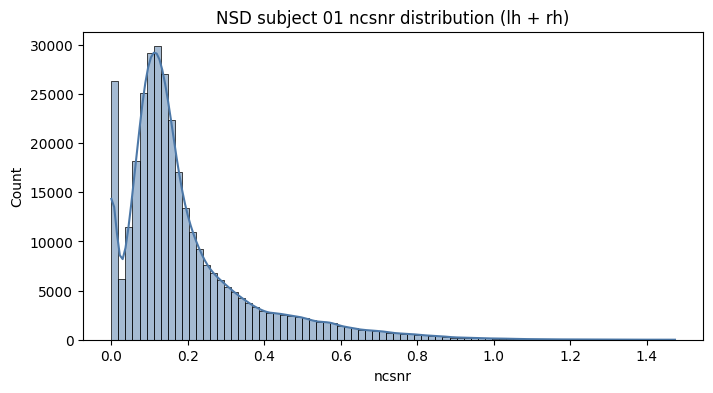

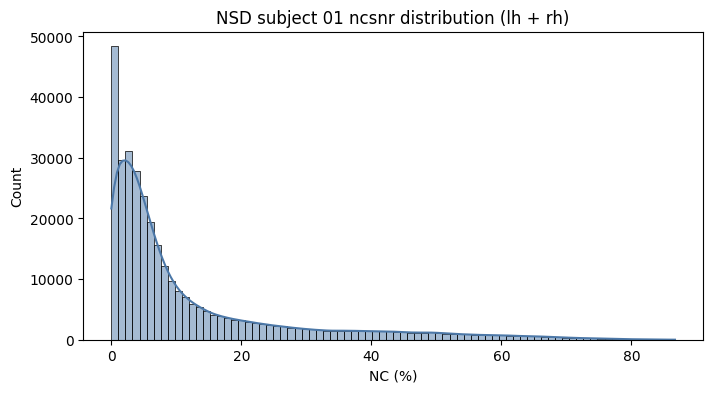

[load_fsaverage] Dataset found in /home/nilearn_data/fsaverage
[load_fsaverage_data] Dataset found in /home/nilearn_data/fsaverage
[load_fsaverage_data] Dataset found in /home/nilearn_data/fsaverage
[fetch_atlas_surf_destrieux] Dataset found in /home/nilearn_data/destrieux_surface


/tmp/ipykernel_205/2179278226.py:50: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/tmp/ipykernel_205/2179278226.py:50: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


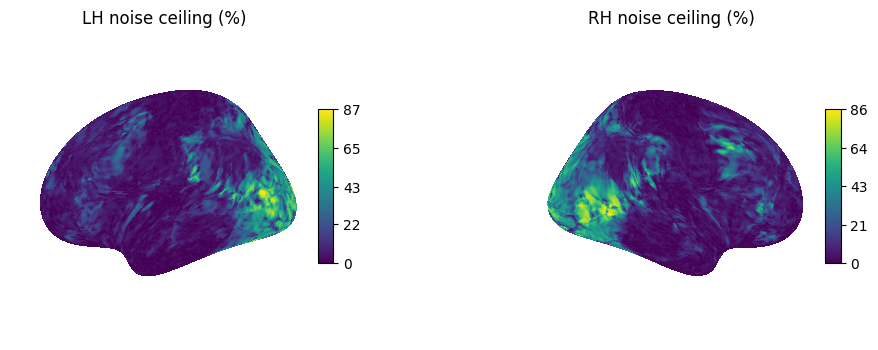

/tmp/ipykernel_205/2179278226.py:108: RuntimeWarning: Meshes are not identical but have compatible number of vertices.
  nlplt.plot_surf_roi(
/tmp/ipykernel_205/2179278226.py:119: RuntimeWarning: Meshes are not identical but have compatible number of vertices.
  nlplt.plot_surf_roi(


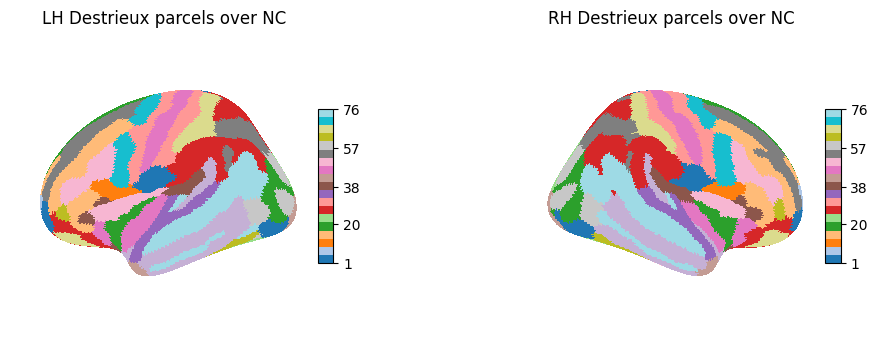

Atlas lh map unique values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75] with shape (10242,)
Atlas rh map unique values: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75] with shape (10242,)
Top 10 parcels by mean noise ceiling
hemisphere  parcel_id             parcel_name  n_vertices  noise_ceiling_mean
        rh          2   G_and_S_occipital_inf          72           38.325328
        rh         60         S_occipital_ant          49           35.222331
        rh         44           Pole_temporal         117           34.051762
        rh         35   G_temp_sup-Plan_polar          55           32.310711
        lh       

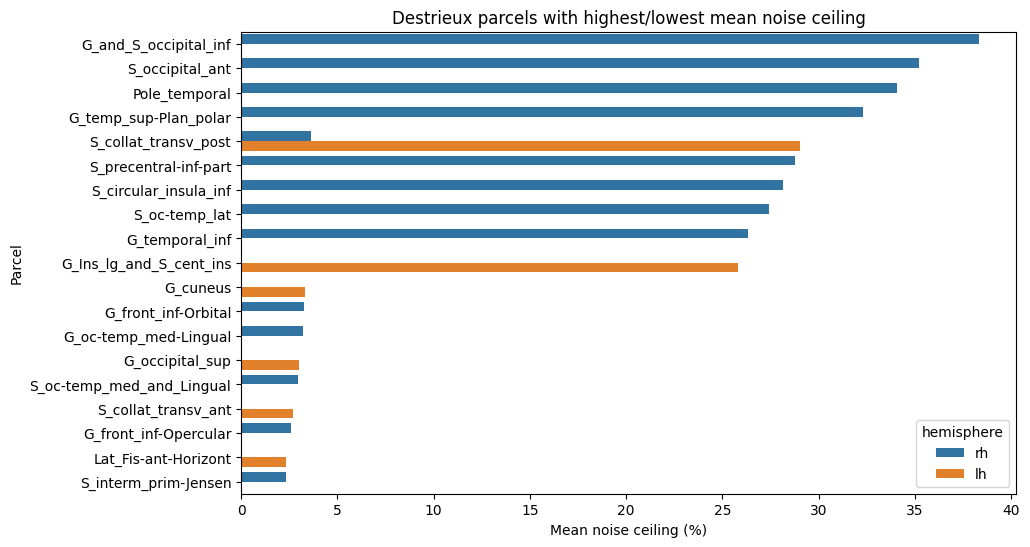

In [14]:
from nilearn import datasets, surface

# Use existing DATA_DIR if defined earlier; otherwise fall back to the project default.
DATA_DIR = globals().get("DATA_DIR", "/shared/NX-414/data/")

lh_path = DATA_DIR + "nsd-subj01-ncsnr-lh.mgh"
rh_path = DATA_DIR + "nsd-subj01-ncsnr-rh.mgh"

# Load lh/rh ncsnr maps.
lh_ncsnr = np.squeeze(nib.load(lh_path).get_fdata())
rh_ncsnr = np.squeeze(nib.load(rh_path).get_fdata())

# Convert ncsnr to noise ceiling (percent), consistent with NSD-style formulation.
# Assumes 3 repeats for NSD: NC = 100 * (snr / (snr + 1/n_reps)), with snr = ncsnr^2.
n_reps = 3
lh_snr = lh_ncsnr ** 2
rh_snr = rh_ncsnr ** 2
lh_nc = 100.0 * (lh_snr / (lh_snr + 1.0 / n_reps))
rh_nc = 100.0 * (rh_snr / (rh_snr + 1.0 / n_reps))
print(f"lh_nc: mean={np.nanmean(lh_nc):.2f}%, median={np.nanmedian(lh_nc):.2f}%, max={np.nanmax(lh_nc):.2f}%, shape: {lh_nc.shape}")
print(f"rh_nc: mean={np.nanmean(rh_nc):.2f}%, median={np.nanmedian(rh_nc):.2f}%, max={np.nanmax(rh_nc):.2f}%, shape: {rh_nc.shape}")

# Histogram of ncsnr values.
all_ncsnr = np.concatenate([lh_ncsnr, rh_ncsnr])
plt.figure(figsize=(8, 4))
sns.histplot(all_ncsnr[np.isfinite(all_ncsnr)], bins=80, kde=True, color="#4c78a8")
plt.xlabel("ncsnr")
plt.ylabel("Count")
plt.title("NSD subject 01 ncsnr distribution (lh + rh)")
plt.show()

# Histogram of NC values.
all_nc = np.concatenate([lh_nc, rh_nc])
plt.figure(figsize=(8, 4))
sns.histplot(all_nc[np.isfinite(all_nc)], bins=80, kde=True, color="#4c78a8")
plt.xlabel("NC (%)")
plt.ylabel("Count")
plt.title("NSD subject 01 ncsnr distribution (lh + rh)")
plt.show()

# Fetch fsaverage mesh and Destrieux atlas.
fsavg = datasets.load_fsaverage(mesh="fsaverage")
fsavg_sulcal = datasets.load_fsaverage_data(data_type="sulcal", mesh="fsaverage")
atlas = datasets.fetch_atlas_surf_destrieux()
atlas_lh = atlas["map_left"]
atlas_rh = atlas["map_right"]
labels = atlas["labels"]

# For plotting with destrieux atlas in fsaverage5, downsample surf and noise ceiling.
fsavg5 = datasets.load_fsaverage(mesh="fsaverage5")  # For plotting with fsaverage5 downsampling.
fsavg5_sulcal = datasets.load_fsaverage_data(data_type="sulcal", mesh="fsaverage5")


def _downsample_to_target(x, target_n):
    """Nearest-neighbor index mapping for 1D surface vectors."""
    if x.shape[0] == target_n:
        return x
    idx = np.linspace(0, x.shape[0] - 1, target_n).round().astype(int)
    return x[idx]

# Here Noise ceilings are computed for 163842 vertices of fsaverage, while the atlas is in fsaverage5 resolution.
lh_nc_fsavg5 = _downsample_to_target(lh_nc, atlas_lh.shape[0])
rh_nc_fsavg5 = _downsample_to_target(rh_nc, atlas_rh.shape[0])


# Cortical surface plot of derived noise ceiling (without downsampling).
fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw={"projection": "3d"})
nlplt.plot_surf_stat_map(
    surf_mesh=fsavg["inflated"],
    stat_map=lh_nc,
    hemi="left",
    view="lateral",
    colorbar=True,
    cmap="viridis",
    bg_map=fsavg_sulcal,
    title="LH noise ceiling (%)",
    axes=axes[0],
)
nlplt.plot_surf_stat_map(
    surf_mesh=fsavg["inflated"],
    stat_map=rh_nc,
    hemi="right",
    view="lateral",
    colorbar=True,
    cmap="viridis",
    bg_map=fsavg_sulcal,
    title="RH noise ceiling (%)",
    axes=axes[1],
)
plt.show()

# Surface plot with parcel overlay.
destrieux_atlas = surface.SurfaceImage(
    mesh=fsavg5["inflated"],
    data={
        "left": atlas["map_left"],
        "right": atlas["map_right"],
    },
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), subplot_kw={"projection": "3d"})
nlplt.plot_surf_roi(
    roi_map=destrieux_atlas,
    hemi="left",
    view="lateral",
    bg_map=fsavg5_sulcal,
    title="LH Destrieux parcels over NC",
    cmap="tab20",
    alpha=0.7,
    axes=axes[0],
)
nlplt.plot_surf_roi(
    roi_map=destrieux_atlas,
    hemi="right",
    view="lateral",
    bg_map=fsavg5_sulcal,
    title="RH Destrieux parcels over NC",
    cmap="tab20",
    alpha=0.7,
    axes=axes[1],
)
plt.show()

print("Atlas lh map unique values:", np.unique(atlas_lh), "with shape", atlas_lh.shape)
print("Atlas rh map unique values:", np.unique(atlas_rh), "with shape", atlas_rh.shape)

# Parcel-wise summary table.
def _parcel_stats(parcel_map, nc_map, hemi_name):
    rows = []
    for parcel_id in np.unique(parcel_map):
        parcel_id = int(parcel_id)
        if parcel_id < 0 or parcel_id >= len(labels):
            continue
        mask = parcel_map == parcel_id
        if not np.any(mask):
            continue
        vals = nc_map[mask]
        vals = vals[np.isfinite(vals)]
        if vals.size == 0:
            continue
        rows.append(
            {
                "hemisphere": hemi_name,
                "parcel_id": parcel_id,
                "parcel_name": labels[parcel_id],
                "n_vertices": int(mask.sum()),
                "noise_ceiling_mean": float(vals.mean()),
            }
        )
    return rows

parcel_df = pd.DataFrame(
    _parcel_stats(atlas_lh, lh_nc_fsavg5, "lh") + _parcel_stats(atlas_rh, rh_nc_fsavg5, "rh")
).sort_values("noise_ceiling_mean", ascending=False)

print("Top 10 parcels by mean noise ceiling")
print(parcel_df.head(10).to_string(index=False))
print("\nBottom 10 parcels by mean noise ceiling")
print(parcel_df.tail(10).to_string(index=False))

# Optional plot: top/bottom parcel summary.
summary_df = pd.concat([parcel_df.head(10), parcel_df.tail(10)], axis=0)
plt.figure(figsize=(10, 6))
sns.barplot(data=summary_df, y="parcel_name", x="noise_ceiling_mean", hue="hemisphere", orient="h")
plt.xlabel("Mean noise ceiling (%)")
plt.ylabel("Parcel")
plt.title("Destrieux parcels with highest/lowest mean noise ceiling")
plt.show()

---

# 2. Brain–Model Alignment

In this section, you will compare neural responses and model features using **both representational metrics and predictive linear models**. You must complete both parts of this section. The goal is not only to report scores, but also to compare what different metrics reveal about model–brain alignment.

## 2.1 Representational alignment: RSA

RSA stands for representational similarity analysis. It is one of the most widely used analyses in fMRI and model–brain alignment research. It compares the geometry of two representational spaces through their representational dissimilarity matrices (RDMs). Given two response matrices, `X` and `Y`, with rows corresponding to the same stimuli, we first compute an RDM for each matrix using correlation distance:

$$
D^X_{ij} = 1 - \mathrm{corr}(X[i,:], X[j,:]),
\qquad
D^Y_{ij} = 1 - \mathrm{corr}(Y[i,:], Y[j,:]),
$$

for stimulus pairs $i \neq j$.

We then vectorize the upper triangle of each RDM and compute RSA as the Spearman correlation between these two vectors:

$$
\mathrm{RSA}(X, Y)
=
\rho_{\mathrm{Spearman}}
\left(
\mathrm{vec}(D^X),\,
\mathrm{vec}(D^Y)
\right).
$$

In this project, `X` will usually denote model features from one candidate layer, and `Y` will denote neural responses from one dataset, ROI, subject, or time slice, depending on the analysis.

- Implement RSA between two representation matrices.
- Support at least one dissimilarity measure and one similarity measure.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [4]:
from typing import Literal
import numpy as np
from scipy import stats
from scipy.spatial.distance import pdist, squareform
from tqdm.auto import tqdm

class RepresentationalSimilarityAnalysis:
    """
    Representational Similarity Analysis (RSA).

    Given two representation matrices X and Y with the same number of conditions
    (rows), RSA:

    1. Computes a Representational Dissimilarity Matrix (RDM) for each:
       RDM_X[i, j] = dissimilarity(x_i, x_j)
       RDM_Y[i, j] = dissimilarity(y_i, y_j)

    2. Flattens the upper triangles of both RDMs and computes a correlation
       between them (Pearson or Spearman).
    """

    def __init__(
        self,
        dissimilarity: Literal["correlation", "euclidean", "cosine"] = "correlation",
        similarity_metric: Literal["pearson", "spearman"] = "spearman",
    ):
        if dissimilarity not in {"correlation", "euclidean", "cosine"}:
            raise ValueError(
                "dissimilarity must be one of {'correlation', 'euclidean', 'cosine'}"
            )
        if similarity_metric not in {"pearson", "spearman"}:
            raise ValueError("similarity_metric must be one of {'pearson', 'spearman'}")
        self.dissimilarity = dissimilarity
        self.similarity_metric = similarity_metric

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Compute RSA similarity between X and Y.

        Parameters
        ----------
        X, Y : np.ndarray
            Arrays of shape (n_conditions, ...) that may need to be flattened
            along feature dimensions.

        Returns
        -------
        rsa_similarity : float
            Correlation between the vectorized upper triangles of the two RDMs.
        """
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X)
        Y = np.asarray(Y)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"X and Y must have the same number of conditions: {X.shape[0]} vs {Y.shape[0]}"
            )
            
        rdm_x = self.compute_rdm(X)
        rdm_y = self.compute_rdm(Y)
        return self.compare_rdms(rdm_x, rdm_y)

    def compute_rdm(self, X: np.ndarray) -> np.ndarray:
        """
        Compute the Representational Dissimilarity Matrix (RDM)
        for a given representation matrix X.

        Parameters
        ----------
        X : np.ndarray
            Array of shape (n_conditions, n_features).

        Returns
        -------
        rdm : np.ndarray
            Array of shape (n_conditions, n_conditions) with pairwise dissimilarities.
        """
        # pdist computes all pairwise distances in condensed form, then
        # squareform converts to full symmetric matrix.
        # 'correlation' distance = 1 - Pearson(x_i, x_j), exactly as defined above.
        rdm = squareform(pdist(X, metric=self.dissimilarity))  # shape: (n_conditions, n_conditions)
        return rdm

    def compare_rdms(self, rdm1: np.ndarray, rdm2: np.ndarray) -> float:
        """
        Compare two RDMs by correlating their upper triangles.
        """
        if rdm1.shape != rdm2.shape:
            raise ValueError(f"RDM shapes must match: {rdm1.shape} vs {rdm2.shape}")

        triu = np.triu_indices_from(rdm1, k=1)
        v1 = rdm1[triu]
        v2 = rdm2[triu]

        if self.similarity_metric == "pearson":
            result = stats.pearsonr(v1, v2)
            return float(result[0])

        result = stats.spearmanr(v1, v2)
        return float(result[0])


## 2.2 Representational alignment: unbiased linear CKA

CKA stands for centered kernel alignment. It is commonly used in interpretability and representation analysis to test how strongly the internal computations of two systems align. As a second mapping-free alignment metric, we want to compute unbiased linear centered kernel alignment (CKA) between model features and neural responses. Let

$$
X \in \mathbb{R}^{n \times d}, \qquad
Y \in \mathbb{R}^{n \times p},
$$

where both matrices are measured on the same $n$ stimuli. We form linear Gram matrices

$$
K = XX^\top,
\qquad
L = YY^\top.
$$

We then estimate dependence using the unbiased (U-statistic) HSIC estimator, $\mathrm{HSIC}_u(K, L)$, and define CKA as

$$
\mathrm{CKA}(X, Y)
=
\frac{\mathrm{HSIC}_u(K, L)}
{\sqrt{\mathrm{HSIC}_u(K, K)\,\mathrm{HSIC}_u(L, L)}}.
$$

Like RSA, CKA compares representational structure directly without fitting a predictive mapping. In this notebook, `X` and `Y` again refer to aligned model and neural response matrices evaluated on the same set of stimuli.

- Implement **unbiased linear CKA** only.
- Use your implementation to compare model layers to neural responses.

### Starter code

In [5]:
import numpy as np

class CenteredKernelAlignment:
    """
    Unbiased linear CKA only.

    Parameters
    ----------
    eps : float
        Small constant for numerical stability.
    dtype : np.dtype
        Data type used for computations.
    """

    def __init__(
        self,
        eps: float = 1e-8,
        dtype: np.dtype = np.float64,
    ):
        self.eps = eps
        self.dtype = dtype

    def __call__(self, X: np.ndarray, Y: np.ndarray) -> float:
        return self.forward(X, Y)

    def forward(self, X: np.ndarray, Y: np.ndarray) -> float:
        X = np.asarray(X).astype(self.dtype)
        Y = np.asarray(Y).astype(self.dtype)

        if X.shape[0] != Y.shape[0]:
            raise ValueError(
                f"Batch sizes must match along axis 0: {X.shape[0]} vs {Y.shape[0]}"
            )

        # Flatten to (n_samples, n_features)
        X = X.reshape(X.shape[0], -1)
        Y = Y.reshape(Y.shape[0], -1)

        return self._unbiased_linear_cka(X, Y)

    def _unbiased_linear_hsic(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased HSIC estimator for the linear kernel.

        X : [n, d_x]
        Y : [n, d_y]
        """
        X = np.asarray(X, dtype=self.dtype)
        Y = np.asarray(Y, dtype=self.dtype)
        n = X.shape[0]
        if n != Y.shape[0]:
            raise ValueError(f"Batch sizes must match: {n} vs {Y.shape[0]}")
        if n < 4:
            return float("nan")

        K = X @ X.T
        L = Y @ Y.T
        np.fill_diagonal(K, 0.0)
        np.fill_diagonal(L, 0.0)

        term1 = np.trace(K @ L)
        term2 = K.sum() * L.sum()
        term3 = np.sum(K @ L)

        hsic = (
            term1
            + term2 / ((n - 1) * (n - 2))
            - (2.0 / (n - 2)) * term3
        ) / (n * (n - 3))
        return float(hsic)

    def _unbiased_linear_cka(self, X: np.ndarray, Y: np.ndarray) -> float:
        """
        Unbiased linear CKA:

            CKA_unb(X, Y) =
                HSIC_unb(X, Y) / sqrt(HSIC_unb(X, X) * HSIC_unb(Y, Y))
        """
        hsic_xy = self._unbiased_linear_hsic(X, Y)
        hsic_xx = self._unbiased_linear_hsic(X, X)
        hsic_yy = self._unbiased_linear_hsic(Y, Y)

        if not np.isfinite(hsic_xy) or not np.isfinite(hsic_xx) or not np.isfinite(hsic_yy):
            return float("nan")

        denom = np.sqrt(max(hsic_xx, self.eps) * max(hsic_yy, self.eps))
        if denom <= self.eps:
            return float("nan")

        return float(hsic_xy / denom)

## 2.3 Apply RSA and CKA

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

- Compare layers within each model.
- Compare the two models.
- For EEG, show how representational similarity changes over time.
- For TVSD and NSD, compare across ROIs.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **Layer-wise RSA results** for both models.
2. **Layer-wise CKA results** for both models.
3. **One direct comparison between the two models** using representational metrics.
4. **One EEG time-resolved analysis** or **one ROI-wise analysis** for TVSD/NSD.
5. **One short written interpretation** in Answer box 2.1.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.1</strong><br>Do RSA and CKA tell the same story? Identify at least one case where they agree and one case where they disagree, and explain what that might mean.</div>

In [6]:
# TODO: implement RSA
# TODO: implement unbiased linear CKA
# TODO: compute scores across layers
# TODO: compare across models and ROIs / time windows

### Helper functions to load features and neural responses

In [17]:
def load_layer_features(path: str, layer: str, feat_idx: np.ndarray = None) -> np.ndarray:
    """
    Load the features from one datasets from an HDF5 feature file and optionally select rows by `feat_idx`.
    """
    with h5py.File(path, 'r') as f:
        layer = f[f"features/{layer}"]
        if feat_idx is not None:
            sort_order = np.argsort(feat_idx) # To sort feat_idx to speed up reading from HDF5 (contiguous reads)
            unsort_order = np.argsort(sort_order) # To restore original order after indexing
            
            # Use read_direct to read more efficiently from the hdf5 file using feat_idx
            arr = np.ndarray([len(feat_idx), layer.shape[1]], dtype=layer.dtype)
            layer.read_direct(arr, source_sel=np.s_[feat_idx[sort_order]])
            return arr[unsort_order]
        return layer[:]

# Model layers hardcoded for ease, as taken from each model's feature files
MODEL_A_layers = ['layer1-0', 'layer2-0', 'layer3-0', 'layer3-5', 'layer3-10', 'layer3-15', 'layer3-20', 'layer3-25', 'layer3-30', 'layer4-1']
MODEL_B_layers = ['language_model-layers-3', 'language_model-layers-8', 'language_model-layers-11', 'language_model-layers-16', 'visual-blocks-2', 'visual-blocks-6', 'visual-blocks-10', 'visual-blocks-14', 'visual-blocks-18', 'visual-blocks-22']

In [16]:
def load_neural_response(dataset: str, subject: str, region: str, train_set: bool = True) -> np.ndarray:
    """Load the neural responses from one dataset, optionally selecting a specific subject and region.
    
    If `train_set` is True, will load the training set responses; otherwise will load the test set responses.
    """
    with h5py.File(dataset, 'r') as f:
        return np.asarray(f["train" if train_set else "test"]["neural_data"][subject][region][:])

# Dataset subjects and regions hardcoded for ease, as taken from each dataset
TVSD_subjects = ["monkeyF", "monkeyN"]
TVSD_regions = ['IT', 'V4', 'V1']

EEG2_subjects = ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08',
                 'sub-09', 'sub-10']
EEG2_regions = ['occipital', 'parietal', 'temporal', 'frontal', 'central',
                'occipital_parietal', 'whole_brain']

NSD_subjects = ['subj01', 'subj02', 'subj03', 'subj04', 'subj05', 'subj06', 'subj07', 'subj08']
NSD_regions = ['early', 'midventral', 'midlateral', 'midparietal', 'ventral', 'lateral',
 'parietal', 'nsdgeneral', 'whole_brain', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'OWFA',
 'VWFA-1', 'VWFA-2', 'OPA', 'PPA', 'RSC', 'OFA', 'FFA-1', 'FFA-2', 'EBA', 'FBA-1',
 'FBA-2']

### TVSD comparisons (UNUSED)

In [11]:
# rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
# cka = CenteredKernelAlignment(dtype=np.float64)

# # Compare Monkey F V1 layer features for both models with TVSD neural responses in the test set.
# subject = "monkeyN"
# region = "V1"
# print(f"Comparing MODEL_A with TVSD Monkey F V1 test responses:")
# Y = load_neural_response(DATA_DIR + TVSD, subject=subject, region=region, train_set=False)
# for layer in MODEL_A_layers:
#     X = load_layer_features(FEATURES_DIR + MODEL_A + THINGS_STIMULI, layer=layer, feat_idx=feat_idx_tvsd_test)
#     print(f"  Layer {layer}: RSA similarity = {rsa.forward(X, Y):.4f}, CKA similarity = {cka.forward(X, Y):.4f}")

# print(f"\n \n Comparing MODEL_B with TVSD Monkey F V1 test responses:")
# for layer in MODEL_B_layers:
#     X = load_layer_features(FEATURES_DIR + MODEL_B + THINGS_STIMULI, layer=layer, feat_idx=feat_idx_tvsd_test)
#     print(f"  Layer {layer}: RSA similarity = {rsa.forward(X, Y):.4f}, CKA similarity = {cka.forward(X, Y):.4f}")

Comparing MODEL_A with TVSD Monkey F V1 test responses:
  Layer layer1-0: RSA similarity = 0.1009, CKA similarity = 0.3512
  Layer layer2-0: RSA similarity = 0.1898, CKA similarity = 0.3767
  Layer layer3-0: RSA similarity = 0.1977, CKA similarity = 0.3411
  Layer layer3-5: RSA similarity = 0.1299, CKA similarity = 0.2427
  Layer layer3-10: RSA similarity = 0.0996, CKA similarity = 0.1705
  Layer layer3-15: RSA similarity = 0.0710, CKA similarity = 0.1417
  Layer layer3-20: RSA similarity = 0.0726, CKA similarity = 0.1306
  Layer layer3-25: RSA similarity = 0.0655, CKA similarity = 0.1247
  Layer layer3-30: RSA similarity = 0.0729, CKA similarity = 0.1402
  Layer layer4-1: RSA similarity = 0.0722, CKA similarity = 0.1050

 
 Comparing MODEL_B with TVSD Monkey F V1 test responses:
  Layer language_model-layers-3: RSA similarity = 0.0390, CKA similarity = 0.0569
  Layer language_model-layers-8: RSA similarity = 0.0416, CKA similarity = 0.0647
  Layer language_model-layers-11: RSA similar

In [12]:
# rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
# cka = CenteredKernelAlignment(dtype=np.float64)

# # Compare V1 layer features for both models with TVSD neural responses in the test set averaged across subjects.
# region = "V1"
# Ys = []
# for subj in TVSD_subjects:
#     Ys.append(load_neural_response(DATA_DIR + TVSD, subject=subj, region=region, train_set=False))
    
# print(f"Comparing MODEL_A with TVSD V1 test responses:")
# for layer in MODEL_A_layers:
#     X = load_layer_features(FEATURES_DIR + MODEL_A + THINGS_STIMULI, layer=layer, feat_idx=feat_idx_tvsd_test)
#     rsa_subj_avg = np.mean([rsa.forward(X, Y) for Y in Ys])
#     cka_subj_avg = np.mean([cka.forward(X, Y) for Y in Ys])
#     print(f"  Layer {layer}: RSA similarity = {rsa_subj_avg:.4f}, CKA similarity = {cka_subj_avg:.4f}")

# print(f"\n \n Comparing MODEL_B with TVSD V1 test responses:")
# for layer in MODEL_B_layers:
#     X = load_layer_features(FEATURES_DIR + MODEL_B + THINGS_STIMULI, layer=layer, feat_idx=feat_idx_tvsd_test)
#     rsa_subj_avg = np.mean([rsa.forward(X, Y) for Y in Ys])
#     cka_subj_avg = np.mean([cka.forward(X, Y) for Y in Ys])
#     print(f"  Layer {layer}: RSA similarity = {rsa_subj_avg:.4f}, CKA similarity = {cka_subj_avg:.4f}")

Comparing MODEL_A with TVSD V1 test responses:
  Layer layer1-0: RSA similarity = 0.1044, CKA similarity = 0.3412
  Layer layer2-0: RSA similarity = 0.1895, CKA similarity = 0.3620
  Layer layer3-0: RSA similarity = 0.1977, CKA similarity = 0.3285
  Layer layer3-5: RSA similarity = 0.1315, CKA similarity = 0.2327
  Layer layer3-10: RSA similarity = 0.0973, CKA similarity = 0.1662
  Layer layer3-15: RSA similarity = 0.0707, CKA similarity = 0.1400
  Layer layer3-20: RSA similarity = 0.0722, CKA similarity = 0.1298
  Layer layer3-25: RSA similarity = 0.0664, CKA similarity = 0.1245
  Layer layer3-30: RSA similarity = 0.0733, CKA similarity = 0.1408
  Layer layer4-1: RSA similarity = 0.0788, CKA similarity = 0.1052

 
 Comparing MODEL_B with TVSD V1 test responses:
  Layer language_model-layers-3: RSA similarity = 0.0364, CKA similarity = 0.0497
  Layer language_model-layers-8: RSA similarity = 0.0376, CKA similarity = 0.0561
  Layer language_model-layers-11: RSA similarity = 0.0247, CKA 

### EEG2 comparisons (INCOMPLETE)

In [ ]:
# rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
# cka = CenteredKernelAlignment(dtype=np.float64)

# # Compare V1 layer features for both models with TVSD neural responses in the test set.
# subjects = EEG2_subjects[:1]
# region = "occipital"
# Ys = []
# for subj in subjects:
#     Ys.append(load_neural_response(DATA_DIR + EEG2, subject=subj, region=region, train_set=False))
    
# print(f"Comparing MODEL_A with EEG2 {region} test responses:")
# rsa_subj_avg = collections.defaultdict(list)
# cka_subj_avg = collections.defaultdict(list)
# for layer in MODEL_A_layers:
#     X = load_layer_features(FEATURES_DIR + MODEL_A + THINGS_STIMULI, layer=layer, feat_idx=feat_idx_eeg2_test)
#     # EEG data has a time dimension (with 80 time bins), so we can compute RSA/CKA at specific time points and then compare 
#     # how the similarity evolves over time.
#     for time in range(0, 80, 10):
#         print(Ys[0][:, :, time].shape)
#         rsa_subj_avg[layer].append(np.mean([rsa.forward(X, Y[:,:, time]) for Y in Ys]))
#         cka_subj_avg[layer].append(np.mean([cka.forward(X, Y[:,:, time]) for Y in Ys]))
#         print(f"  Layer {layer}: RSA similarity = {rsa_subj_avg[layer][-1]:.4f}, CKA similarity = {cka_subj_avg[layer][-1]:.4f}")

# # Plot the RSA and CKA similarity over time for each layer.
# plt.figure(figsize=(12, 6))
# for layer in MODEL_A_layers:
#     plt.plot(range(0, 80, 10), rsa_subj_avg[layer], label=f"RSA {layer}")
#     plt.plot(range(0, 80, 10), cka_subj_avg[layer], label=f"CKA {layer}", linestyle="--")
# plt.xlabel("Time (ms)")
# plt.ylabel("Similarity")
# plt.title(f"MODEL_A similarity with EEG2 {region} test responses over time")
# plt.legend()
# plt.show()

# # print(f"\n \n Comparing MODEL_B with EEG2 {region} test responses:")
# # for layer in MODEL_B_layers:
# #     X = load_layer_features(FEATURES_DIR + MODEL_B + THINGS_STIMULI, layer=layer, feat_idx=feat_idx_eeg2_test)
# #     rsa_subj_avg = np.mean([rsa.forward(X, Y) for Y in Ys])
# #     cka_subj_avg = np.mean([cka.forward(X, Y) for Y in Ys])
# #     print(f"  Layer {layer}: RSA similarity = {rsa_subj_avg:.4f}, CKA similarity = {cka_subj_avg:.4f}")

### NSD comparisons

In [ ]:
# TODO: BASIC MODEL, REMOVE AT THE END OF TESTING
# rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
# cka = CenteredKernelAlignment(dtype=np.float64)

# # Compare Ventral layer features for both models with NSD neural responses in the test set.
# subjects = NSD_subjects[:1] # For quick testing, just use the first subject for now.
# region = "ventral"
# Ys = []
# for subj in subjects:
#     Ys.append(load_neural_response(DATA_DIR + NSD, subject=subj, region=region, train_set=False))

# def compute_similarity_across_subject_NSD(model_layers, model_name):
#     print(f"Comparing {model_name} with NSD {region} test responses:")
#     for layer in model_layers:
#         # We need to load features separately for each subject here since NSD 
#         # has subject-specific stimulus sets and feature indexes.
#         rsa_per_subj = []
#         cka_per_subj = []
#         for i, subj in enumerate(subjects):
#             X = load_layer_features(FEATURES_DIR + model_name + NSD_STIMULI, layer=layer, feat_idx=feat_idx_nsd_test[subj])
#             rsa_per_subj.append(rsa.forward(X, Ys[i]))
#             cka_per_subj.append(cka.forward(X, Ys[i]))
#         rsa_subj_avg = np.mean(rsa_per_subj)
#         cka_subj_avg = np.mean(cka_per_subj)
#         print(f"  Layer {layer}: RSA similarity = {rsa_subj_avg:.4f}, CKA similarity = {cka_subj_avg:.4f}")    

# compute_similarity_across_subject_NSD(MODEL_A_layers, MODEL_A)
# # print("\n ================================================== \n")
# # compute_similarity_across_subject_NSD(MODEL_B_layers, MODEL_B)

Comparing adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/ with NSD nsdgeneral test responses:
  Layer layer1-0: RSA similarity = 0.0690, CKA similarity = 0.1323
  Layer layer2-0: RSA similarity = 0.1429, CKA similarity = 0.1613
  Layer layer3-5: RSA similarity = 0.2089, CKA similarity = 0.2143
  Layer layer3-10: RSA similarity = 0.2354, CKA similarity = 0.2391
  Layer layer3-15: RSA similarity = 0.2596, CKA similarity = 0.2751
  Layer layer3-20: RSA similarity = 0.2468, CKA similarity = 0.2781
  Layer layer3-25: RSA similarity = 0.2392, CKA similarity = 0.2810
  Layer layer3-30: RSA similarity = 0.2466, CKA similarity = 0.2719
  Layer layer4-1: RSA similarity = 0.2775, CKA similarity = 0.2524
Comparing Qwen3-VL-2B-Instruct/ with NSD nsdgeneral test responses:
  Layer language_model-layers-3: RSA similarity = 0.1992, CKA similarity = 0.2600
  Layer language_model-layers-8: RSA similarity = 0.2055, CKA similarity = 0.2506
  Layer language_model-layers-11: RSA similarity = 

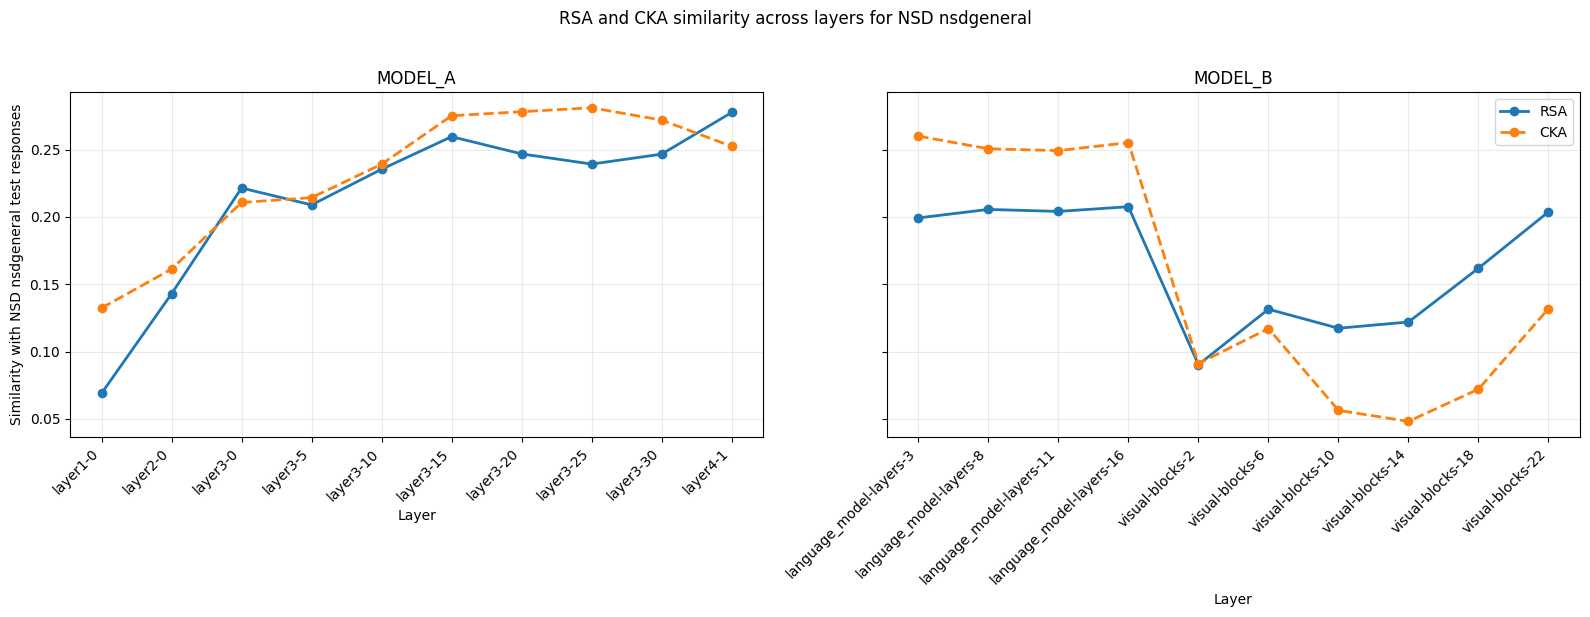

In [35]:
# UNCOMMENT THE FOLLOWING TO RECOMPUTE RSA/CKA (SLOW)

# rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
# cka = CenteredKernelAlignment(dtype=np.float64)

# # Compare layer features for both models with NSD's nsdgeneral neural responses in the test set, averaging
# # similarity across subjects.
# subjects = NSD_subjects
# region = "nsdgeneral"
# Ys = []
# for subj in subjects:
#     Ys.append(load_neural_response(DATA_DIR + NSD, subject=subj, region=region, train_set=False))


# def compute_similarity_across_subject_NSD(model_layers, model_name):
#     rsa_subj_avg = collections.defaultdict(list)
#     cka_subj_avg = collections.defaultdict(list)
#     print(f"Comparing {MODEL_A if model_name == MODEL_A else MODEL_B} with NSD {region} test responses:")
#     for layer in model_layers:
#         # We need to load features separately for each subject here since NSD
#         # has subject-specific stimulus sets and feature indexes.
#         rsa_per_subj = []
#         cka_per_subj = []
#         for i, subj in enumerate(subjects):
#             X = load_layer_features(
#                 FEATURES_DIR + model_name + NSD_STIMULI,
#                 layer=layer,
#                 feat_idx=feat_idx_nsd_test[subj],
#             )
#             rsa_per_subj.append(rsa.forward(X, Ys[i]))
#             cka_per_subj.append(cka.forward(X, Ys[i]))
#         rsa_subj_avg[layer] = np.mean(rsa_per_subj)
#         cka_subj_avg[layer] = np.mean(cka_per_subj)
#         print(f"  Layer {layer}: RSA similarity = {rsa_subj_avg[layer]:.4f}, CKA similarity = {cka_subj_avg[layer]:.4f}")
#     return rsa_subj_avg, cka_subj_avg

# rsa_subj_avg_A, cka_subj_avg_A = compute_similarity_across_subject_NSD(MODEL_A_layers, MODEL_A)
# rsa_subj_avg_B, cka_subj_avg_B = compute_similarity_across_subject_NSD(MODEL_B_layers, MODEL_B)

# # pickle the results for later use in visualization
# with open("rsa_cka_nsd_layers_results.pkl", "wb") as f:
#     pickle.dump({
#         "MODEL_A": {"rsa": rsa_subj_avg_A, "cka": cka_subj_avg_A},
#         "MODEL_B": {"rsa": rsa_subj_avg_B, "cka": cka_subj_avg_B},
#     }, f)

# Load the results back from the pickle file (if needed).
with open("rsa_cka_nsd_layers_results.pkl", "rb") as f:
    results = pickle.load(f)
    rsa_subj_avg_A = results["MODEL_A"]["rsa"]
    cka_subj_avg_A = results["MODEL_A"]["cka"]
    rsa_subj_avg_B = results["MODEL_B"]["rsa"]
    cka_subj_avg_B = results["MODEL_B"]["cka"]

# Plot RSA and CKA similarity across layers with two side-by-side plots, one for each model.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, model_layers, rsa_scores, cka_scores, title in [
    (axes[0], MODEL_A_layers, rsa_subj_avg_A, cka_subj_avg_A, "MODEL_A"),
    (axes[1], MODEL_B_layers, rsa_subj_avg_B, cka_subj_avg_B, "MODEL_B"),
]:
    layer_labels = list(model_layers)
    x = np.arange(len(layer_labels))
    rsa_values = [rsa_scores[layer] for layer in layer_labels]
    cka_values = [cka_scores[layer] for layer in layer_labels]

    ax.plot(x, rsa_values, label="RSA", marker="o", linewidth=2)
    ax.plot(x, cka_values, label="CKA", marker="o", linewidth=2, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(layer_labels, rotation=45, ha="right")
    ax.set_xlabel("Layer")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel(f"Similarity with NSD {region} test responses")
axes[1].legend(loc="best")
fig.suptitle(f"RSA and CKA similarity across layers for NSD {region}", y=1.02)
fig.tight_layout()
plt.show()


Comparing adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/ layer4-1 with NSD test responses over regions:
  Subject subj01, Region early: RSA similarity = 0.2226, CKA similarity = 0.1904
  Subject subj01, Region midventral: RSA similarity = 0.1885, CKA similarity = 0.1352
  Subject subj01, Region midlateral: RSA similarity = 0.1838, CKA similarity = 0.1188
  Subject subj01, Region midparietal: RSA similarity = 0.2272, CKA similarity = 0.1983
  Subject subj01, Region ventral: RSA similarity = 0.2913, CKA similarity = 0.2580
  Subject subj01, Region lateral: RSA similarity = 0.2339, CKA similarity = 0.2450
  Subject subj01, Region parietal: RSA similarity = 0.2161, CKA similarity = 0.1219
  Subject subj01, Region nsdgeneral: RSA similarity = 0.3099, CKA similarity = 0.2868
  Subject subj01, Region whole_brain: RSA similarity = 0.2297, CKA similarity = 0.2300
  Subject subj01, Region V1v: RSA similarity = 0.1352, CKA similarity = 0.1273
  Subject subj01, Region V1d: RSA simi

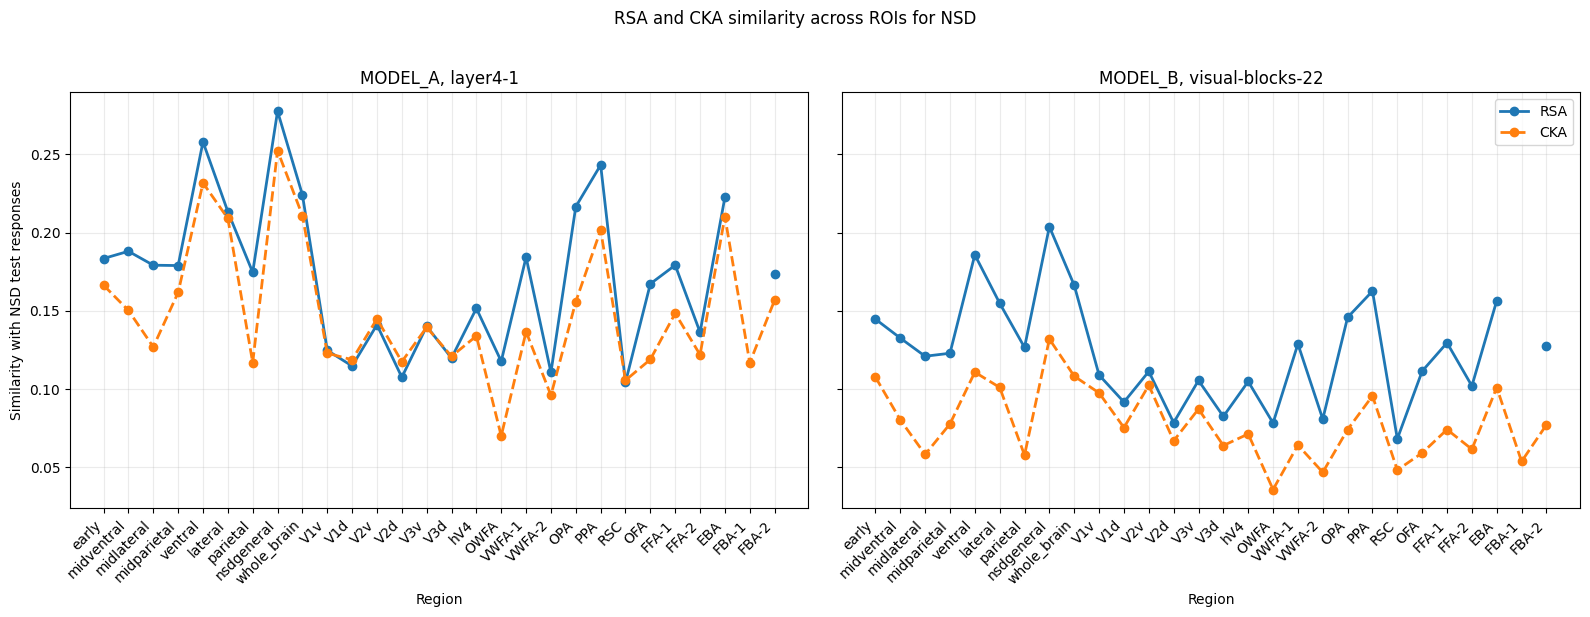

In [40]:
# UNCOMMENT THE FOLLOWING TO RECOMPUTE RSA/CKA (SLOW)

# # Compare features from the latest visual layer for both models with NSD neural responses in the test set across all ROIs, 
# # averaging similarity across subjects.
# layer = {MODEL_A: MODEL_A_layers[-1], MODEL_B: MODEL_B_layers[-1]}
# subjects = NSD_subjects
# regions = NSD_regions

# # Pre-load all neural responses and RDMs for each region and subject to avoid redundant loading and RDM computation 
# # in the loop below.
# Ys = collections.defaultdict(np.ndarray)
# Y_rdms = collections.defaultdict(np.ndarray)
# for region in regions:
#     Ys[region] = []
#     Y_rdms[region] = []
#     for i, subj in enumerate(subjects):
#         Ys[region].append(load_neural_response(DATA_DIR + NSD, subject=subj, region=region, train_set=False))
#         Y_rdms[region].append(rsa.compute_rdm(Ys[region][i]))

# def compute_similarity_across_subject_NSD(model_name):
#     rsa_per_subj = collections.defaultdict(list)
#     cka_per_subj = collections.defaultdict(list)
#     print(f"Comparing {MODEL_A if model_name == MODEL_A else MODEL_B} {layer[model_name]} with NSD test responses over regions:")
    
#     for i, subj in enumerate(subjects):
#         X = load_layer_features(
#             FEATURES_DIR + model_name + NSD_STIMULI,
#             layer=layer[model_name],
#             feat_idx=feat_idx_nsd_test[subj],
#         )
#         # Compute RDM for the model features once per subject, since it's the same across neural response regions, 
#         # and very expensive to compute.
#         X_rdm = rsa.compute_rdm(X)
#         for region in regions:
#             rsa_per_subj[region].append(rsa.compare_rdms(X_rdm, Y_rdms[region][i]))
#             cka_per_subj[region].append(cka.forward(X, Ys[region][i]))
#             print(f"  Subject {subj}, Region {region}: RSA similarity = {rsa_per_subj[region][-1]:.4f}, CKA similarity = {cka_per_subj[region][-1]:.4f}")

#     rsa_subj_avg = {region: np.mean(rsa_per_subj[region]) for region in regions}
#     cka_subj_avg = {region: np.mean(cka_per_subj[region]) for region in regions}

#     return rsa_subj_avg, cka_subj_avg

# rsa_subj_avg_A, cka_subj_avg_A = compute_similarity_across_subject_NSD(MODEL_A)
# rsa_subj_avg_B, cka_subj_avg_B = compute_similarity_across_subject_NSD(MODEL_B)

# # pickle the results for later use in visualization
# with open("rsa_cka_nsd_regions_results.pkl", "wb") as f:
#     pickle.dump({
#         "MODEL_A": {"rsa": rsa_subj_avg_A, "cka": cka_subj_avg_A},
#         "MODEL_B": {"rsa": rsa_subj_avg_B, "cka": cka_subj_avg_B},
#     }, f)

# Load the results back from the pickle file (if needed).
with open("rsa_cka_nsd_regions_results.pkl", "rb") as f:
    results = pickle.load(f)
    rsa_subj_avg_A = results["MODEL_A"]["rsa"]
    cka_subj_avg_A = results["MODEL_A"]["cka"]
    rsa_subj_avg_B = results["MODEL_B"]["rsa"]
    cka_subj_avg_B = results["MODEL_B"]["cka"]

# Plot RSA and CKA similarity with two side-by-side plots, one for each model, across layers.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, regions, rsa_scores, cka_scores, title in [
    (axes[0], regions, rsa_subj_avg_A, cka_subj_avg_A, f"MODEL_A, {layer[MODEL_A]}"),
    (axes[1], regions, rsa_subj_avg_B, cka_subj_avg_B, f"MODEL_B, {layer[MODEL_B]}"),
]:
    region_labels = list(regions)
    x = np.arange(len(region_labels))
    rsa_values = [rsa_scores[region] for region in region_labels]
    cka_values = [cka_scores[region] for region in region_labels]

    ax.plot(x, rsa_values, label="RSA", marker="o", linewidth=2)
    ax.plot(x, cka_values, label="CKA", marker="o", linewidth=2, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels, rotation=45, ha="right")
    ax.set_xlabel("Region")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel(f"Similarity with NSD test responses")
axes[1].legend(loc="best")
fig.suptitle(f"RSA and CKA similarity across ROIs for NSD", y=1.02)
fig.tight_layout()
plt.show()


Comparing adv_resnet152_imagenet_full_ffgsm_eps-1_alpha-125-ep10_seed-0/ layer1-0 with NSD test responses over regions:
  Subject subj01, Region early: RSA similarity = 0.1094, CKA similarity = 0.2580
  Subject subj01, Region midventral: RSA similarity = 0.0688, CKA similarity = 0.1252
  Subject subj01, Region midlateral: RSA similarity = 0.0248, CKA similarity = 0.0592
  Subject subj01, Region midparietal: RSA similarity = 0.0503, CKA similarity = 0.0690
  Subject subj01, Region ventral: RSA similarity = 0.0491, CKA similarity = 0.0747
  Subject subj01, Region lateral: RSA similarity = 0.0358, CKA similarity = 0.0487
  Subject subj01, Region parietal: RSA similarity = 0.0620, CKA similarity = 0.0335
  Subject subj01, Region nsdgeneral: RSA similarity = 0.0794, CKA similarity = 0.1616
  Subject subj01, Region whole_brain: RSA similarity = 0.0618, CKA similarity = 0.1047
  Subject subj01, Region V1v: RSA similarity = 0.1167, CKA similarity = 0.3124
  Subject subj01, Region V1d: RSA simi

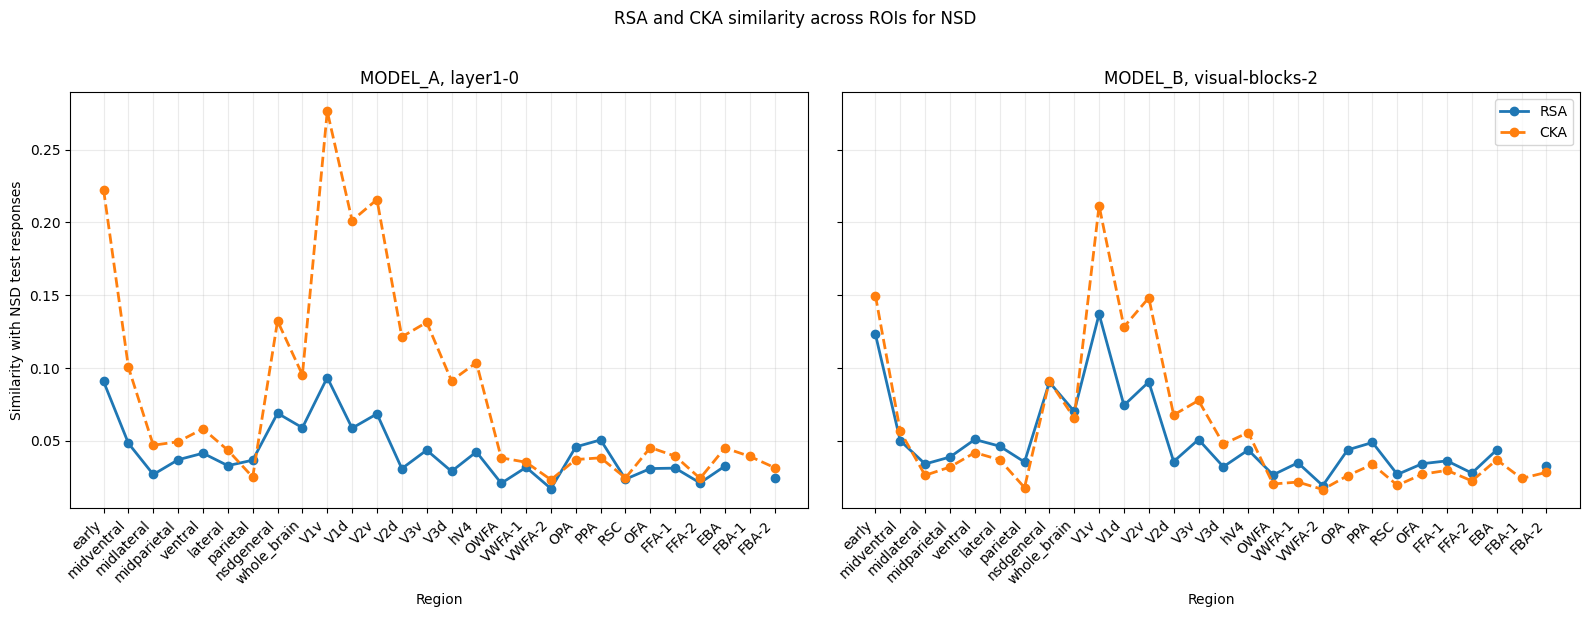

In [42]:
# UNCOMMENT THE FOLLOWING TO RECOMPUTE RSA/CKA (SLOW)

# # Compare features from the earliest visual layer for both models with NSD neural responses in the test set across all ROIs, 
# # averaging similarity across subjects.
# layer = {MODEL_A: "layer1-0", MODEL_B: 'visual-blocks-2'}
# subjects = NSD_subjects
# regions = NSD_regions

# # Pre-load all neural responses and RDMs for each region and subject to avoid redundant loading and RDM computation 
# # in the loop below.
# Ys = collections.defaultdict(np.ndarray)
# Y_rdms = collections.defaultdict(np.ndarray)
# for region in regions:
#     Ys[region] = []
#     Y_rdms[region] = []
#     for i, subj in enumerate(subjects):
#         Ys[region].append(load_neural_response(DATA_DIR + NSD, subject=subj, region=region, train_set=False))
#         Y_rdms[region].append(rsa.compute_rdm(Ys[region][i]))

# def compute_similarity_across_subject_NSD(model_name):
#     rsa_per_subj = collections.defaultdict(list)
#     cka_per_subj = collections.defaultdict(list)
#     print(f"Comparing {MODEL_A if model_name == MODEL_A else MODEL_B} {layer[model_name]} with NSD test responses over regions:")
    
#     for i, subj in enumerate(subjects):
#         X = load_layer_features(
#             FEATURES_DIR + model_name + NSD_STIMULI,
#             layer=layer[model_name],
#             feat_idx=feat_idx_nsd_test[subj],
#         )
#         # Compute RDM for the model features once per subject, since it's the same across neural response regions, 
#         # and very expensive to compute.
#         X_rdm = rsa.compute_rdm(X)
#         for region in regions:
#             rsa_per_subj[region].append(rsa.compare_rdms(X_rdm, Y_rdms[region][i]))
#             cka_per_subj[region].append(cka.forward(X, Ys[region][i]))
#             print(f"  Subject {subj}, Region {region}: RSA similarity = {rsa_per_subj[region][-1]:.4f}, CKA similarity = {cka_per_subj[region][-1]:.4f}")

#     rsa_subj_avg = {region: np.mean(rsa_per_subj[region]) for region in regions}
#     cka_subj_avg = {region: np.mean(cka_per_subj[region]) for region in regions}

#     return rsa_subj_avg, cka_subj_avg

# rsa_subj_avg_A, cka_subj_avg_A = compute_similarity_across_subject_NSD(MODEL_A)
# rsa_subj_avg_B, cka_subj_avg_B = compute_similarity_across_subject_NSD(MODEL_B)

# # pickle the results for later use in visualization
# with open("rsa_cka_nsd_regions_results_first_layer.pkl", "wb") as f:
#     pickle.dump({
#         "MODEL_A": {"rsa": rsa_subj_avg_A, "cka": cka_subj_avg_A},
#         "MODEL_B": {"rsa": rsa_subj_avg_B, "cka": cka_subj_avg_B},
#     }, f)

# Load the results back from the pickle file (if needed).
with open("rsa_cka_nsd_regions_results_first_layer.pkl", "rb") as f:
    results = pickle.load(f)
    rsa_subj_avg_A = results["MODEL_A"]["rsa"]
    cka_subj_avg_A = results["MODEL_A"]["cka"]
    rsa_subj_avg_B = results["MODEL_B"]["rsa"]
    cka_subj_avg_B = results["MODEL_B"]["cka"]

# Plot RSA and CKA similarity with two side-by-side plots, one for each model, across layers.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, regions, rsa_scores, cka_scores, title in [
    (axes[0], regions, rsa_subj_avg_A, cka_subj_avg_A, f"MODEL_A, {layer[MODEL_A]}"),
    (axes[1], regions, rsa_subj_avg_B, cka_subj_avg_B, f"MODEL_B, {layer[MODEL_B]}"),
]:
    region_labels = list(regions)
    x = np.arange(len(region_labels))
    rsa_values = [rsa_scores[region] for region in region_labels]
    cka_values = [cka_scores[region] for region in region_labels]

    ax.plot(x, rsa_values, label="RSA", marker="o", linewidth=2)
    ax.plot(x, cka_values, label="CKA", marker="o", linewidth=2, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(region_labels, rotation=45, ha="right")
    ax.set_xlabel("Region")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel(f"Similarity with NSD test responses")
axes[1].legend(loc="best")
fig.suptitle(f"RSA and CKA similarity across ROIs for NSD", y=1.02)
fig.tight_layout()
plt.show()


---

## 2.4 Predictive alignment: linear encoding models

## Linear encoding model

In the predictive part of the project, you will map model features to neural responses using a **linear encoding model with L2 regularization (ridge regression)**.

For a stimulus $\mathbf{x}$, let $\mathbf{z}_{\ell}(\mathbf{x})$ denote the feature vector extracted from model layer $\ell$. For a given subject $s$ and neural target $r$ (for example an ROI, a group of voxels, or a set of channels / time points), the predicted neural response is

$$
\widehat{\mathbf{y}}_{r,s}(\mathbf{x})
=
W_{r,s}\,\mathbf{z}_{\ell}(\mathbf{x}) + \mathbf{b}_{r,s},
$$

where:
- $\mathbf{z}_{\ell}(\mathbf{x}) \in \mathbb{R}^{d}$ is the model feature vector,
- $\widehat{\mathbf{y}}_{r,s}(\mathbf{x}) \in \mathbb{R}^{p}$ is the predicted neural response,
- $W_{r,s} \in \mathbb{R}^{p \times d}$ is the learned linear mapping,
- $\mathbf{b}_{r,s} \in \mathbb{R}^{p}$ is a bias term.

We fit the mapping on the training split using ridge regression:

$$
\min_{W_{r,s},\,\mathbf{b}_{r,s}}
\sum_{\mathbf{x}\in\mathcal{D}_{\mathrm{train}}}
\left\|
\mathbf{y}_{r,s}(\mathbf{x}) - \widehat{\mathbf{y}}_{r,s}(\mathbf{x})
\right\|_2^2
\;+\;
\alpha \left\|W_{r,s}\right\|_F^2.
$$

Here, $\mathbf{y}_{r,s}(\mathbf{x})$ is the measured neural response, and $\alpha$ controls the strength of L2 regularization. Larger $\alpha$ penalizes large weights more strongly, which can improve generalization when the feature dimension is high. You should select $\alpha$ using only the training data, for example with a validation split or cross-validation, and then evaluate the final model on the held-out test set.

<div style="background:#eef8f4; border-left:4px solid #5b9a7a; padding:8px 12px; border-radius:6px; font-weight:700; color:#285943;">Select the required targets</div>

Use the following targets:

- **TVSD:** all ROIs
- **EEG2:** `occipital_parietal`
- **NSD:** `V1v`, `V2v`, `V3v`, `hV4`, `FFA-1`, `VWFA-1`, `PPA`, `OPA`, `EBA`

You may explore additional ROIs if you wish.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.2</strong><br>Briefly explain why these targets are scientifically interesting. Are they chosen mainly for reliability, interpretability, or both?</div>

In [34]:
# TODO: define target ROIs / regions
# TODO: load corresponding neural data

# Required targets for part 2.3
REQUIRED_TARGETS = {
    "TVSD": ['IT', 'V4', 'V1'],  # all ROIs 
    "EEG2": ['occipital_parietal'],
    "NSD": ['V1v'], #'V2v', 'V3v', 'hV4', 'FFA-1', 'VWFA-1', 'PPA', 'OPA', 'EBA'],
}

DATASET_CFG = {
    "TVSD": {
        "path": DATA_DIR + TVSD,
        "subjects": TVSD_subjects,
        "feat_idx_train": feat_idx_tvsd_train,
        "feat_idx_test": feat_idx_tvsd_test,
    },
    "EEG2": {
        "path": DATA_DIR + EEG2,
        "subjects": EEG2_subjects,
        "feat_idx_train": feat_idx_eeg2_train,
        "feat_idx_test": feat_idx_eeg2_test,
    },
    "NSD": {
        "path": DATA_DIR + NSD,
        "subjects": NSD_subjects,
        "feat_idx_train": feat_idx_nsd_train,
        "feat_idx_test": feat_idx_nsd_test,
    },
}

MODELS = {
    "MODEL_A": {
        "layers": MODEL_A_layers,
        "feature_paths": {
            "TVSD": FEATURES_DIR + MODEL_A + THINGS_STIMULI,
            "EEG2": FEATURES_DIR + MODEL_A + THINGS_STIMULI,
            "NSD": FEATURES_DIR + MODEL_A + NSD_STIMULI,
        },
    },
    "MODEL_B": {
        "layers": MODEL_B_layers,
        "feature_paths": {
            "TVSD": FEATURES_DIR + MODEL_B + THINGS_STIMULI,
            "EEG2": FEATURES_DIR + MODEL_B + THINGS_STIMULI,
            "NSD": FEATURES_DIR + MODEL_B + NSD_STIMULI,
        },
    },
}


In [36]:
device_count = torch.cuda.device_count()
print(device_count)

1


<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

For each dataset, target, model, and candidate layer:

- fit a **linear encoding model**,
- select hyperparameters without using the test split,
- evaluate on the test split.

Use iterative solvers (e.g. SGD, Adam) when needed to avoid memory issues, since `sklearn` Ridge might cause OOM.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly defined train/validation/test procedure** that does not use the test set for model selection.
2. **Linear encoding model results** for all required datasets and targets.
3. **The following predictive metrics:** Pearson correlation, noise-corrected Pearson correlation, explained variance, and noise-corrected explained variance.
4. **The following hybrid representational metrics on predicted responses:** encoding-RSA and encoding-CKA.
5. **Layer-wise plots** showing performance across candidate layers.
6. **One best-layer summary table** for the required targets.
7. **One comparison between the two models** using predictive results.
8. **One short written interpretation** in Answer box 2.3.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.3</strong><br>Which model and which layer perform best for each dataset? Summarize the main trends in a short paragraph.</div>

In [ ]:
# TODO: define train/val/test procedure
# TODO: fit linear models across layers
# TODO: compute predictive metrics
# TODO: summarize best layers and best scores

In [ ]:
from pathlib import Path

SAVE_DIR = Path("./results")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

PARTIAL_RESULTS_PATH = SAVE_DIR / "encoding_partial_results_nsd.csv"
FINAL_RESULTS_PATH = SAVE_DIR / "encoding_results_nsd.csv"

print("Saving to:", SAVE_DIR.resolve())

#### Predictive metrics functions

#### Noise ceiling loading 

In [30]:
def load_noise_ceiling(dataset_name, dataset_path, subject, region):
    with h5py.File(dataset_path, "r") as f:
        if "noise_ceilings" in f:
            nc = np.asarray(f["noise_ceilings"][subject][region][:])
        else:
            raise ValueError(f"No noise_ceilings key in : {dataset_name}")

    if dataset_name == 'EEG2':
        nc = nc.flatten()   # (d1, d2) → (d1*d2,)

    return nc

#### Olga part

In [7]:
## experiment with monkey F, IT 
subject = "sub-01"
region = "occipital_parietal"
# print(f"Comparing MODEL_A with TVSD Monkey F V1 test responses:")
Y = load_neural_response(DATA_DIR + EEG2, subject=subject, region=region, train_set=True)

In [9]:
MODEL_A_layers

['layer1-0',
 'layer2-0',
 'layer3-0',
 'layer3-5',
 'layer3-10',
 'layer3-15',
 'layer3-20',
 'layer3-25',
 'layer3-30',
 'layer4-1']

In [10]:
# for layer in MODEL_A_layers:
#     X = load_layer_features(FEATURES_DIR + MODEL_A + THINGS_STIMULI, layer=layer, feat_idx=feat_idx_tvsd_test)
#     print(f"  Layer {layer}: RSA similarity = {rsa.forward(X, Y):.4f}, CKA similarity = {cka.forward(X, Y):.4f}")
X = load_layer_features(FEATURES_DIR + MODEL_A + THINGS_STIMULI, layer='layer4-1', feat_idx=feat_idx_eeg2_train)

In [13]:
Y.shape

(16540, 17, 80)

In [25]:
class CustomDataset(Dataset):
    def __init__(self, x, y, flatten_y=False):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  # (N, d1, d2)
        if flatten_y:
            self.y = self.y.flatten(start_dim=1)        # (N, d1*d2)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)


In [26]:
start = time.time()

subject = "sub-01"
region =  "occipital_parietal"
# print(f"Comparing MODEL_A with TVSD Monkey F V1 test responses:")
Y = load_neural_response(DATA_DIR + EEG2, subject=subject, region=region, train_set=True)
end = time.time()
print(end-start)
start = time.time()
X = load_layer_features(FEATURES_DIR + MODEL_A + THINGS_STIMULI, layer='layer4-1', feat_idx=feat_idx_eeg2_train)
end = time.time()
print(end-start)
start_another = time.time()
train_dataset = CustomDataset(X, Y, flatten_y=True)
train_ratio = 0.8
dataset_size = len(train_dataset)
train_size = int(train_ratio * dataset_size)
validation_size = dataset_size - train_size
train_data, val_data = random_split(train_dataset, [train_size, validation_size])

train_loader = DataLoader(train_data, batch_size=512, shuffle=True)
validation_loader = DataLoader(val_data, batch_size=512, shuffle=False)
end_another = time.time()
print( end_another - start_another)

0.596543550491333
7.236514329910278
0.7230894565582275


In [27]:
i=0
for X_batch, y_batch in train_loader:
    print(y_batch.shape)
    i+=1
    if i==2:
        break

torch.Size([512, 1360])
torch.Size([512, 1360])


In [29]:
import time
from tqdm import tqdm

class LinearEncoder(nn.Module):
    def __init__(self, 
                 output_size:int, 
                 flatten_flag=False
                ):
        super().__init__()
        self.flatten = nn.Flatten(start_dim=1)
        self.linear = nn.Linear(30000, output_size)
        self.flatten_flag = flatten_flag
            
    def forward(self, x):
        if self.flatten_flag:
            x = self.flatten(x)
        x = self.linear(x)
        return x

def train(model, train_loader, val_loader, epochs=100, lr=1e-1, lambda_ridge=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    total_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- Train ---
        model.train()
        train_loss = 0.0
        train_bar = tqdm(train_loader, desc=f"Epoch [{epoch+1:>3}/{epochs}] Train", leave=False)
        for X_batch, y_batch in train_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            preds = model(X_batch)
            ridge_penalty = sum(p.pow(2).sum() for name, p in model.named_parameters()
                                if 'weight' in name)
            loss = criterion(preds, y_batch) + lambda_ridge * ridge_penalty

            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_bar.set_postfix(loss=f"{loss.item():.6f}")

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_bar = tqdm(val_loader, desc=f"Epoch [{epoch+1:>3}/{epochs}] Val  ", leave=False)
        with torch.no_grad():
            for X_batch, y_batch in val_bar:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                preds = model(X_batch)
                ridge_penalty = sum(p.pow(2).sum() for name, p in model.named_parameters()
                                    if 'weight' in name)
                loss = criterion(preds, y_batch) + lambda_ridge * ridge_penalty
                val_loss += loss.item() * X_batch.size(0)
                val_bar.set_postfix(loss=f"{loss.item():.6f}")

        avg_train = train_loss / len(train_loader.dataset)
        avg_val   = val_loss   / len(val_loader.dataset)
        epoch_time = time.time() - epoch_start

        print(f"Epoch [{epoch+1:>3}/{epochs}]  "
              f"Train Loss: {avg_train:.6f}  |  "
              f"Val Loss: {avg_val:.6f}  |  "
              f"Time: {epoch_time:.2f}s  |  "
              f"ETA: {epoch_time * (epochs - epoch - 1):.0f}s")

    total_time = time.time() - total_start
    print(f"\nTraining complete in {total_time//60:.0f}m {total_time%60:.0f}s")
    
start_t = time.time()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = LinearEncoder(output_size=1360).to(device)

# Usage
train(model, train_loader, validation_loader, epochs=10, lr=1e-3, lambda_ridge=1)
end_t = time.time()



cuda


Epoch [  1/10]  Train Loss: 395.816118  |  Val Loss: 319.977671  |  Time: 2.67s  |  ETA: 24s


Epoch [  2/10]  Train Loss: 336.906456  |  Val Loss: 310.885295  |  Time: 2.68s  |  ETA: 21s


Epoch [  3/10]  Train Loss: 334.170032  |  Val Loss: 310.021322  |  Time: 2.71s  |  ETA: 19s


Epoch [  4/10]  Train Loss: 334.616526  |  Val Loss: 310.799059  |  Time: 2.73s  |  ETA: 16s


...

Epoch [  6/10]  Train Loss: 334.571634  |  Val Loss: 310.622954  |  Time: 2.81s  |  ETA: 11s


Epoch [  7/10]  Train Loss: 334.425138  |  Val Loss: 310.375719  |  Time: 2.81s  |  ETA: 8s


Epoch [  8/10]  Train Loss: 334.724086  |  Val Loss: 311.043008  |  Time: 2.83s  |  ETA: 6s


Epoch [  9/10]  Train Loss: 334.715384  |  Val Loss: 311.082281  |  Time: 2.80s  |  ETA: 3s


Epoch [ 10/10]  Train Loss: 334.788818  |  Val Loss: 310.364196  |  Time: 2.81s  |  ETA: 0s

Training complete in 0m 28s


#### Training config

In [18]:
import os
import csv
import time
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
ALPHA_CANDIDATES = [1e-2, 1e-1, 1.0]
LR               = 1e-3
EPOCHS           = 5
BATCH_SIZE       = 512
TRAIN_RATIO      = 0.8
RESULTS_CSV      = "best_params.csv"
WEIGHTS_DIR      = "weights"
metrics_csv = "metrics.csv"

os.makedirs(WEIGHTS_DIR, exist_ok=True)

REQUIRED_TARGETS = {
    # "TVSD": ['IT', 'V4', 'V1'],
    # "EEG2": ['occipital_parietal'],
    "NSD": ['V1v', 'V2v', 'V3v', 'hV4', 'FFA-1', 'VWFA-1', 'PPA', 'OPA', 'EBA'],
}
DATASET_CFG = {
    "TVSD": {
        "path":           DATA_DIR + TVSD,
        "subjects":       TVSD_subjects,
        "feat_idx_train": feat_idx_tvsd_train,
        "feat_idx_test":  feat_idx_tvsd_test,
    },
    "EEG2": {
        "path":           DATA_DIR + EEG2,
        "subjects":       EEG2_subjects,
        "feat_idx_train": feat_idx_eeg2_train,
        "feat_idx_test":  feat_idx_eeg2_test,
    },
    "NSD": {
        "path":           DATA_DIR + NSD,
        "subjects":       NSD_subjects,
        "feat_idx_train": feat_idx_nsd_train,
        "feat_idx_test":  feat_idx_nsd_test,
    },
}
MODELS = {
    "MODEL_A": {
        "layers":         MODEL_A_layers,
        "feature_paths": {
            "TVSD": FEATURES_DIR + MODEL_A + THINGS_STIMULI,
            "EEG2": FEATURES_DIR + MODEL_A + THINGS_STIMULI,
            "NSD":  FEATURES_DIR + MODEL_A + NSD_STIMULI,
        },
    },
    "MODEL_B": {
        "layers":         MODEL_B_layers,
        "feature_paths": {
            "TVSD": FEATURES_DIR + MODEL_B + THINGS_STIMULI,
            "EEG2": FEATURES_DIR + MODEL_B + THINGS_STIMULI,
            "NSD":  FEATURES_DIR + MODEL_B + NSD_STIMULI,
        },
    },
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
class CustomDataset(Dataset):
    def __init__(self, x, y, flatten_y=False):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  # (N, d1, d2)
        if flatten_y:
            self.y = self.y.flatten(start_dim=1)        # (N, d1*d2)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)


# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
class LinearEncoder(nn.Module):
    def __init__(self, output_size: int):
        super().__init__()
        self.linear       = nn.Linear(30000, output_size)

    def forward(self, x):
        return self.linear(x)


# ─────────────────────────────────────────────
# DATA UTILITIES
# ─────────────────────────────────────────────
def load_neural_data(data_cfg, subject, roi, train_set=True):
    """
    Load neural responses X and Y for one subject/roi.
    Replace with your actual file loading logic.
    Returns:
        X : np.ndarray (N, n_features)
        Y : np.ndarray (N, n_rois) or (N, 1)
    """
    path = data_cfg["path"]
    data = load_neural_response(path, subject=subject, region=roi, train_set=train_set)
    return data


def load_features(dataset_name, layer, model_cfg, data_cfg, train_set=True, subject=None):
    """
    Load DNN features for one model/layer/dataset.
    Called once per (model, dataset, layer) — heaviest load, fewest calls.
    Returns:
        features : np.ndarray (N, n_features)
    """
    feature_path = model_cfg["feature_paths"][dataset_name]
    if train_set:
        feat_idx = data_cfg["feat_idx_train"]
    else:
        feat_idx = data_cfg["feat_idx_test"]
    if dataset_name=="NSD":
        feat_idx = feat_idx[subject]
    features = load_layer_features(feature_path, layer=layer, feat_idx=feat_idx)
    return features


def make_loaders(X, Y, dataset_name, batch_size=BATCH_SIZE, train_ratio=TRAIN_RATIO):
    if dataset_name=='EEG2':
        dataset    = CustomDataset(X, Y, flatten_y=True)
    else:
        dataset    = CustomDataset(X, Y, flatten_y=False)
    train_size = int(train_ratio * len(dataset))
    val_size   = len(dataset) - train_size
    train_data, val_data = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


# ─────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────
def train_one_alpha(model, train_loader, val_loader, alpha,
                    epochs=EPOCHS, lr=LR, device=device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    total_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- Train ---
        model.train()
        train_loss = 0.0
        train_bar  = tqdm(train_loader,
                          desc=f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} Train",
                          leave=False)
        for X_batch, y_batch in train_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            ridge = sum(p.pow(2).sum() for n, p in model.named_parameters()
                        if 'weight' in n)
            loss  = criterion(preds, y_batch) + alpha * ridge
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_bar.set_postfix(loss=f"{loss.item():.6f}")

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_bar  = tqdm(val_loader,
                        desc=f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} Val  ",
                        leave=False)
        with torch.no_grad():
            for X_batch, y_batch in val_bar:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds  = model(X_batch)
                ridge  = sum(p.pow(2).sum() for n, p in model.named_parameters()
                             if 'weight' in n)
                loss   = criterion(preds, y_batch) + alpha * ridge
                val_loss += loss.item() * X_batch.size(0)
                val_bar.set_postfix(loss=f"{loss.item():.6f}")

        avg_train  = train_loss / len(train_loader.dataset)
        avg_val    = val_loss   / len(val_loader.dataset)
        epoch_time = time.time() - epoch_start
        eta        = epoch_time * (epochs - epoch - 1)

        print(f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} | "
              f"Train: {avg_train:.6f} | Val: {avg_val:.6f} | "
              f"Time: {epoch_time:.2f}s | ETA: {eta:.0f}s")

    total_time = time.time() - total_start
    print(f"  [α={alpha}] Done in {total_time//60:.0f}m {total_time%60:.0f}s")

    return avg_val


# ─────────────────────────────────────────────
# ALPHA SEARCH
# ─────────────────────────────────────────────
def search_alpha(X, Y, dataset_name, device=device, alphas=ALPHA_CANDIDATES):
    """
    Train one model per alpha on the same loaders.
    Returns best alpha, its val loss, and the model state_dict.
    """
    if dataset_name=='EEG2':
        output_size = int(Y.shape[1] * Y.shape[2])
    else:
        output_size = Y.shape[1]
    train_loader, val_loader = make_loaders(X, Y, dataset_name=dataset_name)

    best_alpha = None
    best_val_loss = float('inf')
    best_state = None

    for alpha in alphas:
        print(f"\n  ── Trying alpha={alpha} ──")
        model    = LinearEncoder(output_size=output_size).to(device)
        val_loss = train_one_alpha(model, train_loader, val_loader,
                                   alpha=alpha, device=device)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_alpha    = alpha
            best_state    = {k: v.cpu().clone()
                             for k, v in model.state_dict().items()}

    return best_alpha, best_val_loss, best_state


# ─────────────────────────────────────────────
# SAVING
# ─────────────────────────────────────────────
def save_weights(state_dict, model_name, layer, dataset_name, subject, roi,
                 weights_dir=WEIGHTS_DIR):
    filename = f"{model_name}__{layer}__{dataset_name}__{subject}__{roi}.pt"
    path     = os.path.join(weights_dir, filename)
    torch.save(state_dict, path)
    print(f"  Saved weights → {path}")


def append_result_csv(row: dict, csv_path=RESULTS_CSV):
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


# ─────────────────────────────────────────────
# MAIN LOOP
# Load order: model → dataset → layer → subject → roi → alpha
# Features loaded once per (model, dataset, layer)  ← heaviest
# Neural data loaded once per (subject, roi)
# ─────────────────────────────────────────────
def run_all(models_cfg=MODELS, dataset_cfg=DATASET_CFG,
            required_targets=REQUIRED_TARGETS, device=device):

    for model_name, model_info in models_cfg.items():
        for layer in model_info["layers"]:                        # ← layer first

            for dataset_name, rois in required_targets.items():   # ← then dataset
                data_cfg    = dataset_cfg[dataset_name]
                subjects = data_cfg["subjects"]

                # ── load features once per (model, layer, dataset) ──
                print(f"\n{'='*65}")
                print(f"  Model: {model_name} | Layer: {layer} | Dataset: {dataset_name}")
                print(f"{'='*65}")
                if dataset_name!='NSD':
                    X = load_features(
                        dataset_name=dataset_name,
                        layer=layer,
                        model_cfg=model_info,
                        data_cfg=data_cfg,
                        train_set=True
                    )
                # X  = features[data_cfg["feat_idx_train"]]

                for subject in subjects:
                    if dataset_name=="NSD":
                        X = load_features(
                        dataset_name=dataset_name,
                        layer=layer,
                        model_cfg=model_info,
                        data_cfg=data_cfg,
                        train_set=True,
                        subject=subject
                    )
                    print(f"\n  Subject: {subject}")

                    for roi in rois:
                        print(f"\n    ROI: {roi}")

                        Y = load_neural_data(data_cfg, subject, roi)

                        best_alpha, best_val_loss, best_state = search_alpha(
                            X, Y, device=device, dataset_name=dataset_name
                        )

                        print(f"\n    ✓ Best alpha={best_alpha} | "
                              f"Val loss={best_val_loss:.6f}")

                        save_weights(best_state, model_name, layer,
                                     dataset_name, subject, roi)

                        append_result_csv({
                            "model":      model_name,
                            "layer":      layer,
                            "dataset":    dataset_name,
                            "subject":    subject,
                            "roi":        roi,
                            "best_alpha": best_alpha,
                            "val_loss":   round(best_val_loss, 8),
                        })


Using device: cuda


In [ ]:
run_all()


  Model: MODEL_A | Layer: layer1-0 | Dataset: NSD

  Subject: subj01

    ROI: V1v

  ── Trying alpha=0.01 ──


  [α=0.01] Epoch   1/5 | Train: 130.360469 | Val: 86.561159 | Time: 1.32s | ETA: 5s


  [α=0.01] Epoch   2/5 | Train: 30.329951 | Val: 4.609692 | Time: 1.08s | ETA: 3s


  [α=0.01] Epoch   3/5 | Train: 7.906373 | Val: 3.234087 | Time: 1.08s | ETA: 2s


  [α=0.01] Epoch   4/5 | Train: 3.251256 | Val: 2.322771 | Time: 1.08s | ETA: 1s


...

  [α=1.0] Epoch   1/5 | Train: 132.892698 | Val: 53.310704 | Time: 1.06s | ETA: 4s


  [α=1.0] Epoch   2/5 | Train: 21.912354 | Val: 14.106543 | Time: 1.06s | ETA: 3s


  [α=1.0] Epoch   3/5 | Train: 6.669534 | Val: 4.012835 | Time: 1.23s | ETA: 2s


  [α=1.0] Epoch   4/5 | Train: 2.246101 | Val: 1.441863 | Time: 1.07s | ETA: 1s


  [α=1.0] Epoch   5/5 Train:  46%|████▌     | 6/13 [00:00<00:00, 14.82it/s, loss=0.918185]

#### Eval config 

In [48]:
import numpy as np
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr

# Define once at the top
rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
cka = CenteredKernelAlignment(dtype=np.float64)

METRICS_CSV    = "metrics_2.csv"
OUTPUTS_DIR    = "outputs_2"
METRICS_PERDIM_CSV = "metrics_perdim.csv"
os.makedirs(OUTPUTS_DIR, exist_ok=True)


# ─────────────────────────────────────────────
# METRIC COMPUTATION
# ─────────────────────────────────────────────
# def pearson_correlation(y_true, y_pred):
#     """
#     Pearson r averaged across output dims.
#     y_true, y_pred: np.ndarray (N, output_size)
#     """
#     rs = [pearsonr(y_true[:, i], y_pred[:, i])[0]
#           for i in range(y_true.shape[1])]
#     return float(np.mean(rs))


# def explained_variance(y_true, y_pred):
#     """Explained variance averaged across output dims."""
#     return float(explained_variance_score(y_true, y_pred,
#                                           multioutput='uniform_average'))


def noise_corrected_pearson(pearson_r, noise_ceiling, average=True):
    """
    Divide raw Pearson r by element-wise sqrt of noise ceiling,
    then average across dims.
    noise_ceiling: np.ndarray (output_size,)
    """
    # per-dim correction then average
    corrected = pearson_r / np.sqrt(np.maximum(noise_ceiling, 1e-8))
    if average:
        return float(np.mean(corrected))
    else:
        return corrected


def noise_corrected_ev(ev_per_dim, noise_ceiling, average=True):
    """
    Divide raw EV per dim by noise ceiling value, then average.
    noise_ceiling: np.ndarray (output_size,)
    """
    corrected = ev_per_dim / np.maximum(noise_ceiling, 1e-8)
    if average:
        return float(np.mean(corrected))
    else: 
        return corrected


def compute_per_dim_pearson(y_true, y_pred):
    """Returns per-dim Pearson r as np.ndarray (output_size,)."""
    return np.array([pearsonr(y_true[:, i], y_pred[:, i])[0]
                     for i in range(y_true.shape[1])])


def compute_per_dim_ev(y_true, y_pred):
    """Returns per-dim explained variance as np.ndarray (output_size,)."""
    return explained_variance_score(y_true, y_pred, multioutput='raw_values')


# ─────────────────────────────────────────────
# MODEL INFERENCE
# ─────────────────────────────────────────────
def get_predictions(model, X_test, device=device, batch_size=BATCH_SIZE):
    """
    Run model on X_test in batches.
    Returns np.ndarray (N, output_size).
    """
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    loader   = DataLoader(X_tensor, batch_size=batch_size, shuffle=False)
    preds    = []
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            out     = model(X_batch)
            preds.append(out.cpu().numpy())
    return np.concatenate(preds, axis=0)


def load_model_weights(model_name, layer, dataset_name, subject, roi,
                       output_size, weights_dir=WEIGHTS_DIR):
    """Load a saved LinearEncoder from disk."""
    filename = f"{model_name}__{layer}__{dataset_name}__{subject}__{roi}.pt"
    path     = os.path.join(weights_dir, filename)
    model    = LinearEncoder(output_size=output_size).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


# ─────────────────────────────────────────────
# OUTPUT SAVING  —  one file perdataset
# collects all roi predictions and saves together
# ─────────────────────────────────────────────
# def save_outputs(outputs_dict, model_name, layer, dataset_name,
#                  outputs_dir=OUTPUTS_DIR):
#     """
#     outputs_dict: { (subject, roi): np.ndarray (N, output_size) }
#     Saved as a single .pt file per (model, layer, dataset).
#     """
#     filename = f"{model_name}__{layer}__{dataset_name}__outputs.pt"
#     path     = os.path.join(outputs_dir, filename)
#     # convert to serialisable dict with string keys
#     serialisable = {f"{subj}__{roi}": torch.tensor(arr)
#                     for (subj, roi), arr in outputs_dict.items()}
#     torch.save(serialisable, path)
#     print(f"  Saved outputs → {path}")

def save_outputs(outputs_dict, dataset_name, outputs_dir=OUTPUTS_DIR):
    """
    outputs_dict: { (model_name, layer, subject, roi): np.ndarray (N, output_size) }
    Saved as a single .pt file per dataset.
    """
    filename = f"{dataset_name}__outputs.pt"
    path     = os.path.join(outputs_dir, filename)
    serialisable = {f"{model}__{layer}__{subj}__{roi}": torch.tensor(arr)
                    for (model, layer, subj, roi), arr in outputs_dict.items()}
    torch.save(serialisable, path)
    print(f"  Saved outputs → {path}")
    
def append_perdim_csv(meta: dict, perdim_metrics: dict,
                      csv_path=METRICS_PERDIM_CSV):
    """
    Saves one row per output dimension.
    meta: dict with model, layer, dataset, subject, roi
    perdim_metrics: dict of np.ndarray (output_size,)
    """
    file_exists = os.path.isfile(csv_path)
    output_size = len(next(iter(perdim_metrics.values())))

    fieldnames  = list(meta.keys()) + ["dim"] + list(perdim_metrics.keys())

    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        for i in range(output_size):
            row = {**meta, "dim": i}
            row.update({k: round(float(v[i]), 8)
                        for k, v in perdim_metrics.items()})
            writer.writerow(row)
# ─────────────────────────────────────────────
# EVALUATION  —  one subject/roi
# ─────────────────────────────────────────────
def evaluate_one(model, X_test, Y_test, noise_ceiling, dataset_name):
    """
    Returns:
        averaged_metrics : dict of scalar values  → goes to METRICS_CSV
        perdir_metrics   : dict of arrays         → goes to METRICS_PERDIM_CSV
    """
    if dataset_name == 'EEG2':
        Y_test = Y_test.reshape(Y_test.shape[0], -1)

    y_pred = get_predictions(model, X_test)

    # --- per-dim raw ---
    per_dim_r  = compute_per_dim_pearson(Y_test, y_pred)   # (output_size,)
    per_dim_ev = compute_per_dim_ev(Y_test, y_pred)        # (output_size,)

    # --- per-dim corrected ---
    per_dim_r_nc  = noise_corrected_pearson(per_dim_r,  noise_ceiling, average=False)
    per_dim_ev_nc = noise_corrected_ev(per_dim_ev,      noise_ceiling, average=False)

    # --- averaged ---
    avg_r     = float(np.mean(per_dim_r))
    avg_ev    = float(np.mean(per_dim_ev))
    avg_r_nc  = float(np.mean(per_dim_r_nc))
    avg_ev_nc = float(np.mean(per_dim_ev_nc))

    # --- RSA & CKA ---
    rsa_score = float(rsa.forward(X_test, Y_test))
    cka_score = float(cka.forward(X_test, Y_test))

    averaged_metrics = {
        "pearson_r":          round(avg_r,     8),
        "pearson_r_nc":       round(avg_r_nc,  8),
        "explained_variance": round(avg_ev,    8),
        "ev_nc":              round(avg_ev_nc, 8),
        "rsa":                round(rsa_score, 8),
        "cka":                round(cka_score, 8),
    }

    perdim_metrics = {
        "pearson_r":    per_dim_r,        # np.ndarray (output_size,)
        "pearson_r_nc": per_dim_r_nc,
        "ev":           per_dim_ev,
        "ev_nc":        per_dim_ev_nc,
    }

    return averaged_metrics, perdim_metrics



# ─────────────────────────────────────────────
# EVAL MAIN LOOP
# Same load order as training:
# model → layer → dataset → subject → roi
# Features loaded once per (model, layer, dataset)
# ─────────────────────────────────────────────
def run_evaluation(models_cfg=MODELS, dataset_cfg=DATASET_CFG,
                   required_targets=REQUIRED_TARGETS, device=device):

    for dataset_name, rois in required_targets.items():
        data_cfg = dataset_cfg[dataset_name]
        subjects = data_cfg["subjects"]

        # ── one outputs_dict per dataset ──
        outputs_dict = {}

        for model_name, model_info in models_cfg.items():
            for layer in model_info["layers"]:

                print(f"\n{'='*65}")
                print(f"  EVAL | Model: {model_name} | Layer: {layer} | Dataset: {dataset_name}")
                print(f"{'='*65}")

                # ── load test features once per (model, layer, dataset) ──
                X_test_feats = load_features(
                    dataset_name=dataset_name,
                    layer=layer,
                    model_cfg=model_info,
                    data_cfg=data_cfg,
                    train_set=False
                )

                for subject in subjects:
                    print(f"\n  Subject: {subject}")

                    for roi in rois:
                        print(f"\n    ROI: {roi}")

                        Y_test = load_neural_data(data_cfg, subject, roi,
                                                  train_set=False)
                        noise_ceiling = load_noise_ceiling(
                            dataset_name=dataset_name,
                            dataset_path=data_cfg["path"],
                            subject=subject,
                            region=roi
                        )

                        if dataset_name == 'EEG2':
                            output_size = int(Y_test.shape[1] * Y_test.shape[2])
                        else:
                            output_size = Y_test.shape[1]

                        model = load_model_weights(
                            model_name, layer, dataset_name,
                            subject, roi, output_size
                        )

                        # metrics = evaluate_one(
                        #     model, X_test_feats, Y_test,
                        #     noise_ceiling, dataset_name
                        # )

                        # print(f"    ✓ Pearson r={metrics['pearson_r']:.4f} | "
                        #       f"NC Pearson={metrics['pearson_r_nc']:.4f} | "
                        #       f"EV={metrics['explained_variance']:.4f} | "
                        #       f"NC EV={metrics['ev_nc']:.4f} | "
                        #       f"RSA={metrics['rsa']:.4f} | "
                        #       f"CKA={metrics['cka']:.4f}")

                        # append_result_csv(
                        #     {
                        #         "model":   model_name,
                        #         "layer":   layer,
                        #         "dataset": dataset_name,
                        #         "subject": subject,
                        #         "roi":     roi,
                        #         **metrics,
                        #     },
                        #     csv_path=METRICS_CSV
                        # )
                        # ── compute metrics ──
                        averaged_metrics, perdim_metrics = evaluate_one(
                            model, X_test_feats, Y_test,
                            noise_ceiling, dataset_name
                        )
                        print(f"    ✓ Pearson r={averaged_metrics['pearson_r']:.4f} | "
                              f"NC Pearson={averaged_metrics['pearson_r_nc']:.4f} | "
                              f"EV={averaged_metrics['explained_variance']:.4f} | "
                              f"NC EV={averaged_metrics['ev_nc']:.4f} | "
                              f"RSA={averaged_metrics['rsa']:.4f} | "
                              f"CKA={averaged_metrics['cka']:.4f}")
                        
                        # ── save averaged metrics ──
                        meta = {
                            "model":   model_name,
                            "layer":   layer,
                            "dataset": dataset_name,
                            "subject": subject,
                            "roi":     roi,
                        }
                        append_result_csv({**meta, **averaged_metrics}, csv_path=METRICS_CSV)
                        
                        # ── save per-dim metrics ──
                        append_perdim_csv(meta, perdim_metrics, csv_path=METRICS_PERDIM_CSV)

                        # ── accumulate with model+layer in key ──
                        y_pred = get_predictions(model, X_test_feats)
                        outputs_dict[(model_name, layer, subject, roi)] = y_pred

        # ── save once per dataset, after all models/layers/subjects/rois ──
        save_outputs(outputs_dict, dataset_name)




In [49]:
run_evaluation()


  EVAL | Model: MODEL_A | Layer: layer1-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT
    ✓ Pearson r=0.3730 | NC Pearson=0.0387 | EV=0.1256 | NC EV=0.0013 | RSA=0.0705 | CKA=0.1412

    ROI: V4
    ✓ Pearson r=0.4548 | NC Pearson=0.0464 | EV=0.1740 | NC EV=0.0018 | RSA=0.0697 | CKA=0.1503

    ROI: V1
    ✓ Pearson r=0.5855 | NC Pearson=0.0603 | EV=0.2768 | NC EV=0.0029 | RSA=0.1080 | CKA=0.3311

  Subject: monkeyN

    ROI: IT
    ✓ Pearson r=0.3808 | NC Pearson=0.0390 | EV=0.1167 | NC EV=0.0012 | RSA=0.0423 | CKA=0.0533

    ROI: V4
    ✓ Pearson r=0.4476 | NC Pearson=0.0457 | EV=0.1771 | NC EV=0.0018 | RSA=0.1012 | CKA=0.2112

    ROI: V1
    ✓ Pearson r=0.6062 | NC Pearson=0.0615 | EV=0.3174 | NC EV=0.0033 | RSA=0.1009 | CKA=0.3512

  EVAL | Model: MODEL_A | Layer: layer2-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT
    ✓ Pearson r=0.5019 | NC Pearson=0.0520 | EV=0.2568 | NC EV=0.0028 | RSA=0.1623 | CKA=0.1690

    ROI: V4
    ✓ Pearson r=0.4949 | NC Pearson=0.0504 | E

TypeError: unhashable type: 'numpy.ndarray'

---

## 2.5 Compare predictive and representational metrics

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare the ranking of models and layers according to:

- Pearson correlation,
- explained variance,
- RSA,
- CKA.
- encoding-RSA/ encoding-CKA

Discuss whether the same layers are favored by all metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One figure comparing layer or model rankings across metrics**
2. **One concrete example where two metrics agree**
3. **One concrete example where two metrics disagree**
4. **One short written interpretation** in Answer box 2.4.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.4</strong><br>Does a model that is representationally similar to the brain also predict neural responses well? Use at least one example from your results.</div>

In [ ]:
# TODO: compare ranking of layers across metrics
# TODO: identify agreements and disagreements

---

## 2.6 Relate layer hierarchy to brain hierarchy

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Test whether deeper layers align better with higher-level neural targets.

- Does TVSD IT align with deeper layers than V1?
- Do higher-level NSD regions prefer later layers?
- For EEG, are particular time windows associated with later layers?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include one of the following analyses:

1. **A heatmap of layer × ROI**
2. **A ranked-layer plot by ROI**
3. **A time-resolved EEG layer comparison**

You must also include a short written conclusion in Answer box 2.5 stating whether the results support a hierarchy correspondence.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.5</strong><br>Is there evidence for a correspondence between model depth and neural hierarchy? State your conclusion clearly and support it with results.</div>

In [ ]:
# TODO: compare layers across ROIs / time windows
# TODO: create hierarchy figure(s)

---

## 2.7 Compare the two feature extractors

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must do</div>

Compare **Qwen3-VL-2B-Instruct** and **Adv-ResNet152** across datasets, ROIs, layers, and metrics.

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **One summary figure comparing Qwen3-VL-2B-Instruct and Adv-ResNet152**
2. **One table of best scores across datasets and targets**
3. **One short written interpretation** in Answer box 2.6.

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 2.6</strong><br>Does the vision-language model provide a clear advantage over the CNN? Is that advantage consistent across modalities and targets?</div>

In [ ]:
# TODO: aggregate results across both models
# TODO: create summary comparison figure/table

---

# 3. Open-Ended Research

So far you have explored a simple encoding model with a linear readout from a single layer per subject/ROI. In this section, you will extend the baseline pipeline in one clearly defined direction. The goal is to explore a meaningful extension that goes beyond the standard linear readout and to evaluate whether it provides a practically meaningful improvement. Depth is more important than breadth: a focused experiment is better than a broad but shallow exploration.

Possible directions include:

- readouts shared across ROIs,
- readouts shared across subjects,
- readouts shared across modalities,
- combining multiple layers,
- low-rank readouts,
- nonlinear readouts,
- temporal readouts for EEG,
- attention-based readouts,
- cross-subject pooling.

## What you must include

1. **Question**  
   What are you testing?

2. **Motivation**  
   Why is this extension interesting?

4. **Method**  
   What did you change relative to the linear baseline?

5. **Comparison**  
   How does it compare to the baseline?

6. **Interpretation**  
   Did it help, and why might that be?

<div style="background:#f3f6fa; border-left:4px solid #7a93ac; padding:8px 12px; border-radius:6px; font-weight:700; color:#32475b;">Required deliverables</div>

You must include all of the following:

1. **A clearly stated hypothesis**
2. **A short motivation for the extension**
3. **A clear description of the new method**
4. **One direct comparison against the linear baseline**
5. **At least one figure or one table summarizing the comparison**
6. **A short discussion of whether the extension helped in a practically meaningful way**

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box 3</strong><br>State your hypothesis, summarize your result, and say whether the new method helped in a practically meaningful way.</div>

In [ ]:
# TODO: define extension
# TODO: implement method
# TODO: compare against linear baseline

#### attention test vs multiple layers test

In [19]:
import os
import csv
import time
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
ALPHA_CANDIDATES = [1e-5, 1e-4]
LR               = 1e-3
EPOCHS           = 5
BATCH_SIZE       = 512
TRAIN_RATIO      = 0.8
RESULTS_CSV      = "best_params_part3_test2.csv"
WEIGHTS_DIR      = "weights_part3"
metrics_csv = "metrics_part3_test2.csv"

os.makedirs(WEIGHTS_DIR, exist_ok=True)

REQUIRED_TARGETS = {
    "TVSD": ['IT'],  # 'V4', 'V1'],
    # "EEG2": ['occipital_parietal'],
    # "NSD": ['V1v', 'V2v', 'V3v', 'hV4', 'FFA-1', 'VWFA-1', 'PPA', 'OPA', 'EBA'],
}
DATASET_CFG = {
    "TVSD": {
        "path":           DATA_DIR + TVSD,
        "subjects":       TVSD_subjects,
        "feat_idx_train": feat_idx_tvsd_train,
        "feat_idx_test":  feat_idx_tvsd_test,
    },
    "EEG2": {
        "path":           DATA_DIR + EEG2,
        "subjects":       EEG2_subjects,
        "feat_idx_train": feat_idx_eeg2_train,
        "feat_idx_test":  feat_idx_eeg2_test,
    },
    "NSD": {
        "path":           DATA_DIR + NSD,
        "subjects":       NSD_subjects,
        "feat_idx_train": feat_idx_nsd_train,
        "feat_idx_test":  feat_idx_nsd_test,
    },
}
MODELS = {
    "MODEL_A": {
        "layers":         MODEL_A_layers,
        "feature_paths": {
            "TVSD": FEATURES_DIR + MODEL_A + THINGS_STIMULI,
            "EEG2": FEATURES_DIR + MODEL_A + THINGS_STIMULI,
            "NSD":  FEATURES_DIR + MODEL_A + NSD_STIMULI,
        },
    },
    "MODEL_B": {
        "layers":         MODEL_B_layers,
        "feature_paths": {
            "TVSD": FEATURES_DIR + MODEL_B + THINGS_STIMULI,
            "EEG2": FEATURES_DIR + MODEL_B + THINGS_STIMULI,
            "NSD":  FEATURES_DIR + MODEL_B + NSD_STIMULI,
        },
    },
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
class CustomDataset(Dataset):
    def __init__(self, x, y, flatten_y=False):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  # (N, d1, d2)
        if flatten_y:
            self.y = self.y.flatten(start_dim=1)        # (N, d1*d2)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)


# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
class LinearEncoder(nn.Module):
    def __init__(self, output_size: int):
        super().__init__()
        self.linear       = nn.Linear(30000, output_size)

    def forward(self, x):
        return self.linear(x)
        
# class AttentionEncoder(nn.Module):
#     """
#     Learns which features to attend to per ROI.
#     Instead of treating all 30000 features equally,
#     computes a soft selection over features before the linear map.
#     """
#     def __init__(self, output_size: int, input_size=30000):
#         super().__init__()
#         # attention over input features
#         self.query      = nn.Linear(input_size, input_size)
#         self.key        = nn.Linear(input_size, input_size)
#         self.value      = nn.Linear(input_size, input_size)
#         self.scale      = input_size ** 0.5
#         self.readout    = nn.Linear(input_size, output_size)

#     def forward(self, x):
#         # x: (N, input_size)
#         q = self.query(x)                          # (N, input_size)
#         k = self.key(x)                            # (N, input_size)
#         v = self.value(x)                          # (N, input_size)
#         attn = torch.softmax(q * k / self.scale, dim=-1)   # (N, input_size)
#         x    = attn * v                            # (N, input_size)
#         return self.readout(x)                     # (N, output_size)
class AttentionEncoder(nn.Module):
    def __init__(self, input_size: int, output_size: int,
                 proj_dim: int = 64, dropout: float = 0.1):
        super().__init__()
        # aggressive compression first — 30000 → 64
        self.input_proj   = nn.Linear(input_size, proj_dim)
        self.norm         = nn.LayerNorm(proj_dim)
        self.attn_dropout = nn.Dropout(p=dropout)

        # attention on small proj_dim — tiny parameter count
        self.query  = nn.Linear(proj_dim, proj_dim, bias=False)
        self.key    = nn.Linear(proj_dim, proj_dim, bias=False)
        self.value  = nn.Linear(proj_dim, proj_dim, bias=False)
        self.scale  = proj_dim ** 0.5

        self.readout = nn.Linear(proj_dim, output_size)

    def forward(self, x):
        x    = self.input_proj(x)                              # (N, 64)
        x    = self.norm(x)
        q    = self.query(x)
        k    = self.key(x)
        v    = self.value(x)
        attn = torch.softmax(q * k / self.scale, dim=-1)
        attn = self.attn_dropout(attn)
        x    = attn * v                                        # (N, 64)
        return self.readout(x)
        # (N, output_size)
class MultipleLinearEncoder(nn.Module):
    def __init__(self, input_size: int, output_size: int,
                 proj_dim: int = 64):
        super().__init__()
        # aggressive compression first — 30000 → 64
        self.input_proj   = nn.Linear(input_size, proj_dim)
        self.norm         = nn.LayerNorm(proj_dim)
        self.activation   = nn.ReLU()

        # attention on small proj_dim — tiny parameter count

        self.readout = nn.Linear(proj_dim, output_size)

    def forward(self, x):
        x    = self.input_proj(x)                              # (N, 64)
        x    = self.norm(x)
        x    = self.activation(x)                                       # (N, 64)
        return self.activation(self.readout(x))
# ─────────────────────────────────────────────
# DATA UTILITIES
# ─────────────────────────────────────────────
def load_neural_data(data_cfg, subject, roi, train_set=True):
    """
    Load neural responses X and Y for one subject/roi.
    Replace with your actual file loading logic.
    Returns:
        X : np.ndarray (N, n_features)
        Y : np.ndarray (N, n_rois) or (N, 1)
    """
    path = data_cfg["path"]
    data = load_neural_response(path, subject=subject, region=roi, train_set=train_set)
    return data


def load_features(dataset_name, layer, model_cfg, data_cfg, train_set=True, subject=None):
    """
    Load DNN features for one model/layer/dataset.
    Called once per (model, dataset, layer) — heaviest load, fewest calls.
    Returns:
        features : np.ndarray (N, n_features)
    """
    feature_path = model_cfg["feature_paths"][dataset_name]
    if train_set:
        feat_idx = data_cfg["feat_idx_train"]
    else:
        feat_idx = data_cfg["feat_idx_test"]
    if dataset_name=="NSD":
        feat_idx = feat_idx[subject]
    features = load_layer_features(feature_path, layer=layer, feat_idx=feat_idx)
    return features


def make_loaders(X, Y, dataset_name, batch_size=BATCH_SIZE, train_ratio=TRAIN_RATIO):
    if dataset_name=='EEG2':
        dataset    = CustomDataset(X, Y, flatten_y=True)
    else:
        dataset    = CustomDataset(X, Y, flatten_y=False)
    train_size = int(train_ratio * len(dataset))
    val_size   = len(dataset) - train_size
    train_data, val_data = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


# ─────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────
def train_one_alpha(model, train_loader, val_loader, alpha,
                    epochs=EPOCHS, lr=LR, device=device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    total_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- Train ---
        model.train()
        train_loss = 0.0
        train_bar  = tqdm(train_loader,
                          desc=f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} Train",
                          leave=False)
        for X_batch, y_batch in train_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            ridge = sum(p.pow(2).sum() for n, p in model.named_parameters()
                        if 'weight' in n)
            loss  = criterion(preds, y_batch) + alpha * ridge
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_bar.set_postfix(loss=f"{loss.item():.6f}")

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_bar  = tqdm(val_loader,
                        desc=f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} Val  ",
                        leave=False)
        with torch.no_grad():
            for X_batch, y_batch in val_bar:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds  = model(X_batch)
                ridge  = sum(p.pow(2).sum() for n, p in model.named_parameters()
                             if 'weight' in n)
                loss   = criterion(preds, y_batch) + alpha * ridge
                val_loss += loss.item() * X_batch.size(0)
                val_bar.set_postfix(loss=f"{loss.item():.6f}")

        avg_train  = train_loss / len(train_loader.dataset)
        avg_val    = val_loss   / len(val_loader.dataset)
        epoch_time = time.time() - epoch_start
        eta        = epoch_time * (epochs - epoch - 1)

        print(f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} | "
              f"Train: {avg_train:.6f} | Val: {avg_val:.6f} | "
              f"Time: {epoch_time:.2f}s | ETA: {eta:.0f}s")

    total_time = time.time() - total_start
    print(f"  [α={alpha}] Done in {total_time//60:.0f}m {total_time%60:.0f}s")

    return avg_val


# ─────────────────────────────────────────────
# ALPHA SEARCH
# ─────────────────────────────────────────────
def search_alpha(X, Y, dataset_name, device=device, alphas=ALPHA_CANDIDATES, encoder_type='linear'):
    """
    Train one model per alpha on the same loaders.
    Returns best alpha, its val loss, and the model state_dict.
    """
    if dataset_name=='EEG2':
        output_size = int(Y.shape[1] * Y.shape[2])
    else:
        output_size = Y.shape[1]
    train_loader, val_loader = make_loaders(X, Y, dataset_name=dataset_name)

    best_alpha = None
    best_val_loss = float('inf')
    best_state = None

    for alpha in alphas:
        print(f"\n  ── Trying alpha={alpha} ──")
        if encoder_type=='linear':
            model    = LinearEncoder(output_size=output_size).to(device)
        elif encoder_type=='attention':
            model    = AttentionEncoder(proj_dim=2048, input_size=30000, output_size=output_size).to(device)
        elif encoder_type=='multiple_linear':
            model    = MultipleLinearEncoder(proj_dim=8192, input_size=30000, output_size=output_size).to(device)
        else:
            print(f"Unknown encoder_type: {encoder_type}")
        val_loss = train_one_alpha(model, train_loader, val_loader,
                                   alpha=alpha, device=device)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_alpha    = alpha
            best_state    = {k: v.cpu().clone()
                             for k, v in model.state_dict().items()}

    return best_alpha, best_val_loss, best_state


# ─────────────────────────────────────────────
# SAVING
# ─────────────────────────────────────────────
def save_weights(state_dict, model_name, layer, dataset_name, subject, roi,
                 weights_dir=WEIGHTS_DIR):
    filename = f"{model_name}__{layer}__{dataset_name}__{subject}__{roi}.pt"
    path     = os.path.join(weights_dir, filename)
    torch.save(state_dict, path)
    print(f"  Saved weights → {path}")


def append_result_csv(row: dict, csv_path=RESULTS_CSV):
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


# ─────────────────────────────────────────────
# MAIN LOOP
# Load order: model → dataset → layer → subject → roi → alpha
# Features loaded once per (model, dataset, layer)  ← heaviest
# Neural data loaded once per (subject, roi)
# ─────────────────────────────────────────────
def run_all(models_cfg=MODELS, dataset_cfg=DATASET_CFG,
            required_targets=REQUIRED_TARGETS, device=device, encoder_type='linear', alphas=ALPHA_CANDIDATES):

    for model_name, model_info in models_cfg.items():
        for layer in model_info["layers"]:                        # ← layer first

            for dataset_name, rois in required_targets.items():   # ← then dataset
                data_cfg    = dataset_cfg[dataset_name]
                subjects = data_cfg["subjects"]

                # ── load features once per (model, layer, dataset) ──
                print(f"\n{'='*65}")
                print(f"  Model: {model_name} | Layer: {layer} | Dataset: {dataset_name}")
                print(f"{'='*65}")
                if dataset_name!='NSD':
                    X = load_features(
                        dataset_name=dataset_name,
                        layer=layer,
                        model_cfg=model_info,
                        data_cfg=data_cfg,
                        train_set=True
                    )
                # X  = features[data_cfg["feat_idx_train"]]

                for subject in subjects:
                    if dataset_name=="NSD":
                        X = load_features(
                        dataset_name=dataset_name,
                        layer=layer,
                        model_cfg=model_info,
                        data_cfg=data_cfg,
                        train_set=True,
                        subject=subject
                    )
                    print(f"\n  Subject: {subject}")

                    for roi in rois:
                        print(f"\n    ROI: {roi}")

                        Y = load_neural_data(data_cfg, subject, roi)

                        best_alpha, best_val_loss, best_state = search_alpha(
                            X,
                            Y, 
                            device=device, 
                            dataset_name=dataset_name,
                            encoder_type=encoder_type, 
                            alphas=alphas
                        )

                        print(f"\n    ✓ Best alpha={best_alpha} | "
                              f"Val loss={best_val_loss:.6f}")

                        save_weights(best_state, model_name, layer,
                                     dataset_name, subject, roi)

                        append_result_csv({
                            "model":      model_name,
                            "layer":      layer,
                            "dataset":    dataset_name,
                            "subject":    subject,
                            "roi":        roi,
                            "best_alpha": best_alpha,
                            "val_loss":   round(best_val_loss, 8),
                        })


Using device: cuda


In [15]:
torch.cuda.empty_cache()

In [22]:
run_all(encoder_type='attention')


  Model: MODEL_A | Layer: layer1-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT

  ── Trying alpha=1e-05 ──


  [α=1e-05] Epoch   1/5 | Train: 0.208439 | Val: 0.199854 | Time: 3.22s | ETA: 13s


  [α=1e-05] Epoch   2/5 | Train: 0.198396 | Val: 0.193096 | Time: 3.22s | ETA: 10s


  [α=1e-05] Epoch   3/5 | Train: 0.192588 | Val: 0.187795 | Time: 3.37s | ETA: 7s


  [α=1e-05] Epoch   4/5 | Train: 0.187547 | Val: 0.184961 | Time: 4.10s | ETA: 4s


...

  [α=0.0001] Epoch   1/5 | Train: 0.617967 | Val: 0.552140 | Time: 3.18s | ETA: 13s


  [α=0.0001] Epoch   2/5 | Train: 0.520847 | Val: 0.491142 | Time: 3.19s | ETA: 10s


  [α=0.0001] Epoch   3/5 | Train: 0.474998 | Val: 0.457110 | Time: 3.21s | ETA: 6s


  [α=0.0001] Epoch   4/5 | Train: 0.447796 | Val: 0.436091 | Time: 3.54s | ETA: 4s


  [α=0.0001] Epoch   5/5 | Train: 0.430516 | Val: 0.422748 | Time: 3.32s | ETA: 0s
  [α=0.0001] Done in 0m 16s

    ✓ Best alpha=1e-05 | Val loss=0.194496
  Saved weights → weights_part3/MODEL_B__visual-blocks-22__TVSD__monkeyN__IT.pt


In [10]:
run_all(encoder_type='multiple_linear', alphas=[1e-5, 1e-4])



  Model: MODEL_A | Layer: layer1-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT

  ── Trying alpha=1e-05 ──


  [α=1e-05] Epoch   1/5 | Train: 0.325425 | Val: 0.330954 | Time: 5.34s | ETA: 21s


  [α=1e-05] Epoch   2/5 | Train: 0.319516 | Val: 0.306754 | Time: 5.04s | ETA: 15s


  [α=1e-05] Epoch   3/5 | Train: 0.297213 | Val: 0.339127 | Time: 5.03s | ETA: 10s


  [α=1e-05] Epoch   4/5 | Train: 0.282045 | Val: 0.273266 | Time: 5.06s | ETA: 5s


...

  [α=0.0001] Epoch   1/5 | Train: 1.456627 | Val: 1.302438 | Time: 5.16s | ETA: 21s


  [α=0.0001] Epoch   2/5 | Train: 1.146763 | Val: 1.030421 | Time: 5.17s | ETA: 16s


  [α=0.0001] Epoch   3/5 | Train: 0.968421 | Val: 0.917452 | Time: 5.20s | ETA: 10s


  [α=0.0001] Epoch   4/5 | Train: 0.880616 | Val: 0.847963 | Time: 5.14s | ETA: 5s


  [α=0.0001] Epoch   5/5 | Train: 0.819704 | Val: 0.793956 | Time: 5.17s | ETA: 0s
  [α=0.0001] Done in 0m 26s

    ✓ Best alpha=1e-05 | Val loss=0.301822
  Saved weights → weights_part3_test2/MODEL_B__visual-blocks-22__TVSD__monkeyN__IT.pt


In [21]:
import numpy as np
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr

# Define once at the top
rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
cka = CenteredKernelAlignment(dtype=np.float64)

METRICS_CSV    = "metrics_part3_test2.csv"
OUTPUTS_DIR    = "outputs_part3_test2"
METRICS_PERDIM_CSV = "metrics_perdim_part3_test2.csv"
os.makedirs(OUTPUTS_DIR, exist_ok=True)


# ─────────────────────────────────────────────
# METRIC COMPUTATION
# ─────────────────────────────────────────────
# def pearson_correlation(y_true, y_pred):
#     """
#     Pearson r averaged across output dims.
#     y_true, y_pred: np.ndarray (N, output_size)
#     """
#     rs = [pearsonr(y_true[:, i], y_pred[:, i])[0]
#           for i in range(y_true.shape[1])]
#     return float(np.mean(rs))


# def explained_variance(y_true, y_pred):
#     """Explained variance averaged across output dims."""
#     return float(explained_variance_score(y_true, y_pred,
#                                           multioutput='uniform_average'))


def noise_corrected_pearson(pearson_r, noise_ceiling, average=True):
    """
    Divide raw Pearson r by element-wise sqrt of noise ceiling,
    then average across dims.
    noise_ceiling: np.ndarray (output_size,)
    """
    # per-dim correction then average
    corrected = pearson_r / np.sqrt(np.maximum(noise_ceiling, 1e-8))
    if average:
        return float(np.mean(corrected))
    else:
        return corrected


def noise_corrected_ev(ev_per_dim, noise_ceiling, average=True):
    """
    Divide raw EV per dim by noise ceiling value, then average.
    noise_ceiling: np.ndarray (output_size,)
    """
    corrected = ev_per_dim / np.maximum(noise_ceiling, 1e-8)
    if average:
        return float(np.mean(corrected))
    else: 
        return corrected


def compute_per_dim_pearson(y_true, y_pred):
    """Returns per-dim Pearson r as np.ndarray (output_size,)."""
    return np.array([pearsonr(y_true[:, i], y_pred[:, i])[0]
                     for i in range(y_true.shape[1])])


def compute_per_dim_ev(y_true, y_pred):
    """Returns per-dim explained variance as np.ndarray (output_size,)."""
    return explained_variance_score(y_true, y_pred, multioutput='raw_values')


# ─────────────────────────────────────────────
# MODEL INFERENCE
# ─────────────────────────────────────────────
def get_predictions(model, X_test, device=device, batch_size=BATCH_SIZE):
    """
    Run model on X_test in batches.
    Returns np.ndarray (N, output_size).
    """
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    loader   = DataLoader(X_tensor, batch_size=batch_size, shuffle=False)
    preds    = []
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            out     = model(X_batch)
            preds.append(out.cpu().numpy())
    return np.concatenate(preds, axis=0)


def load_model_weights(model_name, layer, dataset_name, subject, roi,
                       output_size, encoder_type, weights_dir=WEIGHTS_DIR):
    """Load a saved LinearEncoder from disk."""
    filename = f"{model_name}__{layer}__{dataset_name}__{subject}__{roi}.pt"
    path     = os.path.join(weights_dir, filename)
    if encoder_type=='linear':
        model    = LinearEncoder(output_size=output_size).to(device)
    elif encoder_type=='attention':
        model    = AttentionEncoder(proj_dim=2048, input_size=30000, output_size=output_size).to(device)
    elif encoder_type=='multiple_linear':
            model    = MultipleLinearEncoder(proj_dim=8192, input_size=30000, output_size=output_size).to(device)
    else:
        print(f"Unknown encoder_type: {encoder_type}")
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


# ─────────────────────────────────────────────
# OUTPUT SAVING  —  one file perdataset
# collects all roi predictions and saves together
# ─────────────────────────────────────────────
# def save_outputs(outputs_dict, model_name, layer, dataset_name,
#                  outputs_dir=OUTPUTS_DIR):
#     """
#     outputs_dict: { (subject, roi): np.ndarray (N, output_size) }
#     Saved as a single .pt file per (model, layer, dataset).
#     """
#     filename = f"{model_name}__{layer}__{dataset_name}__outputs.pt"
#     path     = os.path.join(outputs_dir, filename)
#     # convert to serialisable dict with string keys
#     serialisable = {f"{subj}__{roi}": torch.tensor(arr)
#                     for (subj, roi), arr in outputs_dict.items()}
#     torch.save(serialisable, path)
#     print(f"  Saved outputs → {path}")

def save_outputs(outputs_dict, dataset_name, outputs_dir=OUTPUTS_DIR):
    """
    outputs_dict: { (model_name, layer, subject, roi): np.ndarray (N, output_size) }
    Saved as a single .pt file per dataset.
    """
    filename = f"{dataset_name}__outputs.pt"
    path     = os.path.join(outputs_dir, filename)
    serialisable = {f"{model}__{layer}__{subj}__{roi}": torch.tensor(arr)
                    for (model, layer, subj, roi), arr in outputs_dict.items()}
    torch.save(serialisable, path)
    print(f"  Saved outputs → {path}")
    
def append_perdim_csv(meta: dict, perdim_metrics: dict,
                      csv_path=METRICS_PERDIM_CSV):
    """
    Saves one row per output dimension.
    meta: dict with model, layer, dataset, subject, roi
    perdim_metrics: dict of np.ndarray (output_size,)
    """
    file_exists = os.path.isfile(csv_path)
    output_size = len(next(iter(perdim_metrics.values())))

    fieldnames  = list(meta.keys()) + ["dim"] + list(perdim_metrics.keys())

    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        for i in range(output_size):
            row = {**meta, "dim": i}
            row.update({k: round(float(v[i]), 8)
                        for k, v in perdim_metrics.items()})
            writer.writerow(row)
# ─────────────────────────────────────────────
# EVALUATION  —  one subject/roi
# ─────────────────────────────────────────────
def evaluate_one(model, X_test, Y_test, noise_ceiling, dataset_name):
    """
    Returns:
        averaged_metrics : dict of scalar values  → goes to METRICS_CSV
        perdir_metrics   : dict of arrays         → goes to METRICS_PERDIM_CSV
    """
    if dataset_name == 'EEG2':
        Y_test = Y_test.reshape(Y_test.shape[0], -1)

    y_pred = get_predictions(model, X_test)

    # --- per-dim raw ---
    per_dim_r  = compute_per_dim_pearson(Y_test, y_pred)   # (output_size,)
    per_dim_ev = compute_per_dim_ev(Y_test, y_pred)        # (output_size,)

    # --- per-dim corrected ---
    per_dim_r_nc  = noise_corrected_pearson(per_dim_r,  noise_ceiling, average=False)
    per_dim_ev_nc = noise_corrected_ev(per_dim_ev,      noise_ceiling, average=False)

    # --- averaged ---
    avg_r     = float(np.mean(per_dim_r))
    avg_ev    = float(np.mean(per_dim_ev))
    avg_r_nc  = float(np.mean(per_dim_r_nc))
    avg_ev_nc = float(np.mean(per_dim_ev_nc))

    # --- RSA & CKA ---
    rsa_score = float(RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman").forward(y_pred, Y_test))
    cka_score = float(CenteredKernelAlignment(dtype=np.float64).forward(y_pred, Y_test))

    averaged_metrics = {
        "pearson_r":          round(avg_r,     8),
        "pearson_r_nc":       round(avg_r_nc,  8),
        "explained_variance": round(avg_ev,    8),
        "ev_nc":              round(avg_ev_nc, 8),
        "rsa":                round(rsa_score, 8),
        "cka":                round(cka_score, 8),
    }

    perdim_metrics = {
        "pearson_r":    per_dim_r,        # np.ndarray (output_size,)
        "pearson_r_nc": per_dim_r_nc,
        "ev":           per_dim_ev,
        "ev_nc":        per_dim_ev_nc,
    }

    return averaged_metrics, perdim_metrics



# ─────────────────────────────────────────────
# EVAL MAIN LOOP
# Same load order as training:
# model → layer → dataset → subject → roi
# Features loaded once per (model, layer, dataset)
# ─────────────────────────────────────────────
def run_evaluation(models_cfg=MODELS, dataset_cfg=DATASET_CFG,
                   required_targets=REQUIRED_TARGETS, device=device, encoder_type='linear'):

    for dataset_name, rois in required_targets.items():
        data_cfg = dataset_cfg[dataset_name]
        subjects = data_cfg["subjects"]

        # ── one outputs_dict per dataset ──
        outputs_dict = {}

        for model_name, model_info in models_cfg.items():
            for layer in model_info["layers"]:

                print(f"\n{'='*65}")
                print(f"  EVAL | Model: {model_name} | Layer: {layer} | Dataset: {dataset_name}")
                print(f"{'='*65}")

                # ── load test features once per (model, layer, dataset) ──
                X_test_feats = load_features(
                    dataset_name=dataset_name,
                    layer=layer,
                    model_cfg=model_info,
                    data_cfg=data_cfg,
                    train_set=False
                )

                for subject in subjects:
                    print(f"\n  Subject: {subject}")

                    for roi in rois:
                        print(f"\n    ROI: {roi}")

                        Y_test = load_neural_data(data_cfg, subject, roi,
                                                  train_set=False)
                        noise_ceiling = load_noise_ceiling(
                            dataset_name=dataset_name,
                            dataset_path=data_cfg["path"],
                            subject=subject,
                            region=roi
                        )

                        if dataset_name == 'EEG2':
                            output_size = int(Y_test.shape[1] * Y_test.shape[2])
                        else:
                            output_size = Y_test.shape[1]

                        model = load_model_weights(
                            model_name=model_name, layer=layer, dataset_name=dataset_name,
                            subject=subject, roi=roi, output_size=output_size, encoder_type=encoder_type
                        )

                        # metrics = evaluate_one(
                        #     model, X_test_feats, Y_test,
                        #     noise_ceiling, dataset_name
                        # )

                        # print(f"    ✓ Pearson r={metrics['pearson_r']:.4f} | "
                        #       f"NC Pearson={metrics['pearson_r_nc']:.4f} | "
                        #       f"EV={metrics['explained_variance']:.4f} | "
                        #       f"NC EV={metrics['ev_nc']:.4f} | "
                        #       f"RSA={metrics['rsa']:.4f} | "
                        #       f"CKA={metrics['cka']:.4f}")

                        # append_result_csv(
                        #     {
                        #         "model":   model_name,
                        #         "layer":   layer,
                        #         "dataset": dataset_name,
                        #         "subject": subject,
                        #         "roi":     roi,
                        #         **metrics,
                        #     },
                        #     csv_path=METRICS_CSV
                        # )
                        # ── compute metrics ──
                        averaged_metrics, perdim_metrics = evaluate_one(
                            model, X_test_feats, Y_test,
                            noise_ceiling, dataset_name
                        )
                        print(f"    ✓ Pearson r={averaged_metrics['pearson_r']:.4f} | "
                              f"NC Pearson={averaged_metrics['pearson_r_nc']:.4f} | "
                              f"EV={averaged_metrics['explained_variance']:.4f} | "
                              f"NC EV={averaged_metrics['ev_nc']:.4f} | "
                              f"RSA={averaged_metrics['rsa']:.4f} | "
                              f"CKA={averaged_metrics['cka']:.4f}")
                        
                        # ── save averaged metrics ──
                        meta = {
                            "model":   model_name,
                            "layer":   layer,
                            "dataset": dataset_name,
                            "subject": subject,
                            "roi":     roi,
                        }
                        append_result_csv({**meta, **averaged_metrics}, csv_path=METRICS_CSV)
                        
                        # ── save per-dim metrics ──
                        append_perdim_csv(meta, perdim_metrics, csv_path=METRICS_PERDIM_CSV)

                        # ── accumulate with model+layer in key ──
                        y_pred = get_predictions(model, X_test_feats)
                        outputs_dict[(model_name, layer, subject, roi)] = y_pred

        # ── save once per dataset, after all models/layers/subjects/rois ──
        save_outputs(outputs_dict, dataset_name)




In [22]:
run_evaluation(required_targets={"TVSD": ['IT']}, encoder_type='attention')


  EVAL | Model: MODEL_A | Layer: layer1-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT
    ✓ Pearson r=0.2535 | NC Pearson=0.0264 | EV=0.0957 | NC EV=0.0010 | RSA=0.1771 | CKA=0.2233

  Subject: monkeyN

    ROI: IT
    ✓ Pearson r=0.4082 | NC Pearson=0.0418 | EV=0.1591 | NC EV=0.0017 | RSA=0.0855 | CKA=0.2914

  EVAL | Model: MODEL_A | Layer: layer2-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT


KeyboardInterrupt: 

In [19]:
run_evaluation(required_targets={"TVSD": ['IT']}, encoder_type='multiple_linear')


  EVAL | Model: MODEL_A | Layer: layer1-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT


/tmp/ipykernel_161/1413896087.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return np.array([pearsonr(y_true[:, i], y_pred[:, i])[0]


    ✓ Pearson r=nan | NC Pearson=nan | EV=0.0000 | NC EV=0.0000 | RSA=nan | CKA=0.0000

  Subject: monkeyN

    ROI: IT


/tmp/ipykernel_161/1413896087.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return np.array([pearsonr(y_true[:, i], y_pred[:, i])[0]


    ✓ Pearson r=nan | NC Pearson=nan | EV=0.0000 | NC EV=0.0000 | RSA=nan | CKA=0.0000

  EVAL | Model: MODEL_A | Layer: layer2-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT


...

/tmp/ipykernel_161/1413896087.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return np.array([pearsonr(y_true[:, i], y_pred[:, i])[0]


    ✓ Pearson r=nan | NC Pearson=nan | EV=0.0000 | NC EV=0.0000 | RSA=nan | CKA=0.0000

  EVAL | Model: MODEL_A | Layer: layer3-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT


/tmp/ipykernel_161/1413896087.py:62: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return np.array([pearsonr(y_true[:, i], y_pred[:, i])[0]


    ✓ Pearson r=nan | NC Pearson=nan | EV=0.0000 | NC EV=0.0000 | RSA=nan | CKA=0.0000

  Subject: monkeyN

    ROI: IT


KeyboardInterrupt: 

In [55]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("metrics_part3.csv")

# Clean names
df = df.rename(columns={
    "explained_variance": "ev",
    "rsa": "enc_rsa",
    "cka": "enc_cka",
})

# Pretty labels
model_name_map = {
    "MODEL_A": "Adv-ResNet152",
    "MODEL_B": "Qwen3-VL-2B"
}
df["model_pretty"] = df["model"].map(model_name_map).fillna(df["model"])

# Layer order helper
layer_order = list(df["layer"].drop_duplicates())

# Metrics available right now
all_metrics = ["pearson_r", "pearson_r_nc", "ev", "ev_nc", "enc_rsa", "enc_cka"]


print(df.columns.tolist())
print("Available metrics:", all_metrics)

['model', 'layer', 'dataset', 'subject', 'roi', 'pearson_r', 'pearson_r_nc', 'ev', 'ev_nc', 'enc_rsa', 'enc_cka', 'model_pretty']
Available metrics: ['pearson_r', 'pearson_r_nc', 'ev', 'ev_nc', 'enc_rsa', 'enc_cka']


In [38]:
import seaborn as sns

def plot_metrics_by_roi_across_layers(
    results_df,
    dataset_name,
    model_a,
    model_b,
    roi=None,
    metric_cols=None,
):
    df = results_df[results_df["dataset"] == dataset_name].copy()

    if roi is not None:
        if isinstance(roi, (list, tuple, set)):
            df = df[df["roi"].isin(roi)].copy()
            roi_list = list(roi)
        else:
            df = df[df["roi"] == roi].copy()
            roi_list = [roi]
    else:
        roi_list = df["roi"].drop_duplicates().tolist()

    if metric_cols is None:
        candidate_metrics = [
            "pearson_r", "pearson_r_nc",
            "ev", "ev_nc",
            "rsa", "cka", "enc_rsa", "enc_cka",
        ]
        metric_cols = [c for c in candidate_metrics if c in df.columns]

    nrows = len(metric_cols)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 4 * nrows), sharey=False)

    if nrows == 1:
        axes = np.array([axes])

    for col, model_name in enumerate([model_a, model_b]):
        sub = df[df["model"] == model_name].copy()
        sub = sub[sub["roi"].isin(roi_list)].copy()

        # Layer order from this model only
        layer_order = sub["layer"].drop_duplicates().tolist()
        layer_to_x  = {l: i for i, l in enumerate(layer_order)}
        sub["layer_x"] = sub["layer"].map(layer_to_x)

        for row, metric in enumerate(metric_cols):
            ax = axes[row, col]

            sns.lineplot(
                data=sub,
                x="layer_x",
                y=metric,
                hue="roi",
                hue_order=roi_list,
                errorbar="sd",
                err_style="band",
                marker="o",
                ax=ax,
            )

            ax.set_xticks(range(len(layer_order)))
            ax.set_xticklabels(layer_order, rotation=0, ha="right")
            ax.set_xlabel("Layer")
            ax.set_ylabel(metric)
            ax.set_title(f"{model_name} — {metric}")
            ax.grid(True, alpha=0.25)

            # if col == 0:
            #     ax.get_legend().remove()
            # else:
            #     ax.legend(title="ROI", loc="best")

    fig.suptitle(f"Metrics across layers on {dataset_name}", y=1.02)
    fig.tight_layout()
    plt.show()

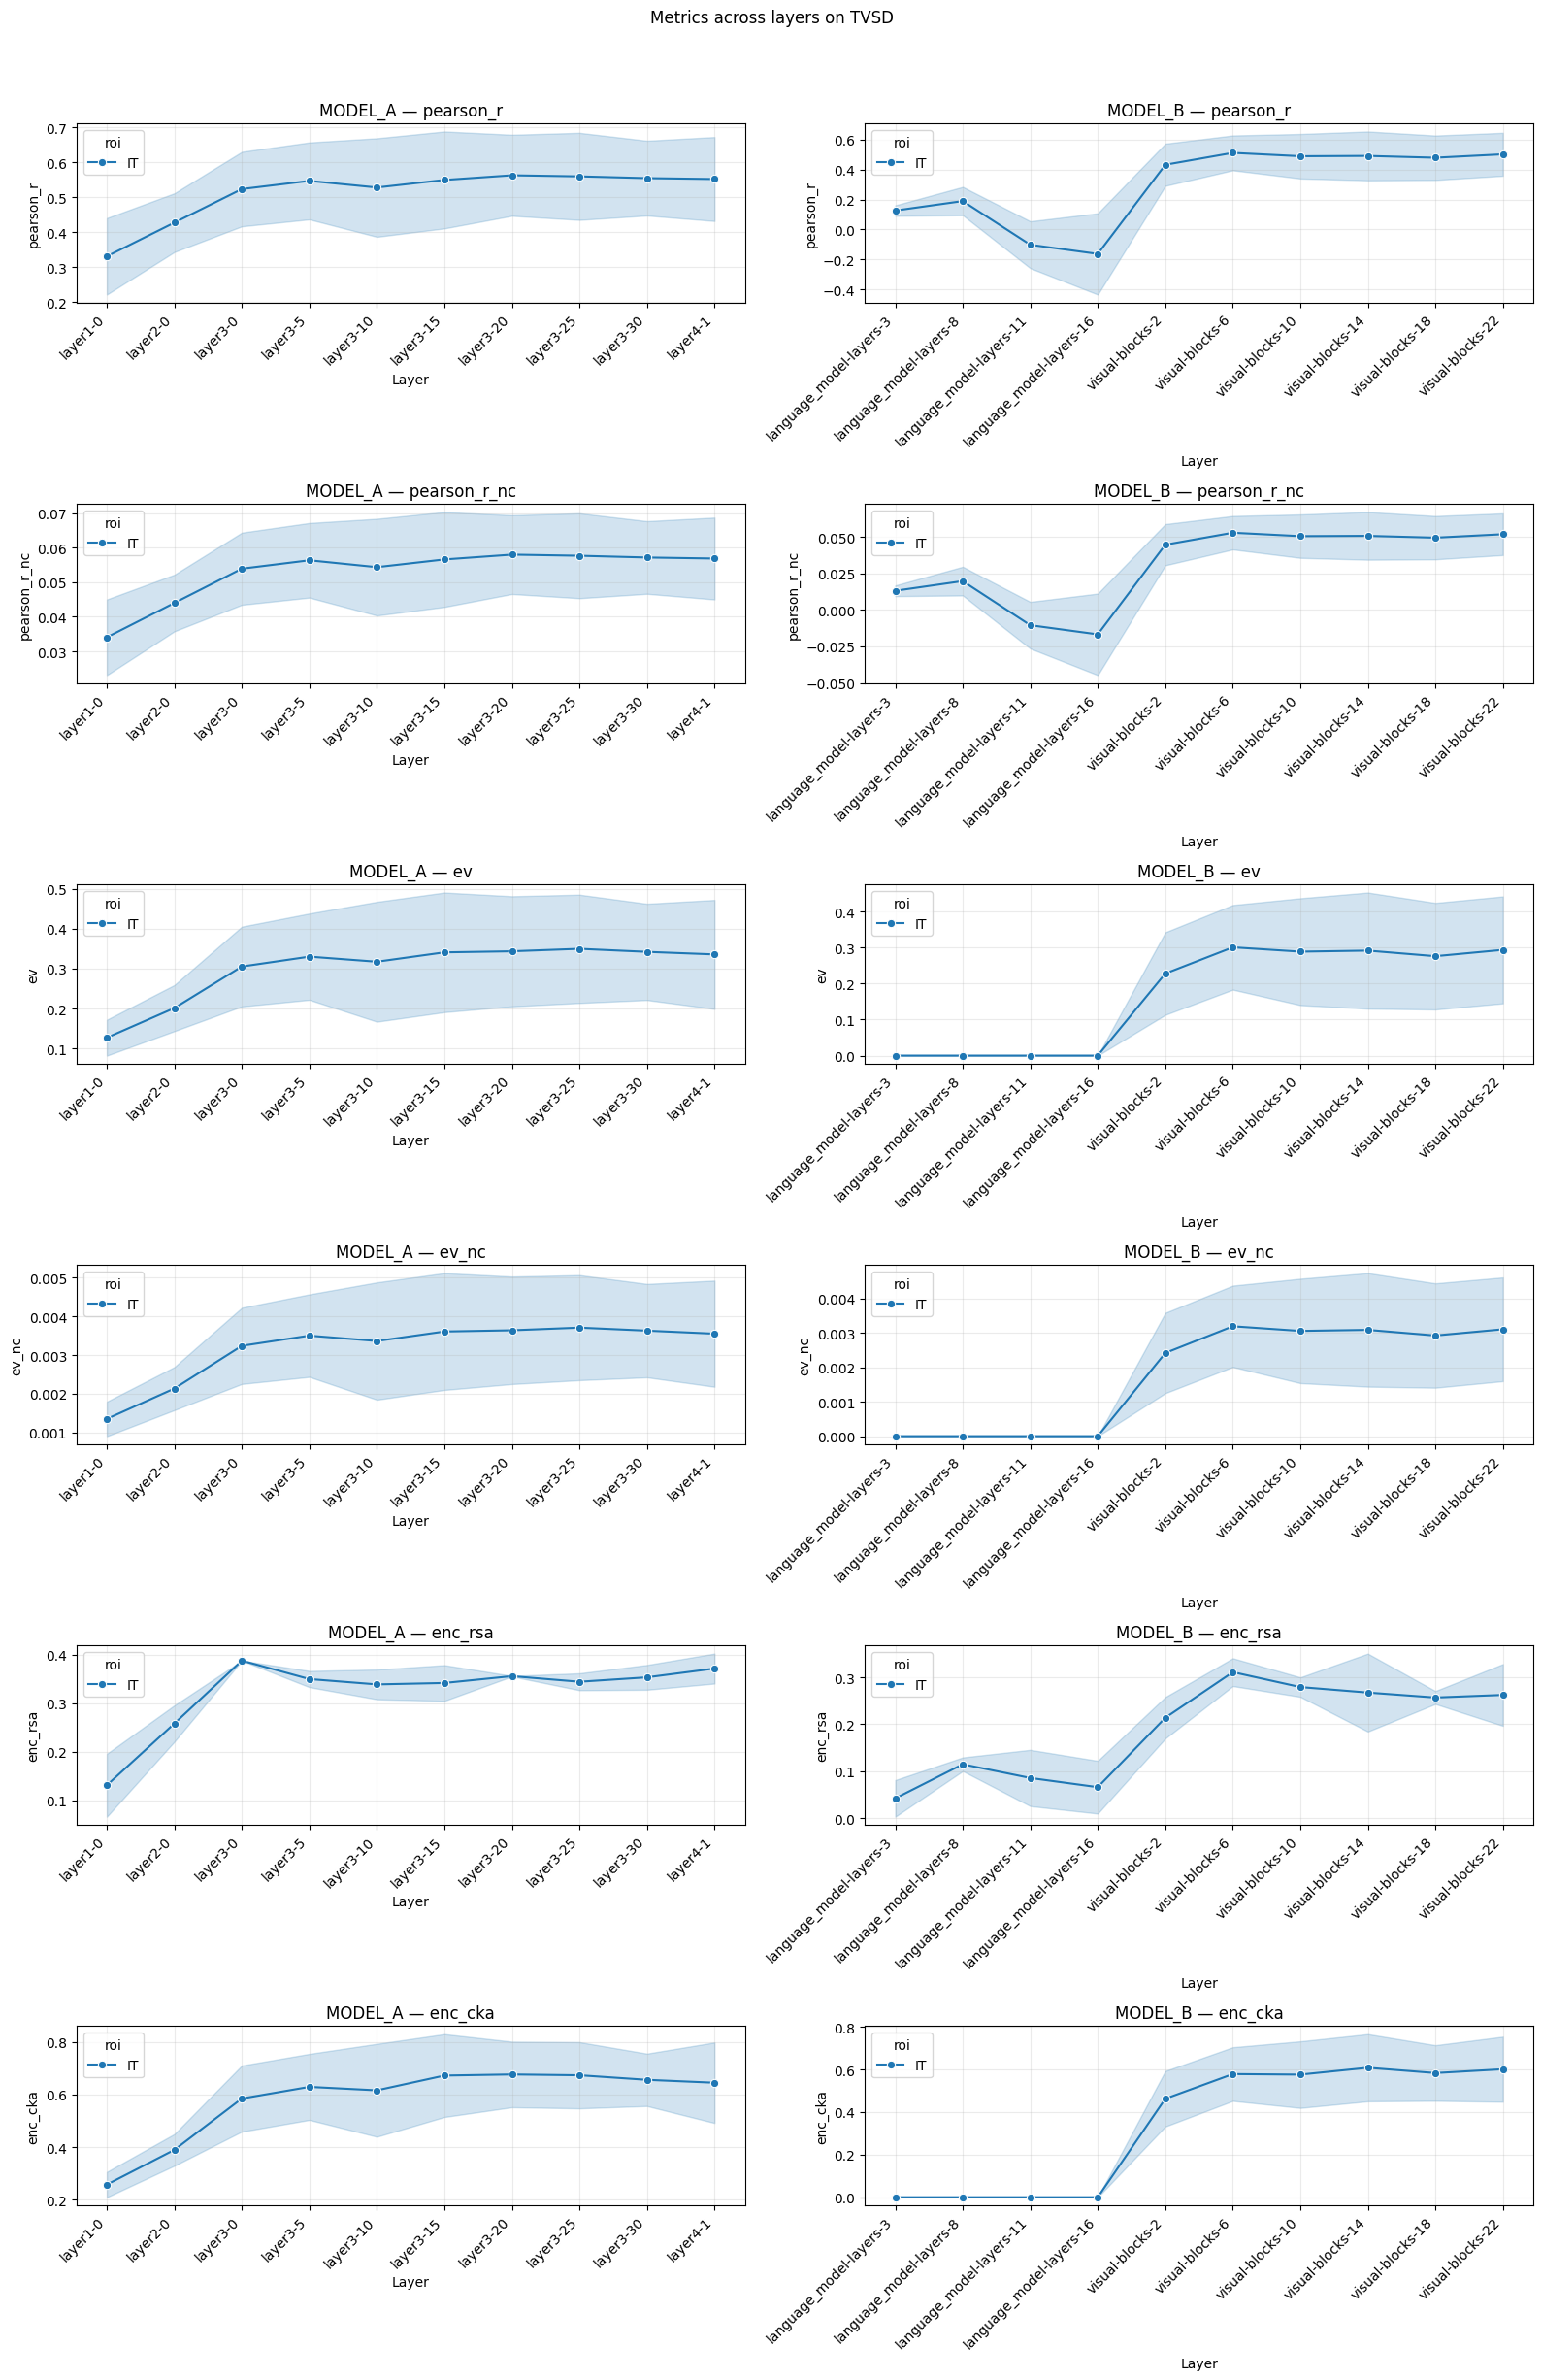

In [57]:
plot_metrics_by_roi_across_layers(
    results_df=df,
    dataset_name="TVSD",
    roi=["IT"],
    model_a="MODEL_A",
    model_b="MODEL_B",
    metric_cols=[
        "pearson_r",
        "pearson_r_nc",
        "ev",
        "ev_nc",
        "enc_rsa",
        "enc_cka",
    ],
)

#### stacking layers 

In [45]:
a = np.array([[1, 2, 3], [3, 4, 5]])
b = np.array([[5, 6, 7], [3, 4, 5]])
np.concatenate((a, b), axis=1).shape


TypeError: 'int' object is not callable

In [20]:
import os
import csv
import time
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split
from itertools import combinations

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
ALPHA_CANDIDATES = [1]
LR               = 1e-3
EPOCHS           = 5
BATCH_SIZE       = 512
TRAIN_RATIO      = 0.8
RESULTS_CSV      = "best_params_part3_test3.csv"
WEIGHTS_DIR      = "weights_part3"
metrics_csv = "metrics_part3_test3.csv"

os.makedirs(WEIGHTS_DIR, exist_ok=True)

REQUIRED_TARGETS = {
    "TVSD": ['IT'],  # 'V4', 'V1'],
    # "EEG2": ['occipital_parietal'],
    # "NSD": ['V1v', 'V2v', 'V3v', 'hV4', 'FFA-1', 'VWFA-1', 'PPA', 'OPA', 'EBA'],
}


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
class CustomDataset(Dataset):
    def __init__(self, x, y, flatten_y=False):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)  # (N, d1, d2)
        if flatten_y:
            self.y = self.y.flatten(start_dim=1)        # (N, d1*d2)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return len(self.x)


# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
class LinearEncoder(nn.Module):
    def __init__(self, output_size: int, input_size:int):
        super().__init__()
        self.linear       = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)
        
# class AttentionEncoder(nn.Module):
#     """
#     Learns which features to attend to per ROI.
#     Instead of treating all 30000 features equally,
#     computes a soft selection over features before the linear map.
#     """
#     def __init__(self, output_size: int, input_size=30000):
#         super().__init__()
#         # attention over input features
#         self.query      = nn.Linear(input_size, input_size)
#         self.key        = nn.Linear(input_size, input_size)
#         self.value      = nn.Linear(input_size, input_size)
#         self.scale      = input_size ** 0.5
#         self.readout    = nn.Linear(input_size, output_size)

#     def forward(self, x):
#         # x: (N, input_size)
#         q = self.query(x)                          # (N, input_size)
#         k = self.key(x)                            # (N, input_size)
#         v = self.value(x)                          # (N, input_size)
#         attn = torch.softmax(q * k / self.scale, dim=-1)   # (N, input_size)
#         x    = attn * v                            # (N, input_size)
#         return self.readout(x)                     # (N, output_size)
class AttentionEncoder(nn.Module):
    def __init__(self, input_size: int, output_size: int,
                 proj_dim: int = 64, dropout: float = 0.1):
        super().__init__()
        # aggressive compression first — 30000 → 64
        self.input_proj   = nn.Linear(input_size, proj_dim)
        self.norm         = nn.LayerNorm(proj_dim)
        self.attn_dropout = nn.Dropout(p=dropout)

        # attention on small proj_dim — tiny parameter count
        self.query  = nn.Linear(proj_dim, proj_dim, bias=False)
        self.key    = nn.Linear(proj_dim, proj_dim, bias=False)
        self.value  = nn.Linear(proj_dim, proj_dim, bias=False)
        self.scale  = proj_dim ** 0.5

        self.readout = nn.Linear(proj_dim, output_size)

    def forward(self, x):
        x    = self.input_proj(x)                              # (N, 64)
        x    = self.norm(x)
        q    = self.query(x)
        k    = self.key(x)
        v    = self.value(x)
        attn = torch.softmax(q * k / self.scale, dim=-1)
        attn = self.attn_dropout(attn)
        x    = attn * v                                        # (N, 64)
        return self.readout(x)
        # (N, output_size)
class MultipleLinearEncoder(nn.Module):
    def __init__(self, input_size: int, output_size: int,
                 proj_dim: int = 64):
        super().__init__()
        # aggressive compression first — 30000 → 64
        self.input_proj   = nn.Linear(input_size, proj_dim)
        self.norm         = nn.LayerNorm(proj_dim)
        self.activation   = nn.ReLU()

        # attention on small proj_dim — tiny parameter count

        self.readout = nn.Linear(proj_dim, output_size)

    def forward(self, x):
        x    = self.input_proj(x)                              # (N, 64)
        x    = self.norm(x)
        x    = self.activation(x)                                       # (N, 64)
        return self.activation(self.readout(x))
# ─────────────────────────────────────────────
# DATA UTILITIES
# ─────────────────────────────────────────────
def load_neural_data(data_cfg, subject, roi, train_set=True):
    """
    Load neural responses X and Y for one subject/roi.
    Replace with your actual file loading logic.
    Returns:
        X : np.ndarray (N, n_features)
        Y : np.ndarray (N, n_rois) or (N, 1)
    """
    path = data_cfg["path"]
    data = load_neural_response(path, subject=subject, region=roi, train_set=train_set)
    return data


def load_features(dataset_name, layer, model_cfg, data_cfg, train_set=True, subject=None):
    """
    Load DNN features for one model/layer/dataset.
    Called once per (model, dataset, layer) — heaviest load, fewest calls.
    Returns:
        features : np.ndarray (N, n_features)
    """
    feature_path = model_cfg["feature_paths"][dataset_name]
    if train_set:
        feat_idx = data_cfg["feat_idx_train"]
    else:
        feat_idx = data_cfg["feat_idx_test"]
    if dataset_name=="NSD":
        feat_idx = feat_idx[subject]
    features = load_layer_features(feature_path, layer=layer, feat_idx=feat_idx)
    return features


def make_loaders(X, Y, dataset_name, batch_size=BATCH_SIZE, train_ratio=TRAIN_RATIO):
    if dataset_name=='EEG2':
        dataset    = CustomDataset(X, Y, flatten_y=True)
    else:
        dataset    = CustomDataset(X, Y, flatten_y=False)
    train_size = int(train_ratio * len(dataset))
    val_size   = len(dataset) - train_size
    train_data, val_data = random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_data,   batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


# ─────────────────────────────────────────────
# TRAINING
# ─────────────────────────────────────────────
def train_one_alpha(model, train_loader, val_loader, alpha,
                    epochs=EPOCHS, lr=LR, device=device):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    total_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        # --- Train ---
        model.train()
        train_loss = 0.0
        train_bar  = tqdm(train_loader,
                          desc=f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} Train",
                          leave=False)
        for X_batch, y_batch in train_bar:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            preds = model(X_batch)
            ridge = sum(p.pow(2).sum() for n, p in model.named_parameters()
                        if 'weight' in n)
            loss  = criterion(preds, y_batch) + alpha * ridge
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_bar.set_postfix(loss=f"{loss.item():.6f}")

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        val_bar  = tqdm(val_loader,
                        desc=f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} Val  ",
                        leave=False)
        with torch.no_grad():
            for X_batch, y_batch in val_bar:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds  = model(X_batch)
                ridge  = sum(p.pow(2).sum() for n, p in model.named_parameters()
                             if 'weight' in n)
                loss   = criterion(preds, y_batch) + alpha * ridge
                val_loss += loss.item() * X_batch.size(0)
                val_bar.set_postfix(loss=f"{loss.item():.6f}")

        avg_train  = train_loss / len(train_loader.dataset)
        avg_val    = val_loss   / len(val_loader.dataset)
        epoch_time = time.time() - epoch_start
        eta        = epoch_time * (epochs - epoch - 1)

        print(f"  [α={alpha}] Epoch {epoch+1:>3}/{epochs} | "
              f"Train: {avg_train:.6f} | Val: {avg_val:.6f} | "
              f"Time: {epoch_time:.2f}s | ETA: {eta:.0f}s")

    total_time = time.time() - total_start
    print(f"  [α={alpha}] Done in {total_time//60:.0f}m {total_time%60:.0f}s")

    return avg_val


# ─────────────────────────────────────────────
# ALPHA SEARCH
# ─────────────────────────────────────────────
def search_alpha(X, Y, dataset_name, device=device, alphas=ALPHA_CANDIDATES, encoder_type='linear'):
    """
    Train one model per alpha on the same loaders.
    Returns best alpha, its val loss, and the model state_dict.
    """
    if dataset_name=='EEG2':
        output_size = int(Y.shape[1] * Y.shape[2])
    else:
        output_size = Y.shape[1]
    input_size=X.shape[1]
    train_loader, val_loader = make_loaders(X, Y, dataset_name=dataset_name)

    best_alpha = None
    best_val_loss = float('inf')
    best_state = None

    for alpha in alphas:
        print(f"\n  ── Trying alpha={alpha} ──")
        if encoder_type=='linear':
            model    = LinearEncoder(input_size=input_size, output_size=output_size).to(device)
        elif encoder_type=='attention':
            model    = AttentionEncoder(proj_dim=2048, input_size=30000, output_size=output_size).to(device)
        elif encoder_type=='multiple_linear':
            model    = MultipleLinearEncoder(proj_dim=8192, input_size=30000, output_size=output_size).to(device)
        else:
            print(f"Unknown encoder_type: {encoder_type}")
        val_loss = train_one_alpha(model, train_loader, val_loader,
                                   alpha=alpha, device=device)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_alpha    = alpha
            best_state    = {k: v.cpu().clone()
                             for k, v in model.state_dict().items()}

    return best_alpha, best_val_loss, best_state


# ─────────────────────────────────────────────
# SAVING
# ─────────────────────────────────────────────
def save_weights(state_dict, model_name, layer, dataset_name, subject, roi,
                 weights_dir=WEIGHTS_DIR):
    filename = f"{model_name}__{layer}__{dataset_name}__{subject}__{roi}.pt"
    path     = os.path.join(weights_dir, filename)
    torch.save(state_dict, path)
    print(f"  Saved weights → {path}")


def append_result_csv(row: dict, csv_path=RESULTS_CSV):
    file_exists = os.path.isfile(csv_path)
    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


# ─────────────────────────────────────────────
# MAIN LOOP
# Load order: model → dataset → layer → subject → roi → alpha
# Features loaded once per (model, dataset, layer)  ← heaviest
# Neural data loaded once per (subject, roi)
# ─────────────────────────────────────────────
def run_all(models_cfg=MODELS, dataset_cfg=DATASET_CFG,
            required_targets=REQUIRED_TARGETS, device=device, encoder_type='linear', alphas=ALPHA_CANDIDATES):

    for model_name, model_info in models_cfg.items():
        layers=model_info["layers"]
        for dataset_name, rois in required_targets.items():   # ← then dataset
            data_cfg    = dataset_cfg[dataset_name]
            subjects = data_cfg["subjects"]

            # ── load features once per (model, layer, dataset) ──
            print(f"\n{'='*65}")
            print(f"  Model: {model_name} | ALL layer | Dataset: {dataset_name}")
            print(f"{'='*65}")
            # if dataset_name!='NSD':
            #     X = load_features(
            #         dataset_name=dataset_name,
            #         layer=layer,
            #         model_cfg=model_info,
            #         data_cfg=data_cfg,
            #         train_set=True
            #     )
            # X  = features[data_cfg["feat_idx_train"]]
            for layer1, layer2 in zip(layers[0::2], layers[1::2]):
                print(f"\n{'='*65}")
                print(f"  Model: {model_name} | Layers: {layer1} + {layer2} | Dataset: {dataset_name}")
                print(f"{'='*65}")
                
                X1 = load_features(
                    dataset_name=dataset_name,
                    layer=layer1,
                    model_cfg=model_info,
                    data_cfg=data_cfg,
                    train_set=True
                )
                X2 = load_features(
                    dataset_name=dataset_name,
                    layer=layer2,
                    model_cfg=model_info,
                    data_cfg=data_cfg,
                    train_set=True
                )
                X = np.concatenate((X1, X2), axis=1)
                del X1, X2  # free memory immediately after concat

                layer_label = f"{layer1}+{layer2}"


                for subject in subjects:
                    # if dataset_name=="NSD":
                    #     X = load_features(
                    #     dataset_name=dataset_name,
                    #     layer=layer,
                    #     model_cfg=model_info,
                    #     data_cfg=data_cfg,
                    #     train_set=True,
                    #     subject=subject
                    # )
                    print(f"\n  Subject: {subject}")
    
                    for roi in rois:
                        print(f"\n    ROI: {roi}")
    
                        Y = load_neural_data(data_cfg, subject, roi)
    
                        best_alpha, best_val_loss, best_state = search_alpha(
                            X,
                            Y, 
                            device=device, 
                            dataset_name=dataset_name,
                            encoder_type=encoder_type, 
                            alphas=alphas
                        )
    
                        print(f"\n    ✓ Best alpha={best_alpha} | "
                              f"Val loss={best_val_loss:.6f}")
    
                        save_weights(best_state, model_name, layer_label,
                                     dataset_name, subject, roi)
    
                        append_result_csv({
                            "model":      model_name,
                            "layer":      layer_label,
                            "dataset":    dataset_name,
                            "subject":    subject,
                            "roi":        roi,
                            "best_alpha": best_alpha,
                            "val_loss":   round(best_val_loss, 8),
                        })


Using device: cuda


In [25]:
lay = MODELS['MODEL_A']['layers']
for layer1, layer2 in zip(lay[0::2], lay[1::2]):
    print(layer1, layer2)

layer1-0 layer2-0
layer3-0 layer3-5
layer3-10 layer3-15
layer3-20 layer3-25
layer3-30 layer4-1


In [26]:
run_all(encoder_type='linear')


  Model: MODEL_A | ALL layer | Dataset: TVSD

  Model: MODEL_A | Layers: layer1-0 + layer2-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT

  ── Trying alpha=1 ──


  [α=1] Epoch   1/5 | Train: 74.099210 | Val: 10.590671 | Time: 4.26s | ETA: 17s


  [α=1] Epoch   2/5 | Train: 3.461051 | Val: 0.782106 | Time: 3.86s | ETA: 12s


  [α=1] Epoch   3/5 | Train: 0.406335 | Val: 0.224384 | Time: 3.85s | ETA: 8s


  [α=1] Epoch   4/5 | Train: 0.187515 | Val: 0.171077 | Time: 3.78s | ETA: 4s


...

  [α=1] Epoch   1/5 | Train: 1114.844547 | Val: 110.915812 | Time: 3.65s | ETA: 15s


  [α=1] Epoch   2/5 | Train: 74.701646 | Val: 36.422439 | Time: 3.77s | ETA: 11s


  [α=1] Epoch   3/5 | Train: 28.062056 | Val: 21.783403 | Time: 3.83s | ETA: 8s


  [α=1] Epoch   4/5 | Train: 18.000088 | Val: 14.816963 | Time: 3.96s | ETA: 4s


  [α=1] Epoch   5/5 | Train: 12.336182 | Val: 10.277548 | Time: 3.97s | ETA: 0s
  [α=1] Done in 0m 19s

    ✓ Best alpha=1 | Val loss=10.277548
  Saved weights → weights_part3/MODEL_B__visual-blocks-18+visual-blocks-22__TVSD__monkeyN__IT.pt


In [33]:
import numpy as np
from sklearn.metrics import explained_variance_score
from scipy.stats import pearsonr

# Define once at the top
rsa = RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman")
cka = CenteredKernelAlignment(dtype=np.float64)

METRICS_CSV    = "metrics_part3_test3.csv"
OUTPUTS_DIR    = "outputs_part3_test3"
METRICS_PERDIM_CSV = "metrics_perdim_part3_test3.csv"
os.makedirs(OUTPUTS_DIR, exist_ok=True)


# ─────────────────────────────────────────────
# METRIC COMPUTATION
# ─────────────────────────────────────────────
# def pearson_correlation(y_true, y_pred):
#     """
#     Pearson r averaged across output dims.
#     y_true, y_pred: np.ndarray (N, output_size)
#     """
#     rs = [pearsonr(y_true[:, i], y_pred[:, i])[0]
#           for i in range(y_true.shape[1])]
#     return float(np.mean(rs))


# def explained_variance(y_true, y_pred):
#     """Explained variance averaged across output dims."""
#     return float(explained_variance_score(y_true, y_pred,
#                                           multioutput='uniform_average'))


def noise_corrected_pearson(pearson_r, noise_ceiling, average=True):
    """
    Divide raw Pearson r by element-wise sqrt of noise ceiling,
    then average across dims.
    noise_ceiling: np.ndarray (output_size,)
    """
    # per-dim correction then average
    corrected = pearson_r / np.sqrt(np.maximum(noise_ceiling, 1e-8))
    if average:
        return float(np.mean(corrected))
    else:
        return corrected


def noise_corrected_ev(ev_per_dim, noise_ceiling, average=True):
    """
    Divide raw EV per dim by noise ceiling value, then average.
    noise_ceiling: np.ndarray (output_size,)
    """
    corrected = ev_per_dim / np.maximum(noise_ceiling, 1e-8)
    if average:
        return float(np.mean(corrected))
    else: 
        return corrected


def compute_per_dim_pearson(y_true, y_pred):
    """Returns per-dim Pearson r as np.ndarray (output_size,)."""
    return np.array([pearsonr(y_true[:, i], y_pred[:, i])[0]
                     for i in range(y_true.shape[1])])


def compute_per_dim_ev(y_true, y_pred):
    """Returns per-dim explained variance as np.ndarray (output_size,)."""
    return explained_variance_score(y_true, y_pred, multioutput='raw_values')


# ─────────────────────────────────────────────
# MODEL INFERENCE
# ─────────────────────────────────────────────
def get_predictions(model, X_test, device=device, batch_size=BATCH_SIZE):
    """
    Run model on X_test in batches.
    Returns np.ndarray (N, output_size).
    """
    model.eval()
    X_tensor = torch.tensor(X_test, dtype=torch.float32)
    loader   = DataLoader(X_tensor, batch_size=batch_size, shuffle=False)
    preds    = []
    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device)
            out     = model(X_batch)
            preds.append(out.cpu().numpy())
    return np.concatenate(preds, axis=0)


def load_model_weights(model_name, layer, dataset_name, subject, roi,
                       output_size, encoder_type, input_size, weights_dir=WEIGHTS_DIR):
    """Load a saved LinearEncoder from disk."""
    filename = f"{model_name}__{layer}__{dataset_name}__{subject}__{roi}.pt"
    path     = os.path.join(weights_dir, filename)
    if encoder_type=='linear':
        model    = LinearEncoder(output_size=output_size, input_size=input_size).to(device)
    elif encoder_type=='attention':
        model    = AttentionEncoder(proj_dim=2048, input_size=30000, output_size=output_size).to(device)
    elif encoder_type=='multiple_linear':
            model    = MultipleLinearEncoder(proj_dim=8192, input_size=30000, output_size=output_size).to(device)
    else:
        print(f"Unknown encoder_type: {encoder_type}")
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


# ─────────────────────────────────────────────
# OUTPUT SAVING  —  one file perdataset
# collects all roi predictions and saves together
# ─────────────────────────────────────────────
# def save_outputs(outputs_dict, model_name, layer, dataset_name,
#                  outputs_dir=OUTPUTS_DIR):
#     """
#     outputs_dict: { (subject, roi): np.ndarray (N, output_size) }
#     Saved as a single .pt file per (model, layer, dataset).
#     """
#     filename = f"{model_name}__{layer}__{dataset_name}__outputs.pt"
#     path     = os.path.join(outputs_dir, filename)
#     # convert to serialisable dict with string keys
#     serialisable = {f"{subj}__{roi}": torch.tensor(arr)
#                     for (subj, roi), arr in outputs_dict.items()}
#     torch.save(serialisable, path)
#     print(f"  Saved outputs → {path}")

def save_outputs(outputs_dict, dataset_name, outputs_dir=OUTPUTS_DIR):
    """
    outputs_dict: { (model_name, layer, subject, roi): np.ndarray (N, output_size) }
    Saved as a single .pt file per dataset.
    """
    filename = f"{dataset_name}__outputs.pt"
    path     = os.path.join(outputs_dir, filename)
    serialisable = {f"{model}__{layer}__{subj}__{roi}": torch.tensor(arr)
                    for (model, layer, subj, roi), arr in outputs_dict.items()}
    torch.save(serialisable, path)
    print(f"  Saved outputs → {path}")
    
def append_perdim_csv(meta: dict, perdim_metrics: dict,
                      csv_path=METRICS_PERDIM_CSV):
    """
    Saves one row per output dimension.
    meta: dict with model, layer, dataset, subject, roi
    perdim_metrics: dict of np.ndarray (output_size,)
    """
    file_exists = os.path.isfile(csv_path)
    output_size = len(next(iter(perdim_metrics.values())))

    fieldnames  = list(meta.keys()) + ["dim"] + list(perdim_metrics.keys())

    with open(csv_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        for i in range(output_size):
            row = {**meta, "dim": i}
            row.update({k: round(float(v[i]), 8)
                        for k, v in perdim_metrics.items()})
            writer.writerow(row)
# ─────────────────────────────────────────────
# EVALUATION  —  one subject/roi
# ─────────────────────────────────────────────
def evaluate_one(model, X_test, Y_test, noise_ceiling, dataset_name):
    """
    Returns:
        averaged_metrics : dict of scalar values  → goes to METRICS_CSV
        perdir_metrics   : dict of arrays         → goes to METRICS_PERDIM_CSV
    """
    if dataset_name == 'EEG2':
        Y_test = Y_test.reshape(Y_test.shape[0], -1)

    y_pred = get_predictions(model, X_test)

    # --- per-dim raw ---
    per_dim_r  = compute_per_dim_pearson(Y_test, y_pred)   # (output_size,)
    per_dim_ev = compute_per_dim_ev(Y_test, y_pred)        # (output_size,)

    # --- per-dim corrected ---
    per_dim_r_nc  = noise_corrected_pearson(per_dim_r,  noise_ceiling, average=False)
    per_dim_ev_nc = noise_corrected_ev(per_dim_ev,      noise_ceiling, average=False)

    # --- averaged ---
    avg_r     = float(np.mean(per_dim_r))
    avg_ev    = float(np.mean(per_dim_ev))
    avg_r_nc  = float(np.mean(per_dim_r_nc))
    avg_ev_nc = float(np.mean(per_dim_ev_nc))

    # --- RSA & CKA ---
    rsa_score = float(RepresentationalSimilarityAnalysis(dissimilarity="correlation", similarity_metric="spearman").forward(y_pred, Y_test))
    cka_score = float(CenteredKernelAlignment(dtype=np.float64).forward(y_pred, Y_test))

    averaged_metrics = {
        "pearson_r":          round(avg_r,     8),
        "pearson_r_nc":       round(avg_r_nc,  8),
        "explained_variance": round(avg_ev,    8),
        "ev_nc":              round(avg_ev_nc, 8),
        "rsa":                round(rsa_score, 8),
        "cka":                round(cka_score, 8),
    }

    perdim_metrics = {
        "pearson_r":    per_dim_r,        # np.ndarray (output_size,)
        "pearson_r_nc": per_dim_r_nc,
        "ev":           per_dim_ev,
        "ev_nc":        per_dim_ev_nc,
    }

    return averaged_metrics, perdim_metrics



# ─────────────────────────────────────────────
# EVAL MAIN LOOP
# Same load order as training:
# model → layer → dataset → subject → roi
# Features loaded once per (model, layer, dataset)
# ─────────────────────────────────────────────
def run_evaluation(models_cfg=MODELS, dataset_cfg=DATASET_CFG,
                   required_targets=REQUIRED_TARGETS, device=device, encoder_type='linear'):

    for dataset_name, rois in required_targets.items():
        data_cfg = dataset_cfg[dataset_name]
        subjects = data_cfg["subjects"]

        outputs_dict = {}

        for model_name, model_info in models_cfg.items():
            layers = model_info["layers"]

            for layer1, layer2 in zip(layers[0::2], layers[1::2]):
                layer_label = f"{layer1}+{layer2}"

                print(f"\n{'='*65}")
                print(f"  EVAL | Model: {model_name} | Layers: {layer_label} | Dataset: {dataset_name}")
                print(f"{'='*65}")

                # ── load and concat test features once per pair ──
                X1 = load_features(
                    dataset_name=dataset_name,
                    layer=layer1,
                    model_cfg=model_info,
                    data_cfg=data_cfg,
                    train_set=False
                )
                X2 = load_features(
                    dataset_name=dataset_name,
                    layer=layer2,
                    model_cfg=model_info,
                    data_cfg=data_cfg,
                    train_set=False
                )
                X_test_feats = np.concatenate((X1, X2), axis=1)
                del X1, X2  # free memory

                for subject in subjects:
                    print(f"\n  Subject: {subject}")

                    for roi in rois:
                        print(f"\n    ROI: {roi}")

                        Y_test = load_neural_data(data_cfg, subject, roi,
                                                  train_set=False)
                        noise_ceiling = load_noise_ceiling(
                            dataset_name=dataset_name,
                            dataset_path=data_cfg["path"],
                            subject=subject,
                            region=roi
                        )

                        if dataset_name == 'EEG2':
                            output_size = int(Y_test.shape[1] * Y_test.shape[2])
                        else:
                            output_size = Y_test.shape[1]
                        input_size = X_test_feats.shape[1]

                        # ── load model saved under layer_label ──
                        model = load_model_weights(
                            model_name=model_name, layer=layer_label,
                            dataset_name=dataset_name, subject=subject,
                            roi=roi, output_size=output_size, input_size=input_size,
                            encoder_type=encoder_type
                        )

                        averaged_metrics, perdim_metrics = evaluate_one(
                            model, X_test_feats, Y_test,
                            noise_ceiling, dataset_name
                        )

                        print(f"    ✓ Pearson r={averaged_metrics['pearson_r']:.4f} | "
                              f"NC Pearson={averaged_metrics['pearson_r_nc']:.4f} | "
                              f"EV={averaged_metrics['explained_variance']:.4f} | "
                              f"NC EV={averaged_metrics['ev_nc']:.4f} | "
                              f"RSA={averaged_metrics['rsa']:.4f} | "
                              f"CKA={averaged_metrics['cka']:.4f}")

                        meta = {
                            "model":   model_name,
                            "layer":   layer_label,  # ← "layer1+layer2"
                            "dataset": dataset_name,
                            "subject": subject,
                            "roi":     roi,
                        }
                        append_result_csv({**meta, **averaged_metrics}, csv_path=METRICS_CSV)
                        append_perdim_csv(meta, perdim_metrics, csv_path=METRICS_PERDIM_CSV)

                        y_pred = get_predictions(model, X_test_feats)
                        outputs_dict[(model_name, layer_label, subject, roi)] = y_pred

                del X_test_feats  # free before loading next pair

        save_outputs(outputs_dict, dataset_name)




In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("metrics_part3_test3.csv")

# Clean names
df = df.rename(columns={
    "explained_variance": "ev",
    "rsa": "enc_rsa",
    "cka": "enc_cka",
})

# Pretty labels
model_name_map = {
    "MODEL_A": "Adv-ResNet152",
    "MODEL_B": "Qwen3-VL-2B"
}
df["model_pretty"] = df["model"].map(model_name_map).fillna(df["model"])

# Layer order helper
layer_order = list(df["layer"].drop_duplicates())

# Metrics available right now
all_metrics = ["pearson_r", "pearson_r_nc", "ev", "ev_nc", "enc_rsa", "enc_cka"]


print(df.columns.tolist())
print("Available metrics:", all_metrics)

['model', 'layer', 'dataset', 'subject', 'roi', 'pearson_r', 'pearson_r_nc', 'ev', 'ev_nc', 'enc_rsa', 'enc_cka', 'model_pretty']
Available metrics: ['pearson_r', 'pearson_r_nc', 'ev', 'ev_nc', 'enc_rsa', 'enc_cka']


In [34]:
run_evaluation(encoder_type='linear')


  EVAL | Model: MODEL_A | Layers: layer1-0+layer2-0 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT
    ✓ Pearson r=0.4409 | NC Pearson=0.0457 | EV=0.1760 | NC EV=0.0019 | RSA=0.2948 | CKA=0.2520

  Subject: monkeyN

    ROI: IT
    ✓ Pearson r=0.4540 | NC Pearson=0.0464 | EV=0.1706 | NC EV=0.0018 | RSA=0.2797 | CKA=0.2240

  EVAL | Model: MODEL_A | Layers: layer3-0+layer3-5 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT
    ✓ Pearson r=0.5593 | NC Pearson=0.0579 | EV=0.2291 | NC EV=0.0025 | RSA=0.3980 | CKA=0.4406

  Subject: monkeyN

    ROI: IT
    ✓ Pearson r=0.5978 | NC Pearson=0.0611 | EV=0.2821 | NC EV=0.0030 | RSA=0.4019 | CKA=0.5055

  EVAL | Model: MODEL_A | Layers: layer3-10+layer3-15 | Dataset: TVSD

  Subject: monkeyF

    ROI: IT
    ✓ Pearson r=0.6187 | NC Pearson=0.0641 | EV=0.2806 | NC EV=0.0030 | RSA=0.4979 | CKA=0.5435

  Subject: monkeyN

    ROI: IT
    ✓ Pearson r=0.6801 | NC Pearson=0.0696 | EV=0.3692 | NC EV=0.0039 | RSA=0.4198 | CKA=0.6551

  EVAL | Model: 

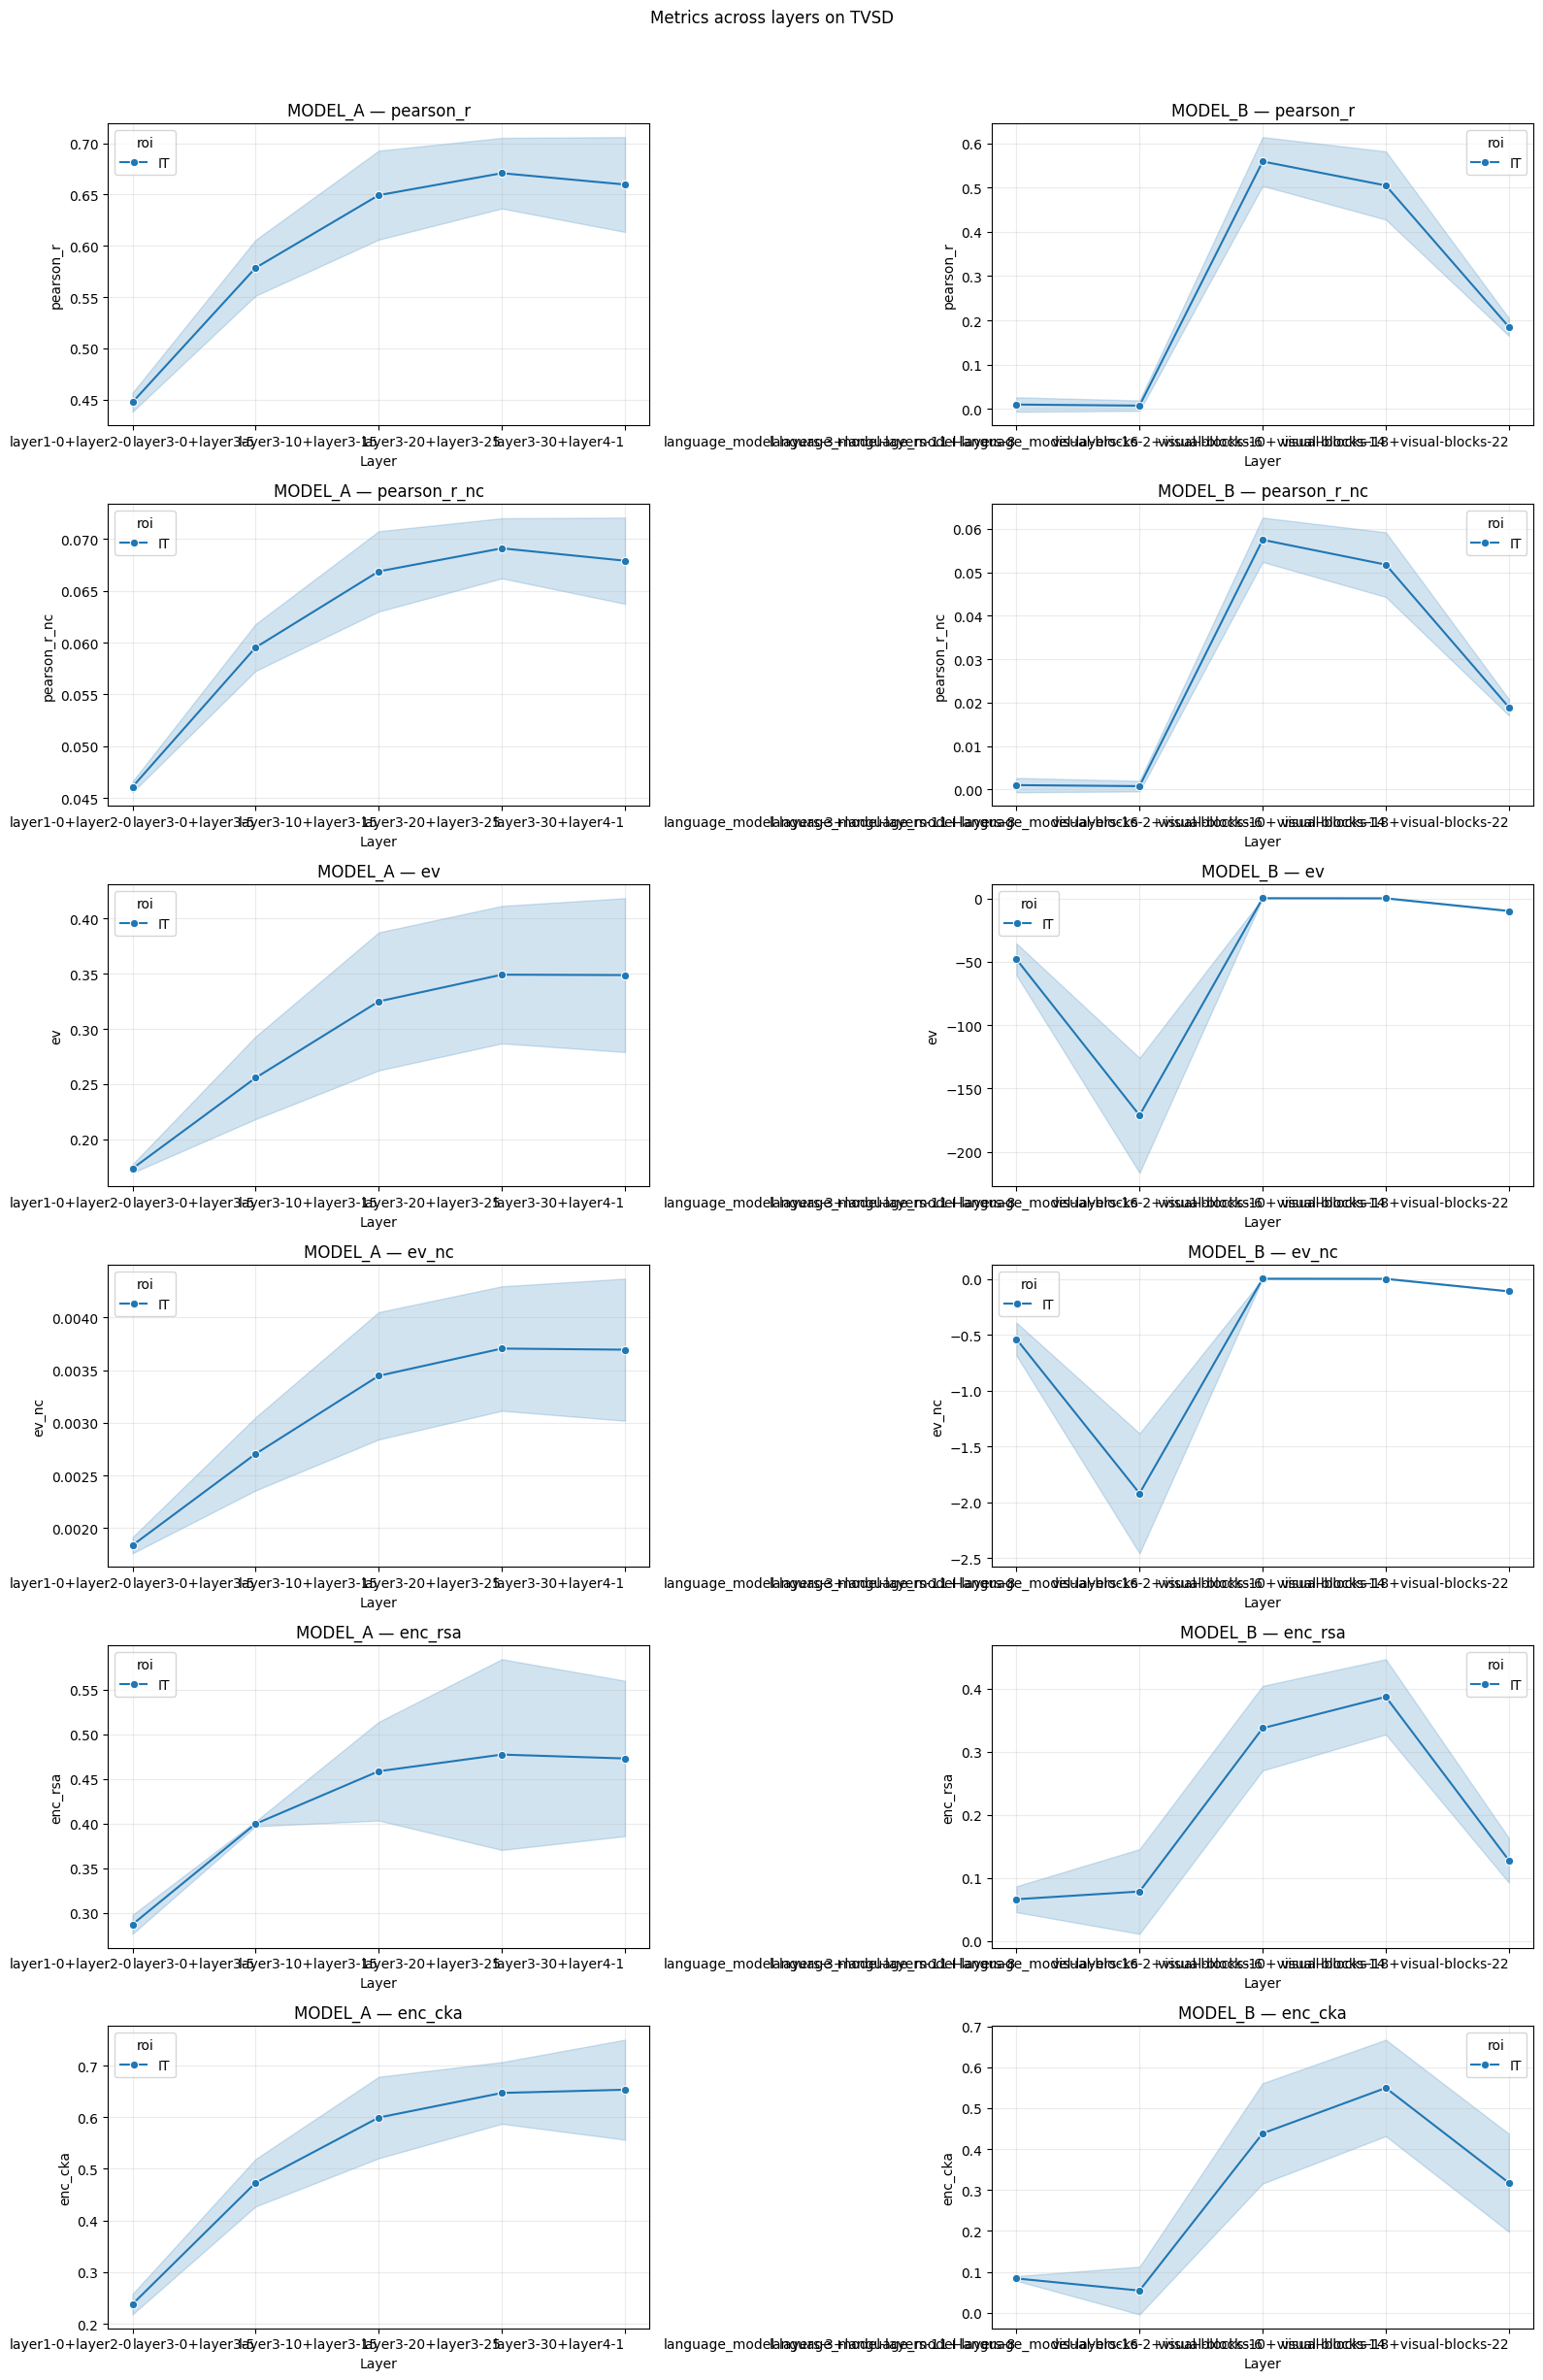

In [39]:
plot_metrics_by_roi_across_layers(
    results_df=df,
    dataset_name="TVSD",
    roi=["IT"],
    model_a="MODEL_A",
    model_b="MODEL_B",
    metric_cols=[
        "pearson_r",
        "pearson_r_nc",
        "ev",
        "ev_nc",
        "enc_rsa",
        "enc_cka",
    ],
)

---

# Final Discussion

End the notebook with a short final discussion.

<div style="background:#eef5fb; border-left:4px solid #4c78a8; padding:8px 12px; border-radius:6px; font-weight:700; color:#26445e;">What you must address</div>

- Which dataset appeared noisiest?
- Which neural targets were most reliable?
- Which model aligned best overall?
- Which metrics were most consistent with each other?
- What was the main limitation of your analysis?
- What would you try next with more time?

<div style="background:#fff4c2; border:1px solid #c89b1f; border-left:6px solid #9a6f00; padding:10px 12px; border-radius:6px; margin-top:8px; margin-bottom:4px; color:#241a00; line-height:1.45;"><strong style="color:#5c4300;">Answer box final</strong><br>Write a concise final conclusion of 1–2 paragraphs summarizing your main findings and their limitations.</div>

In [ ]:
# No code required here unless you want to add final summary tables/figures.

---

# Report Content

Your **2-page PDF report** should tell a clear and coherent story. It does **not** need to reproduce every notebook result.

It can include:

1. **A brief dataset overview**
2. **An exploratory figure from Section 1**
3. **The EEG noise ceiling comparison**
4. **The NSD reliability visualization**
5. **One or two key brain–model alignment results from Section 2**


Rather, you should primarily focus on the open-ended extension you designed, describing:
- the motivation for your extension,
- the methods you implemented,
- the results you obtained,
- and the scientific insights you gained from it.


The report should emphasize interpretation, not just figures. Since the notebook is the main technical deliverable, the report should act as a **compressed scientific summary** of your most important findings rather than a figure dump.

---

# Detailed Grading Rubric

The project is graded out of **100 points** as follows:

- **Section 1: Inspection, Visualization, and Noise Ceiling Estimates — 20 points**
- **Section 2: Brain–Model Alignment — 20 points**
- **Section 3: Open-Ended Research — 30 points**
- **Report — 30 points**

**Section 0 is required but not graded separately.** It is treated as setup and reproducibility infrastructure for the rest of the notebook.

## Section 1 — 20 points

### 1.1 Dataset inspection — 3 points
- 1 pt: TVSD structure is correctly inspected and explained.
- 1 pt: EEG2 structure is correctly inspected and explained.
- 1 pt: NSD structure is correctly inspected and explained.

### 1.2 EEG visualization — 4 points
- 1 pt: example EEG time-course plot is present and readable.
- 1 pt: channel × time heatmap is present and readable.
- 1 pt: provided EEG noise ceiling visualization is present and readable.
- 1 pt: written interpretation identifies informative time windows or channel groups.

### 1.3 EEG noise ceiling estimation — 7 points
- 2 pts: variance-based estimator is implemented correctly.
- 2 pts: split-half estimator is implemented correctly.
- 1 pt: required summary visualizations are included.
- 1 pt: comparison to stored EEG noise ceilings is shown clearly.
- 1 pt: Answer box 1.3 interprets similarities and differences between estimators.

### 1.4 Statistical comparison of EEG noise ceilings — 3 points
- 1 pt: quantitative comparison table is present.
- 1 pt: statistical test or formal comparison is appropriate and correctly interpreted.
- 1 pt: final conclusion is clearly justified.

### 1.5 NSD reliability visualization — 3 points
- 1 pt: ncsnr is correctly converted and visualized on cortex.
- 1 pt: parcel overlay or parcel-wise summary is included.
- 1 pt: Answer box 1.5 correctly interprets reliable and unreliable regions.

## Section 2 — 20 points

### 2.1 RSA implementation — 3 points
- 1 pt: RDM computation is correct.
- 1 pt: RDM comparison is correct.
- 1 pt: implementation is used properly in later analyses.

### 2.2 Unbiased linear CKA implementation — 3 points
- 2 pts: unbiased linear CKA is implemented correctly.
- 1 pt: implementation is used properly in later analyses.

### 2.3 Representational analyses across layers, models, and targets — 4 points
- 1 pt: layer-wise RSA results are reported clearly.
- 1 pt: layer-wise CKA results are reported clearly.
- 1 pt: a model comparison is included.
- 1 pt: ROI-wise or time-resolved analysis is included and interpreted.

### 2.4 Predictive alignment with linear encoding models — 6 points
- 1 pt: required targets are selected and described correctly.
- 2 pts: train/validation/test procedure and ridge fitting are correct.
- 1 pt: required predictive metrics are reported correctly.
- 1 pt: encoding-RSA and encoding-CKA are reported correctly.
- 1 pt: best-layer summary and model comparison are included.

### 2.5 Compare predictive and representational metrics — 2 points
- 1 pt: ranking comparison figure is present and informative.
- 1 pt: agreement and disagreement between metrics are discussed clearly.

### 2.6 Layer hierarchy vs brain hierarchy — 1 point
- 1 pt: at least one hierarchy analysis is included and interpreted correctly.

### 2.7 Compare the two feature extractors — 1 point
- 1 pt: final comparison between Qwen3-VL and Adv-ResNet is clear and supported by results.

## Section 3 — 30 points

### Research question and motivation — 5 points
- 2 pts: research question is clear and focused.
- 3 pts: motivation is scientifically sensible and well connected to the baseline project.

### Method and implementation — 10 points
- 4 pts: the extension is described clearly.
- 4 pts: the method is implemented correctly.
- 2 pts: the design remains focused and technically appropriate for the project scope.

### Baseline comparison and evaluation — 10 points
- 4 pts: the comparison to the linear baseline is fair.
- 3 pts: at least one figure or table communicates the comparison clearly.
- 3 pts: evaluation supports the stated conclusion.

### Interpretation and limitations — 5 points
- 3 pts: the student explains whether the method helped in a practically meaningful way.
- 2 pts: limitations or caveats are acknowledged.

## Report — 30 points

### Structure and clarity — 6 points
- clear organization, readable flow, and concise scientific writing.

### Selection of results — 6 points
- the report focuses on the strongest and most relevant results rather than trying to include everything.

### Methodological correctness — 6 points
- metrics, comparisons, and claims are described accurately.

### Interpretation and synthesis — 6 points
- the report explains what the results mean and ties them back to the project goals.

### Figure quality and presentation — 6 points
- figures are readable, labeled, well-chosen, and integrated into the narrative.

## Important grading note

A submission that is technically correct but poorly interpreted will lose points. A submission with good intuition but missing required analyses will also lose points. The strongest submissions will be both **correct** and **scientifically well explained**.

---

# Final Checklist Before Submission

Before submitting, make sure that:

- group information is filled in,
- the notebook runs from top to bottom,
- all notebook outputs are cleared,
- figures have readable titles and labels,
- written answers are included in the answer boxes,
- the zip archive name follows the required format,
- no large unnecessary files are included.

---

# References

Use the references below when you need scientific context for the datasets, models, and analysis methods.

## Datasets

- Papale et al. (2025) — *An extensive dataset of spiking activity to reveal the syntax of the ventral stream*
- Gifford et al. (2022) — *A large and rich EEG dataset for modeling human visual object recognition*
- Allen et al. (2022) — *A massive 7T fMRI dataset to bridge cognitive neuroscience and artificial intelligence*
- van Bree, Styrnal, and Hebart (2025) — *How Much Variance Does Your Model Explain? A Clarifying Note On The Use Of Split-Half Reliability For Computing Noise Ceilings*

## Models

- Wong et al. (2020) — *Fast is better than free: Revisiting adversarial training*
- He et al. (2016) — *Deep Residual Learning for Image Recognition*
- Bai et al. (2025) — *Qwen3-VL Technical Report*

## Alignment and encoding

- Conwell et al. (2024) — *A large-scale examination of inductive biases shaping high-level visual representation in brains and machines*
- Gokce and Schrimpf (2025) — *Scaling Laws for Task-Optimized Models of the Primate Visual Ventral Stream*

Use these references selectively. You are not expected to read everything in full.